In [1524]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [1525]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from scipy.stats import mode
import pandas_profiling
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,KFold
from sklearn.metrics import classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.metrics import auc
from sklearn import metrics

import os
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth',500)
pd.set_option('display.max_columns',5000)

encoder = LabelEncoder()
from IPython.display import Image
import os
!ls ../input/

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [1526]:
train = pd.read_csv('train.csv')
campaign = pd.read_csv('campaign_data.csv')
items = pd.read_csv('item_data.csv')
coupons = pd.read_csv('coupon_item_mapping.csv')
cust_demo = pd.read_csv('customer_demographics.csv')
cust_tran = pd.read_csv('customer_transaction_data.csv')
test = pd.read_csv('test.csv')
df=pd.read_csv('final_train.csv')
data=pd.read_csv('smote.csv')

In [1527]:
train.shape, campaign.shape, items.shape, coupons.shape, cust_demo.shape, cust_tran.shape, test.shape,df.shape,data.shape

((78369, 5),
 (28, 4),
 (74066, 4),
 (92663, 2),
 (760, 7),
 (1324566, 7),
 (50226, 4),
 (78369, 43),
 (155280, 42))

In [1528]:
print('Train Dataframe')
print(train.isnull().sum())
print('======================')
print('Campaign Dataframe')
print(campaign.isnull().sum())
print('======================')
print('Items Dataframe')
print(items.isnull().sum())
print('======================')
print('Coupons Dataframe')
print(coupons.isnull().sum())
print('======================')
print('Customer Demographics Dataframe')
print(cust_demo.isnull().sum())
print('======================')
print('Customer Transaction Dataframe')
print(cust_tran.isnull().sum())
print('======================')

print(test.isnull().sum())
print('======================')
print(df.isnull().sum())
print('======================')
print(data.isnull().sum())

Train Dataframe
id                   0
campaign_id          0
coupon_id            0
customer_id          0
redemption_status    0
dtype: int64
Campaign Dataframe
campaign_id      0
campaign_type    0
start_date       0
end_date         0
dtype: int64
Items Dataframe
item_id       0
brand         0
brand_type    0
category      0
dtype: int64
Coupons Dataframe
coupon_id    0
item_id      0
dtype: int64
Customer Demographics Dataframe
customer_id         0
age_range           0
marital_status    329
rented              0
family_size         0
no_of_children    538
income_bracket      0
dtype: int64
Customer Transaction Dataframe
date               0
customer_id        0
item_id            0
quantity           0
selling_price      0
other_discount     0
coupon_discount    0
dtype: int64
id             0
campaign_id    0
coupon_id      0
customer_id    0
dtype: int64
Unnamed: 0             0
coupon_id              0
customer_id            0
redemption_status      0
brand                  

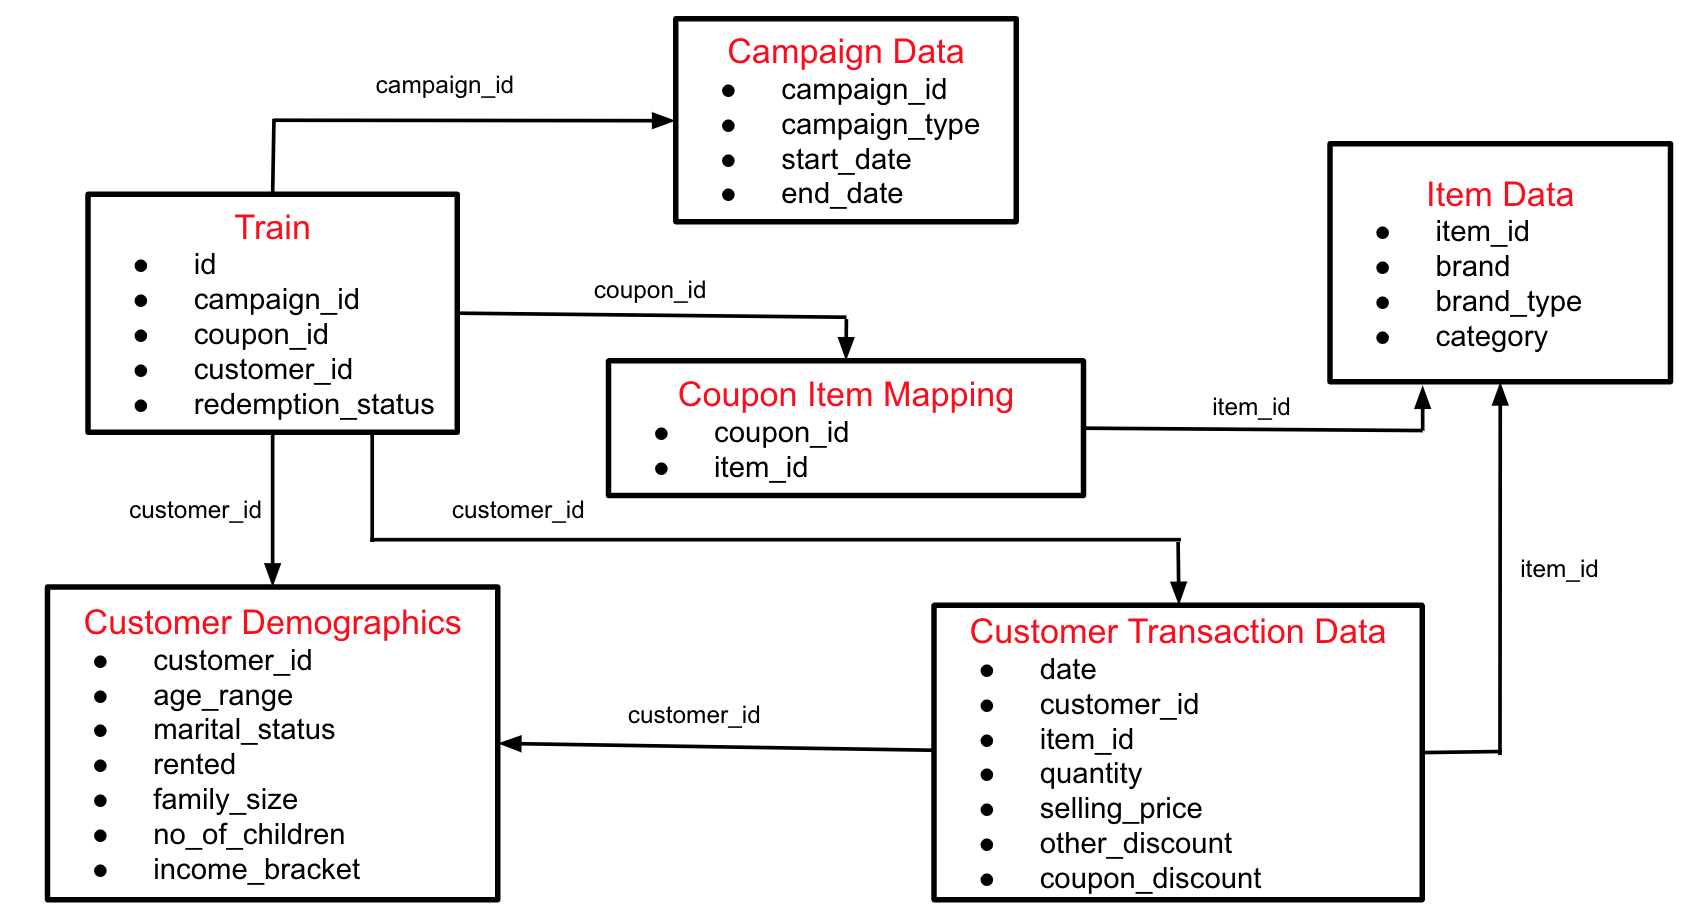

In [1529]:
Image("Schema.png")

All datasets merged by following steps:

1. Merge coupon item data and items data on item_id
2. Aggregate transactions by item_id
3. Merge 1 and 2 on item_id
4. Aggregate 3 on coupon_id
5. Merge 4 and train on coupon_id
6. Aggregate transactions on customer_id
7. Merge 5 with campaign data on campaign_id
8. Merge 7 with customer demographic data on customer_id
9. Merge 6 with 8 on customer_id respectively

In [1530]:
df.shape

(78369, 43)

In [1531]:
df.columns

Index(['Unnamed: 0', 'coupon_id', 'customer_id', 'redemption_status', 'brand',
       'brand_type', 'category', 'cd_sum', 'coupon_discount_x',
       'coupon_used_x', 'item_counts', 'no_of_customers', 'od_sum',
       'other_discount_x', 'price_sum', 'qu_sum', 'quantity_x',
       'selling_price_x', 't_counts', 'total_discount_mean',
       'total_discount_sum', 'campaign_type', 'campaign_duration', 'age_range',
       'marital_status', 'rented', 'family_size', 'no_of_children',
       'income_bracket', 'coupon_discount_y', 'coupon_used_y', 'day', 'dow',
       'no_of_items', 'month', 'other_discount_y', 'quantity_y',
       'selling_price_y', 'cdd_sum', 'customer_id_count', 'odd_sum', 'qa_sum',
       'pprice_sum'],
      dtype='object')

In [1532]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head()

,coupon_id,customer_id,redemption_status,brand,brand_type,category,cd_sum,coupon_discount_x,coupon_used_x,item_counts,no_of_customers,od_sum,other_discount_x,price_sum,qu_sum,quantity_x,selling_price_x,t_counts,total_discount_mean,total_discount_sum,campaign_type,campaign_duration,age_range,marital_status,rented,family_size,no_of_children,income_bracket,coupon_discount_y,coupon_used_y,day,dow,no_of_items,month,other_discount_y,quantity_y,selling_price_y,cdd_sum,customer_id_count,odd_sum,qa_sum,pprice_sum
0,27,1053,0,1105,0,6,-5349.93,-1.241694,191.0,125,19.224000,-177447.090167,-44.367382,436274.446738,4661.0,1.169768,117.276864,3713.0,-45.609077,-182797.020167,0,47,3.0,1.0,0.0,1.0,0.0,5.0,-0.287258,1,11,2,208,5,-25.583099,340.487097,163.966826,-89.05,310,-7930.760842,105551,50829.715972
1,116,48,0,56,1,6,0.00,0.000000,0.0,3,20.333333,-586.140000,-10.207037,5323.510000,86.0,1.050926,70.885046,75.0,-10.207037,-586.140000,0,47,2.0,0.0,0.0,2.0,0.0,3.0,-3.215039,12,4,5,244,6,-20.013685,31.540260,188.638474,-1237.79,385,-7705.268702,12143,72625.812434
2,635,205,0,560,0,11,-605.54,-2.987321,15.0,67,1.761194,-12475.083333,-76.767366,48980.998333,202.0,1.353802,342.826195,142.0,-79.754687,-13080.623333,1,32,3.0,0.0,0.0,2.0,0.0,7.0,-2.212082,85,27,2,533,3,-12.873370,1.392784,112.067666,-2145.72,970,-12487.169143,1351,108705.636349
3,644,1050,0,611,0,6,-17.81,-4.452500,1.0,4,3.500000,-260.750000,-4.451964,3697.783333,47.0,1.110390,88.694903,39.0,-8.904464,-278.560000,0,47,3.0,0.0,0.0,2.0,0.0,5.0,-0.751477,2,9,4,216,8,-12.880868,1.291139,100.896997,-178.10,237,-3052.765833,306,23912.588333
4,1017,1489,0,1558,0,6,-569.92,-0.198055,23.0,32,27.312500,-46796.046667,-30.665116,289181.848333,1610.0,1.071044,200.991719,1420.0,-30.863170,-47365.966667,0,48,3.0,0.0,0.0,2.0,0.0,3.0,-0.471548,10,2,4,327,5,-12.264174,247.443060,85.016352,-265.01,562,-6892.466021,139063,47779.189609


In [1533]:
df.shape

(78369, 42)

# Data Analysis


In [1534]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [1535]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int ((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [1536]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # xóa các dòng có giá trị NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # Giữ các cột có nhiều hơn một giá trị duy nhất
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

In [1537]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

## Final_Train.CSV


In [1538]:
df

,coupon_id,customer_id,redemption_status,brand,brand_type,category,cd_sum,coupon_discount_x,coupon_used_x,item_counts,no_of_customers,od_sum,other_discount_x,price_sum,qu_sum,quantity_x,selling_price_x,t_counts,total_discount_mean,total_discount_sum,campaign_type,campaign_duration,age_range,marital_status,rented,family_size,no_of_children,income_bracket,coupon_discount_y,coupon_used_y,day,dow,no_of_items,month,other_discount_y,quantity_y,selling_price_y,cdd_sum,customer_id_count,odd_sum,qa_sum,pprice_sum
0,27,1053,0,1105,0,6,-5349.93,-1.241694,191.0,125,19.224000,-177447.090167,-44.367382,436274.446738,4661.0,1.169768,117.276864,3713.0,-45.609077,-182797.020167,0,47,3.0,1.0,0.0,1.0,0.0,5.0,-0.287258,1,11,2,208,5,-25.583099,340.487097,163.966826,-89.05,310,-7930.760842,105551,50829.715972
1,116,48,0,56,1,6,0.00,0.000000,0.0,3,20.333333,-586.140000,-10.207037,5323.510000,86.0,1.050926,70.885046,75.0,-10.207037,-586.140000,0,47,2.0,0.0,0.0,2.0,0.0,3.0,-3.215039,12,4,5,244,6,-20.013685,31.540260,188.638474,-1237.79,385,-7705.268702,12143,72625.812434
2,635,205,0,560,0,11,-605.54,-2.987321,15.0,67,1.761194,-12475.083333,-76.767366,48980.998333,202.0,1.353802,342.826195,142.0,-79.754687,-13080.623333,1,32,3.0,0.0,0.0,2.0,0.0,7.0,-2.212082,85,27,2,533,3,-12.873370,1.392784,112.067666,-2145.72,970,-12487.169143,1351,108705.636349
3,644,1050,0,611,0,6,-17.81,-4.452500,1.0,4,3.500000,-260.750000,-4.451964,3697.783333,47.0,1.110390,88.694903,39.0,-8.904464,-278.560000,0,47,3.0,0.0,0.0,2.0,0.0,5.0,-0.751477,2,9,4,216,8,-12.880868,1.291139,100.896997,-178.10,237,-3052.765833,306,23912.588333
4,1017,1489,0,1558,0,6,-569.92,-0.198055,23.0,32,27.312500,-46796.046667,-30.665116,289181.848333,1610.0,1.071044,200.991719,1420.0,-30.863170,-47365.966667,0,48,3.0,0.0,0.0,2.0,0.0,3.0,-0.471548,10,2,4,327,5,-12.264174,247.443060,85.016352,-265.01,562,-6892.466021,139063,47779.189609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78364,71,1523,0,56,1,6,0.00,0.000000,0.0,4,40.750000,-5035.362056,-15.086976,23914.699056,403.0,1.160756,68.244750,332.0,-15.086976,-5035.362056,0,48,5.0,0.0,0.0,2.0,0.0,1.0,0.000000,0,6,3,356,5,-8.282240,1.064935,119.448066,0.00,462,-3826.395000,492,55185.006667
78365,547,937,0,2188,0,6,-35.62,-0.010943,1.0,7,35.571429,-20891.575000,-77.662485,111159.493333,611.0,1.129874,244.016803,530.0,-77.673428,-20927.195000,0,46,5.0,0.0,0.0,2.0,0.0,2.0,-0.346498,1,29,6,223,6,-13.204228,1.206226,91.641946,-89.05,257,-3393.486667,310,23551.980000
78366,754,1004,0,864,0,6,-6666.28,-3.239522,136.0,83,14.421687,-134535.803333,-65.100200,362318.040000,1985.0,1.022980,185.975702,1893.0,-68.339722,-141202.083333,0,48,3.0,0.0,0.0,2.0,0.0,5.0,-0.143267,6,12,4,1196,5,-11.887330,92.930028,99.589878,-260.03,1815,-21575.503851,168668,180755.627932
78367,134,71,0,11,1,6,0.00,0.000000,0.0,7,44.571429,-1151.265000,-3.852546,12403.865000,452.0,1.012069,30.431009,436.0,-3.852546,-1151.265000,0,47,2.0,0.0,0.0,5.0,3.0,4.0,-1.412623,50,30,6,558,11,-17.540946,19.131130,85.425052,-1325.04,938,-16453.407713,17945,80128.698841


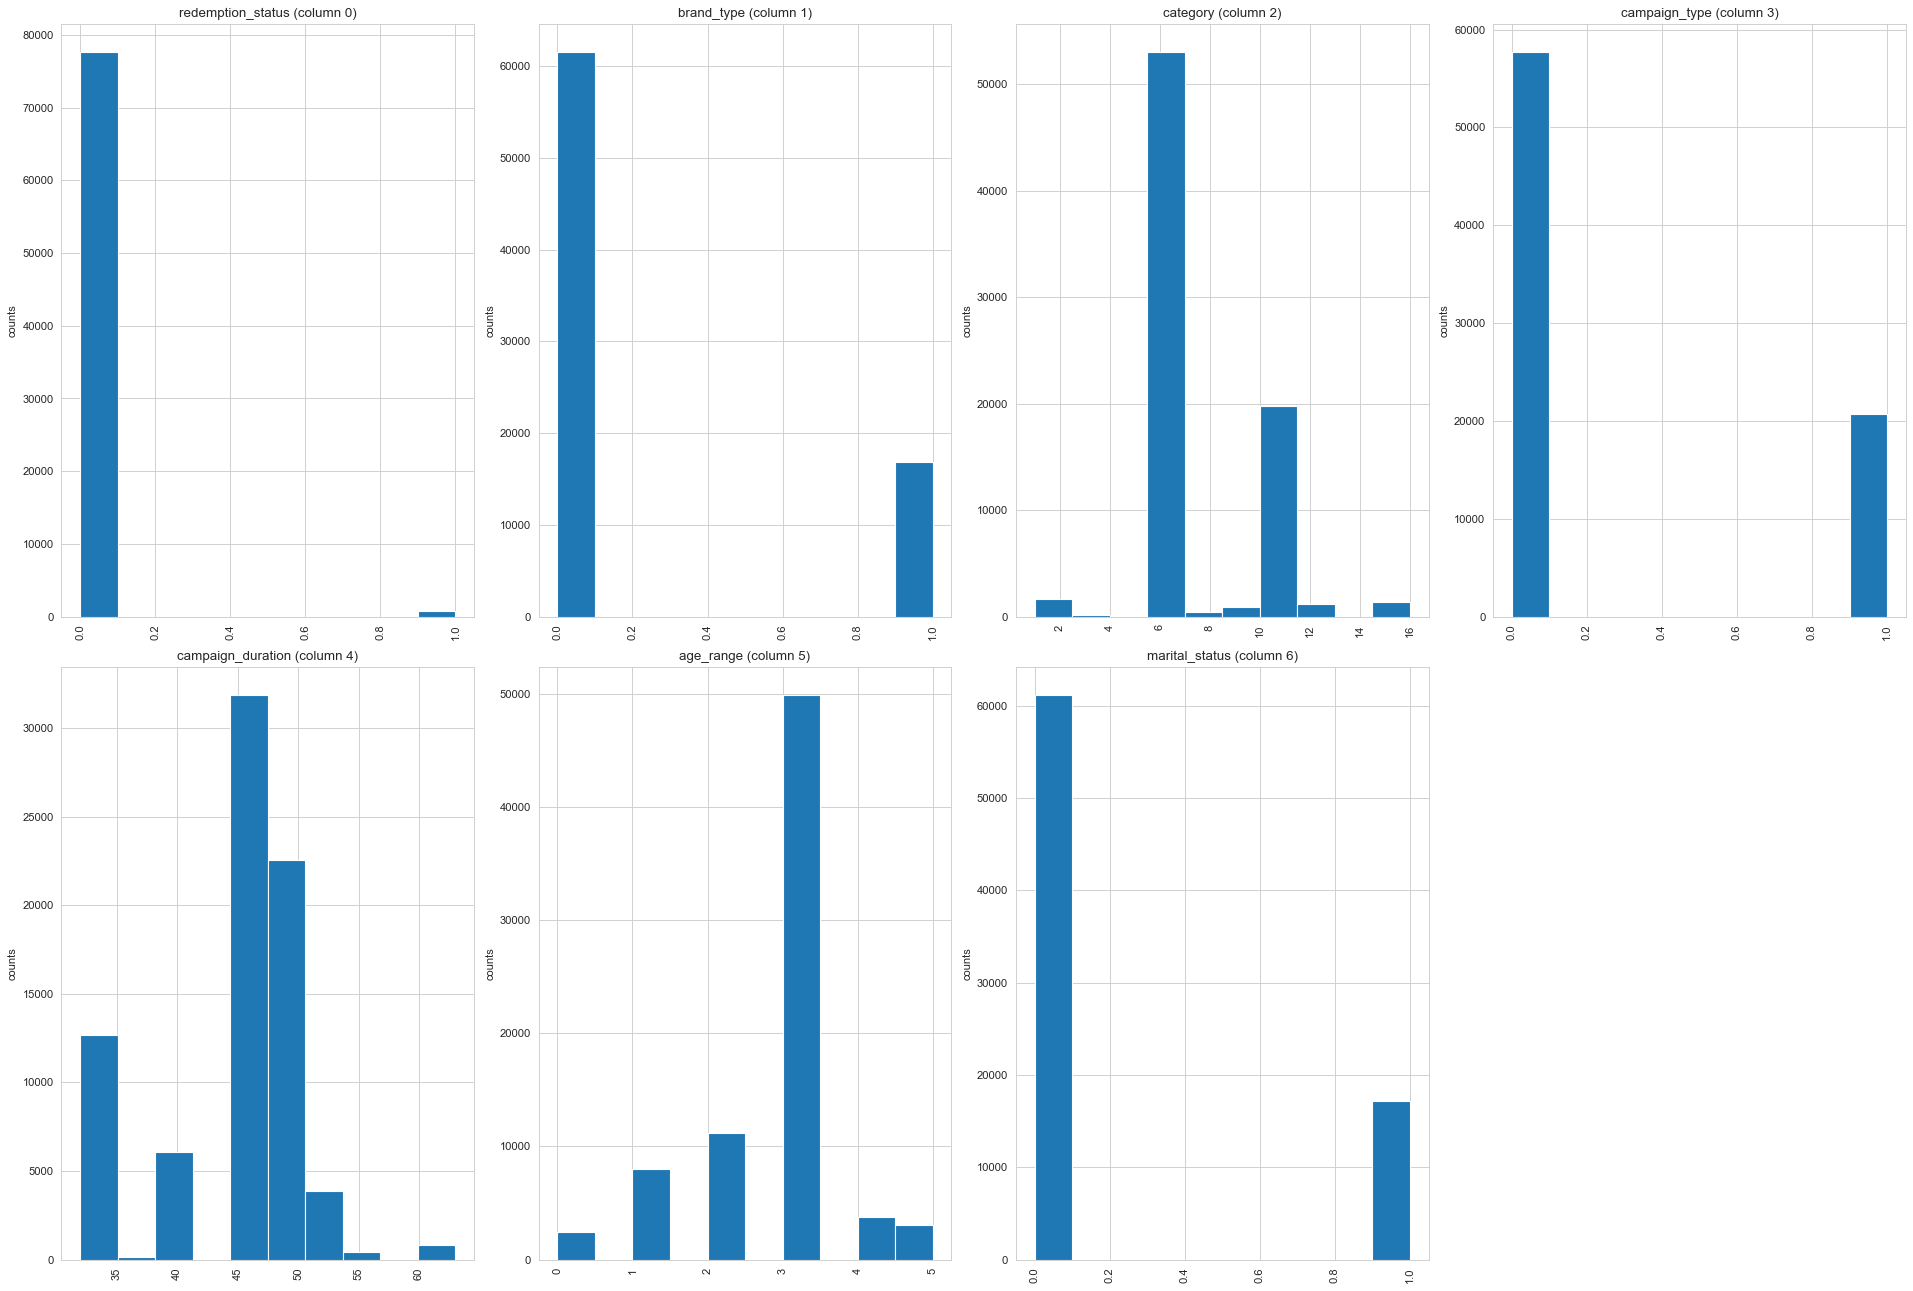

In [1539]:
plotPerColumnDistribution(df,7, 4 )

<AxesSubplot: >

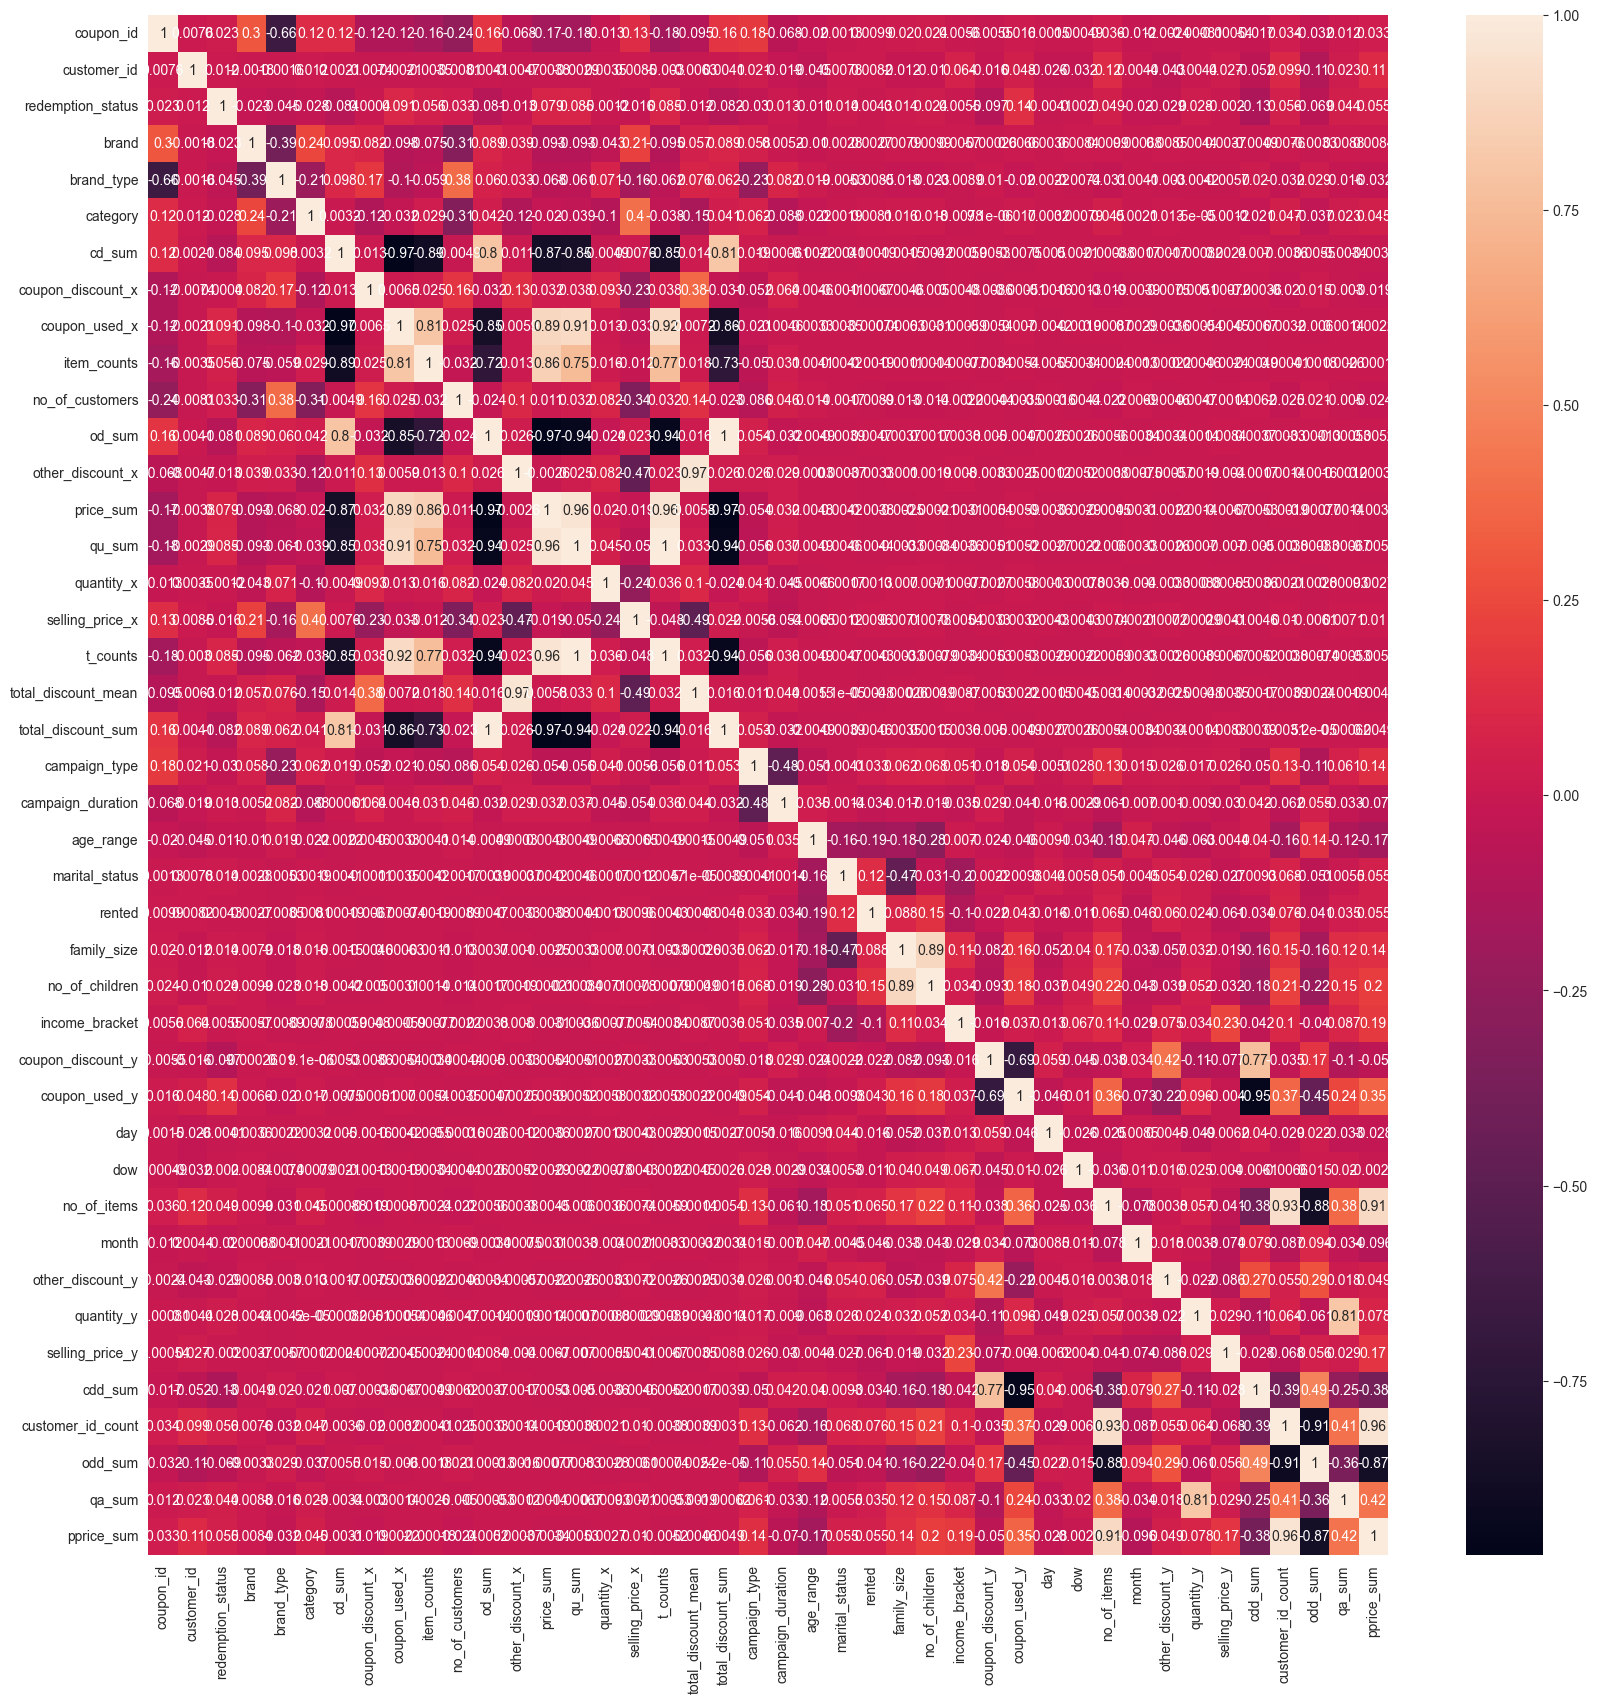

In [1540]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(method='pearson'),annot=True)

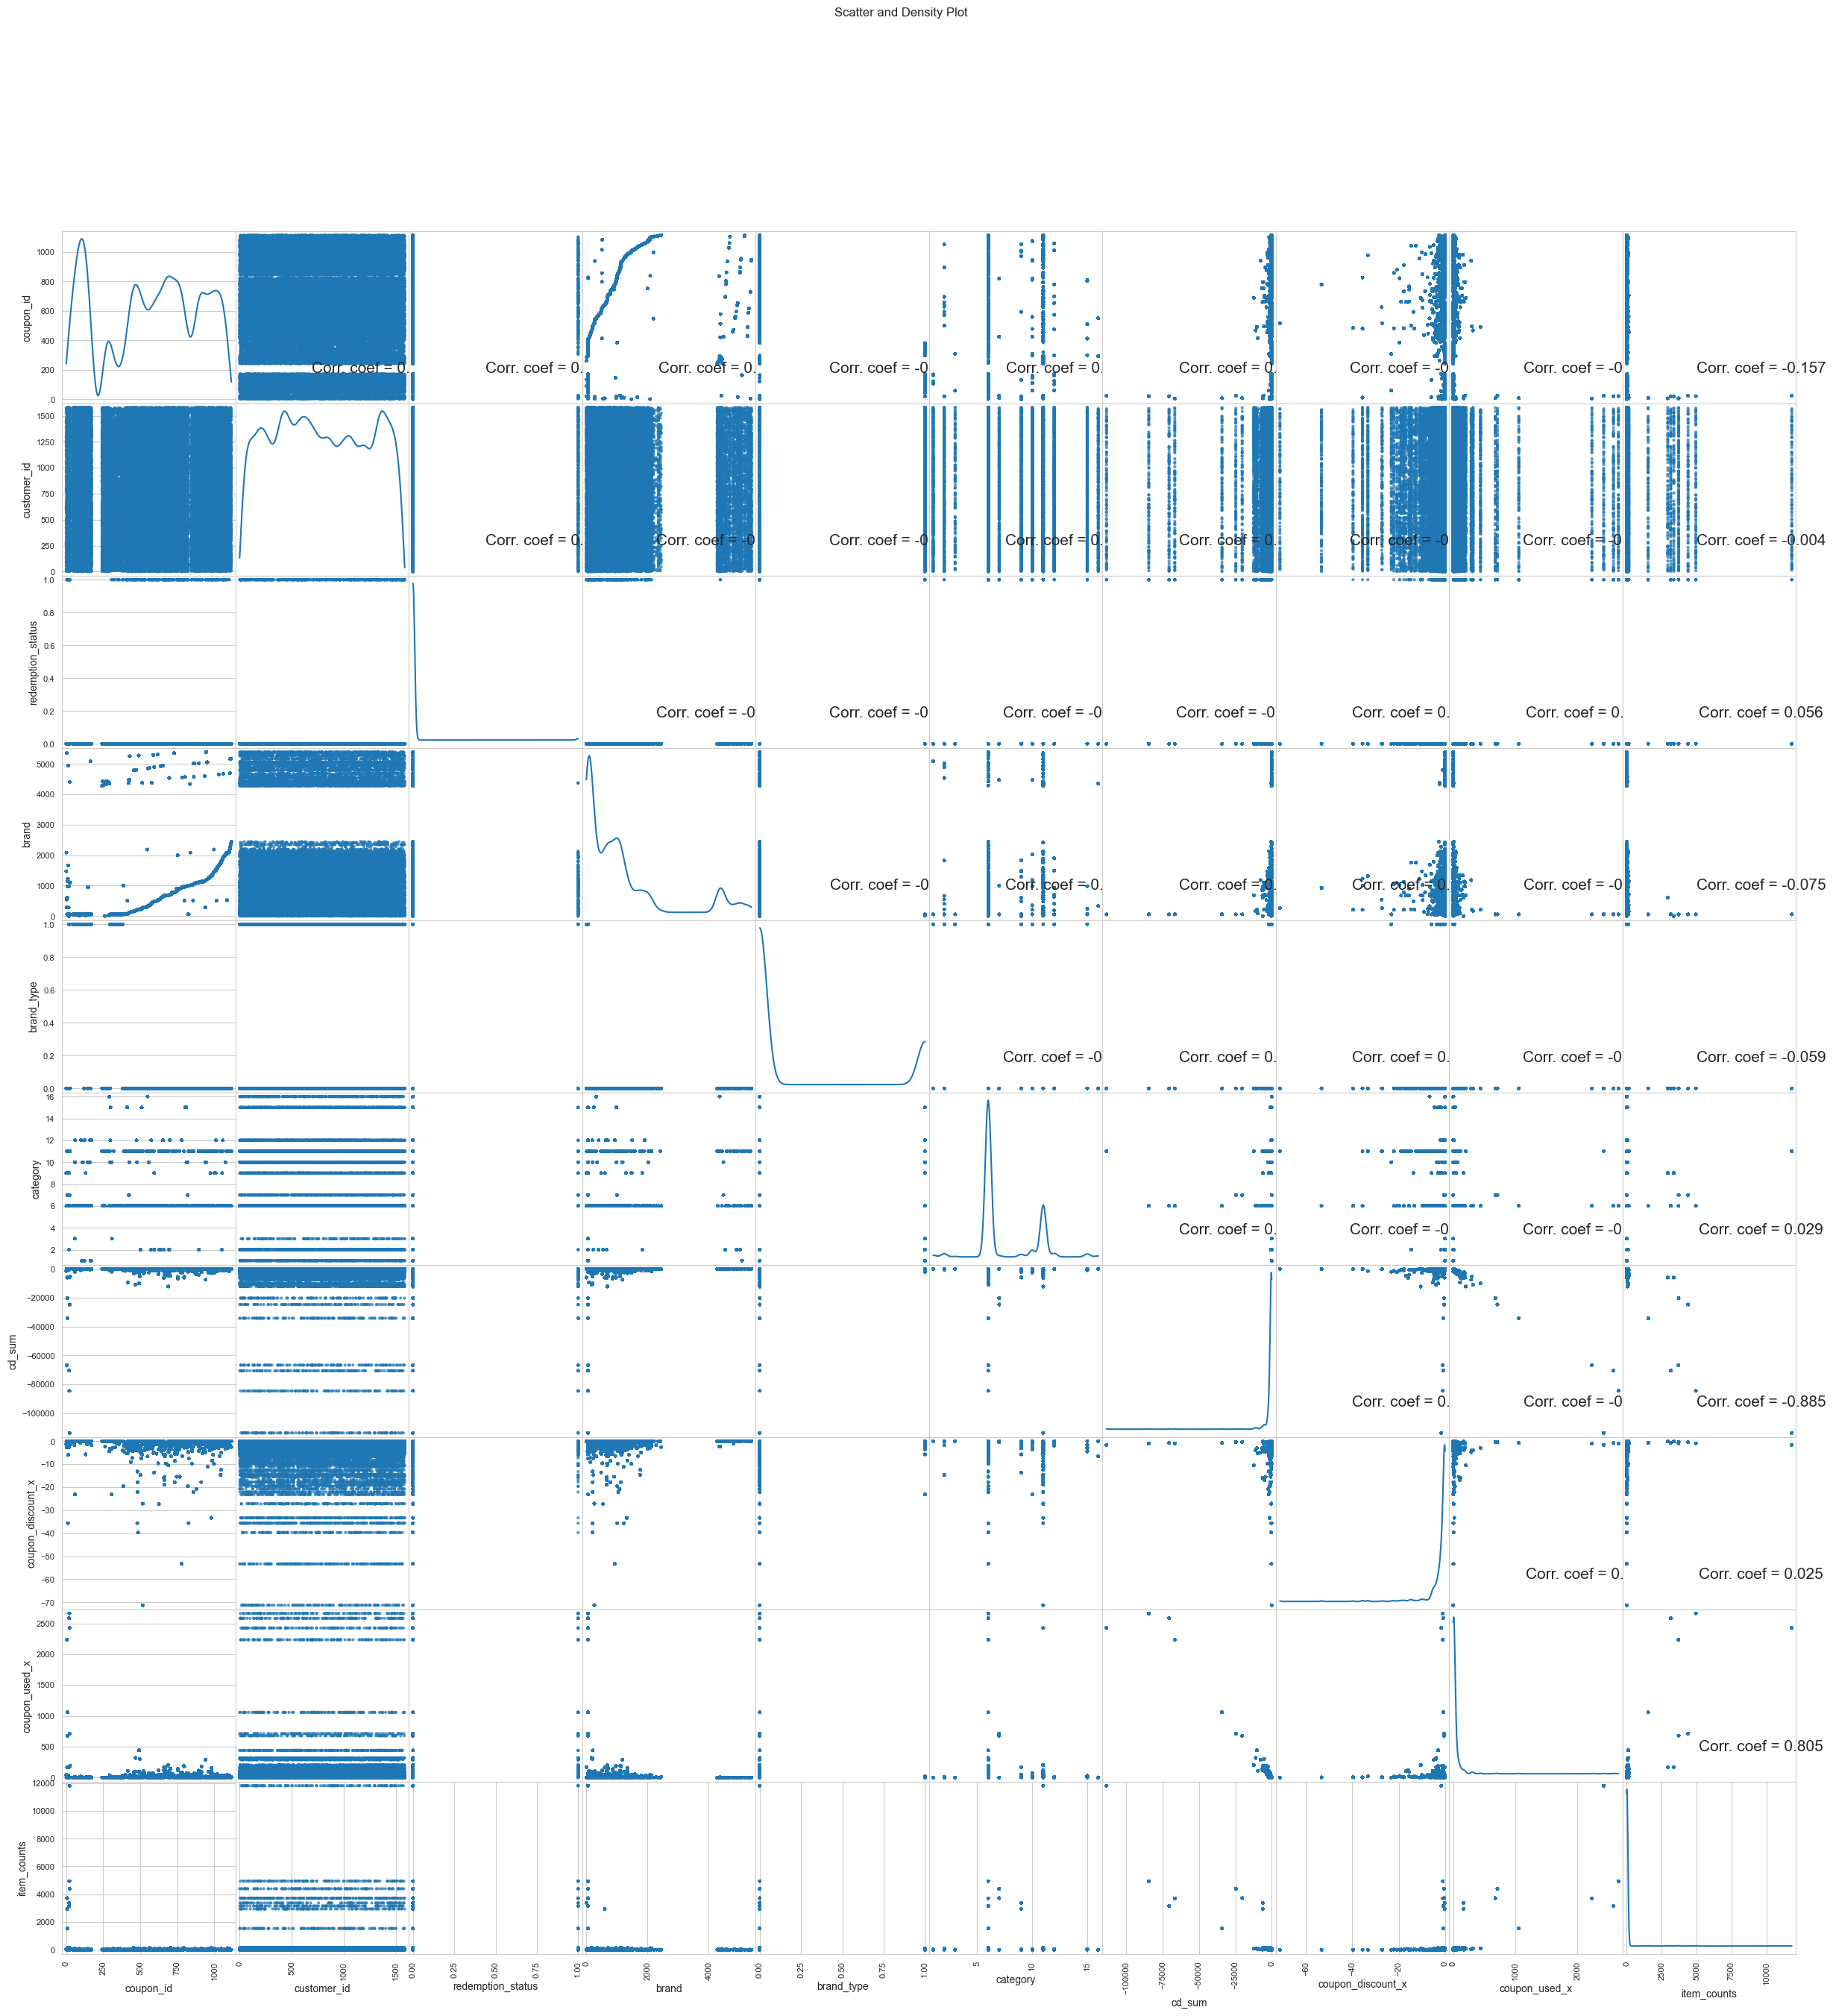

In [1541]:
plotScatterMatrix(df, 30, 15)

## campaign_data.csv

In [1542]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# campaign_data.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv('campaign_data.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'campaign_data.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 28 rows and 4 columns


In [1543]:
df1

,campaign_id,campaign_type,start_date,end_date
0,24,Y,21/10/13,20/12/13
1,25,Y,21/10/13,22/11/13
2,20,Y,07/09/13,16/11/13
3,23,Y,08/10/13,15/11/13
4,21,Y,16/09/13,18/10/13
5,22,X,16/09/13,18/10/13
6,18,X,10/08/13,04/10/13
7,19,Y,26/08/13,27/09/13
8,17,Y,29/07/13,30/08/13
9,16,Y,15/07/13,16/08/13


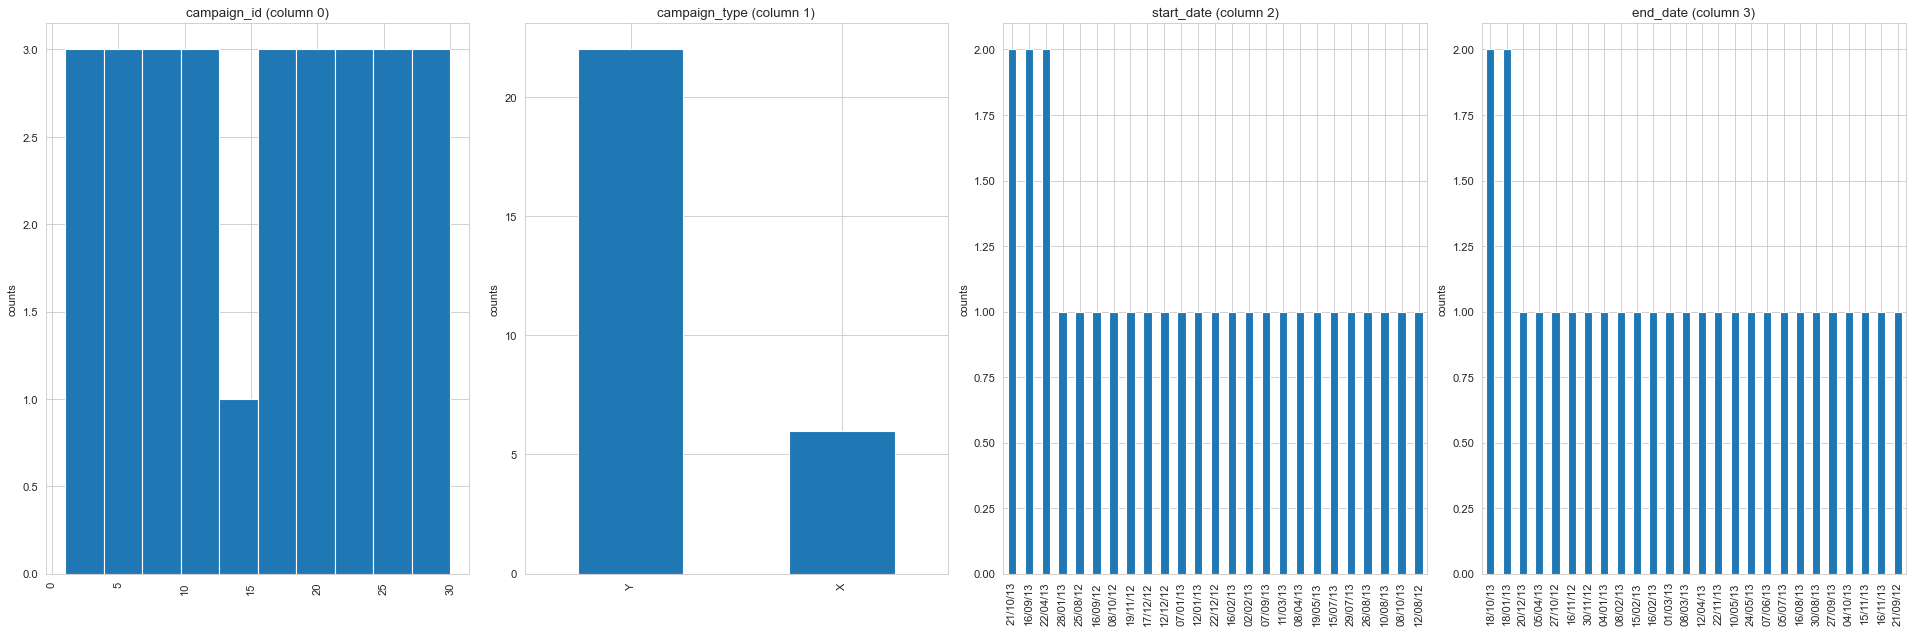

In [1544]:
plotPerColumnDistribution(df1,7, 4 )

## coupon_item_mapping.csv

In [1545]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# coupon_item_mapping.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df2 = pd.read_csv('coupon_item_mapping.csv', delimiter=',', nrows = nRowsRead)
df2.dataframeName = 'coupon_item_mapping.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 2 columns


In [1546]:
df2.head(5)

,coupon_id,item_id
0,105,37
1,107,75
2,494,76
3,522,77
4,518,77


Distribution graphs (histogram/bar graph) of sampled columns:

In [1547]:
plotPerColumnDistribution(df2, 10, 5)

<Figure size 2400x0 with 0 Axes>

Correlation matrix:

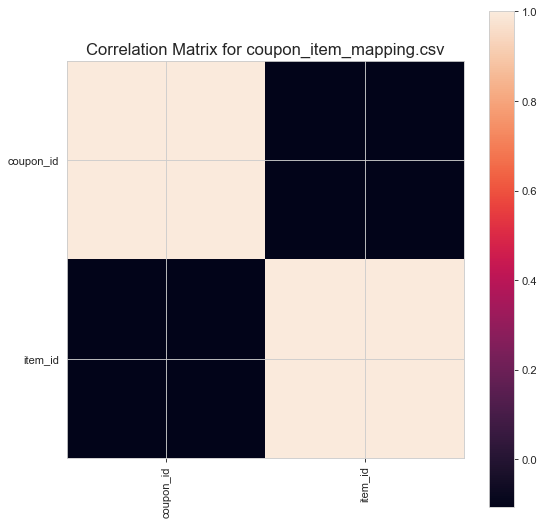

In [1548]:
plotCorrelationMatrix(df2, 8)

<AxesSubplot: >

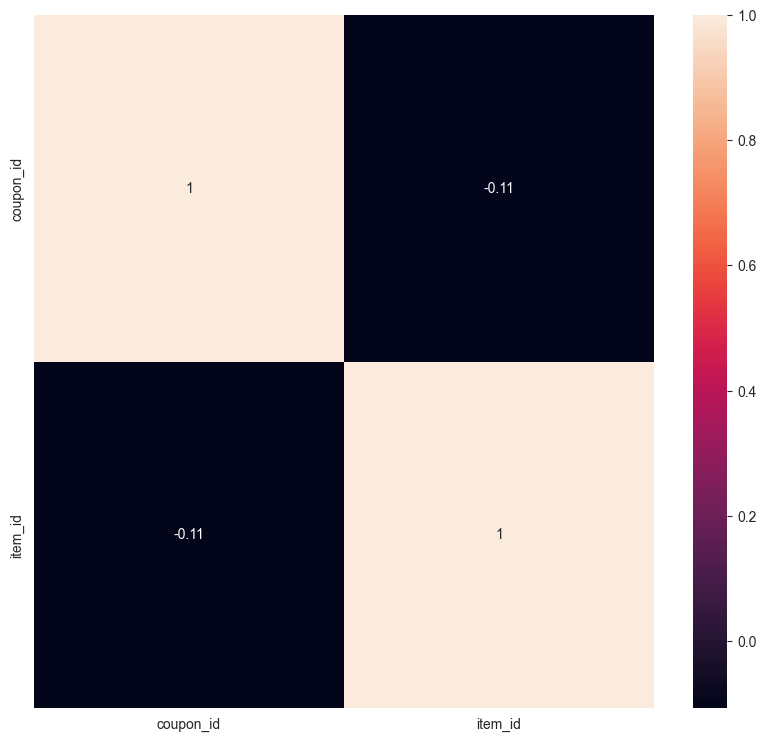

In [1549]:
plt.figure(figsize=(10,9))
sns.heatmap(df2.corr(method='pearson'),annot=True)

Scatter and density plots:

ID? SL?

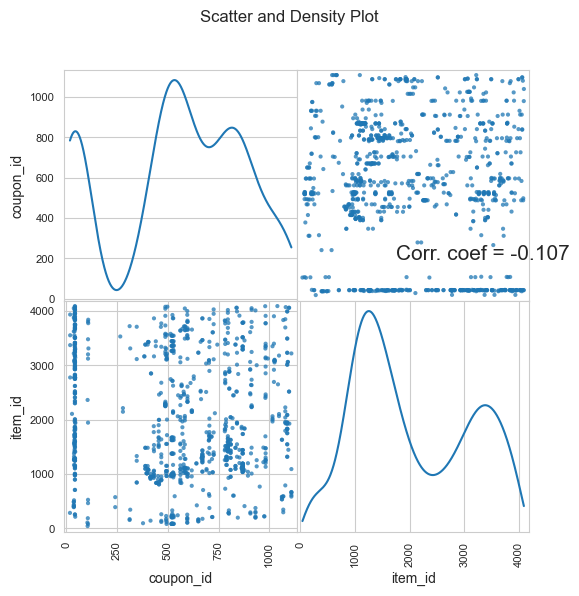

In [1550]:
plotScatterMatrix(df2, 6, 15)

## customer_demographics.csv

In [1551]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# customer_demographics.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df3 = pd.read_csv('customer_demographics.csv', delimiter=',', nrows = nRowsRead)
df3.dataframeName = 'customer_demographics.csv'
nRow, nCol = df3.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 760 rows and 7 columns


In [1552]:
df3.head(5)

,customer_id,age_range,marital_status,rented,family_size,no_of_children,income_bracket
0,1,70+,Married,0,2,NaN,4
1,6,46-55,Married,0,2,NaN,5
2,7,26-35,NaN,0,3,1,3
3,8,26-35,NaN,0,4,2,6
4,10,46-55,Single,0,1,NaN,5


Distribution graphs (histogram/bar graph) of sampled columns:

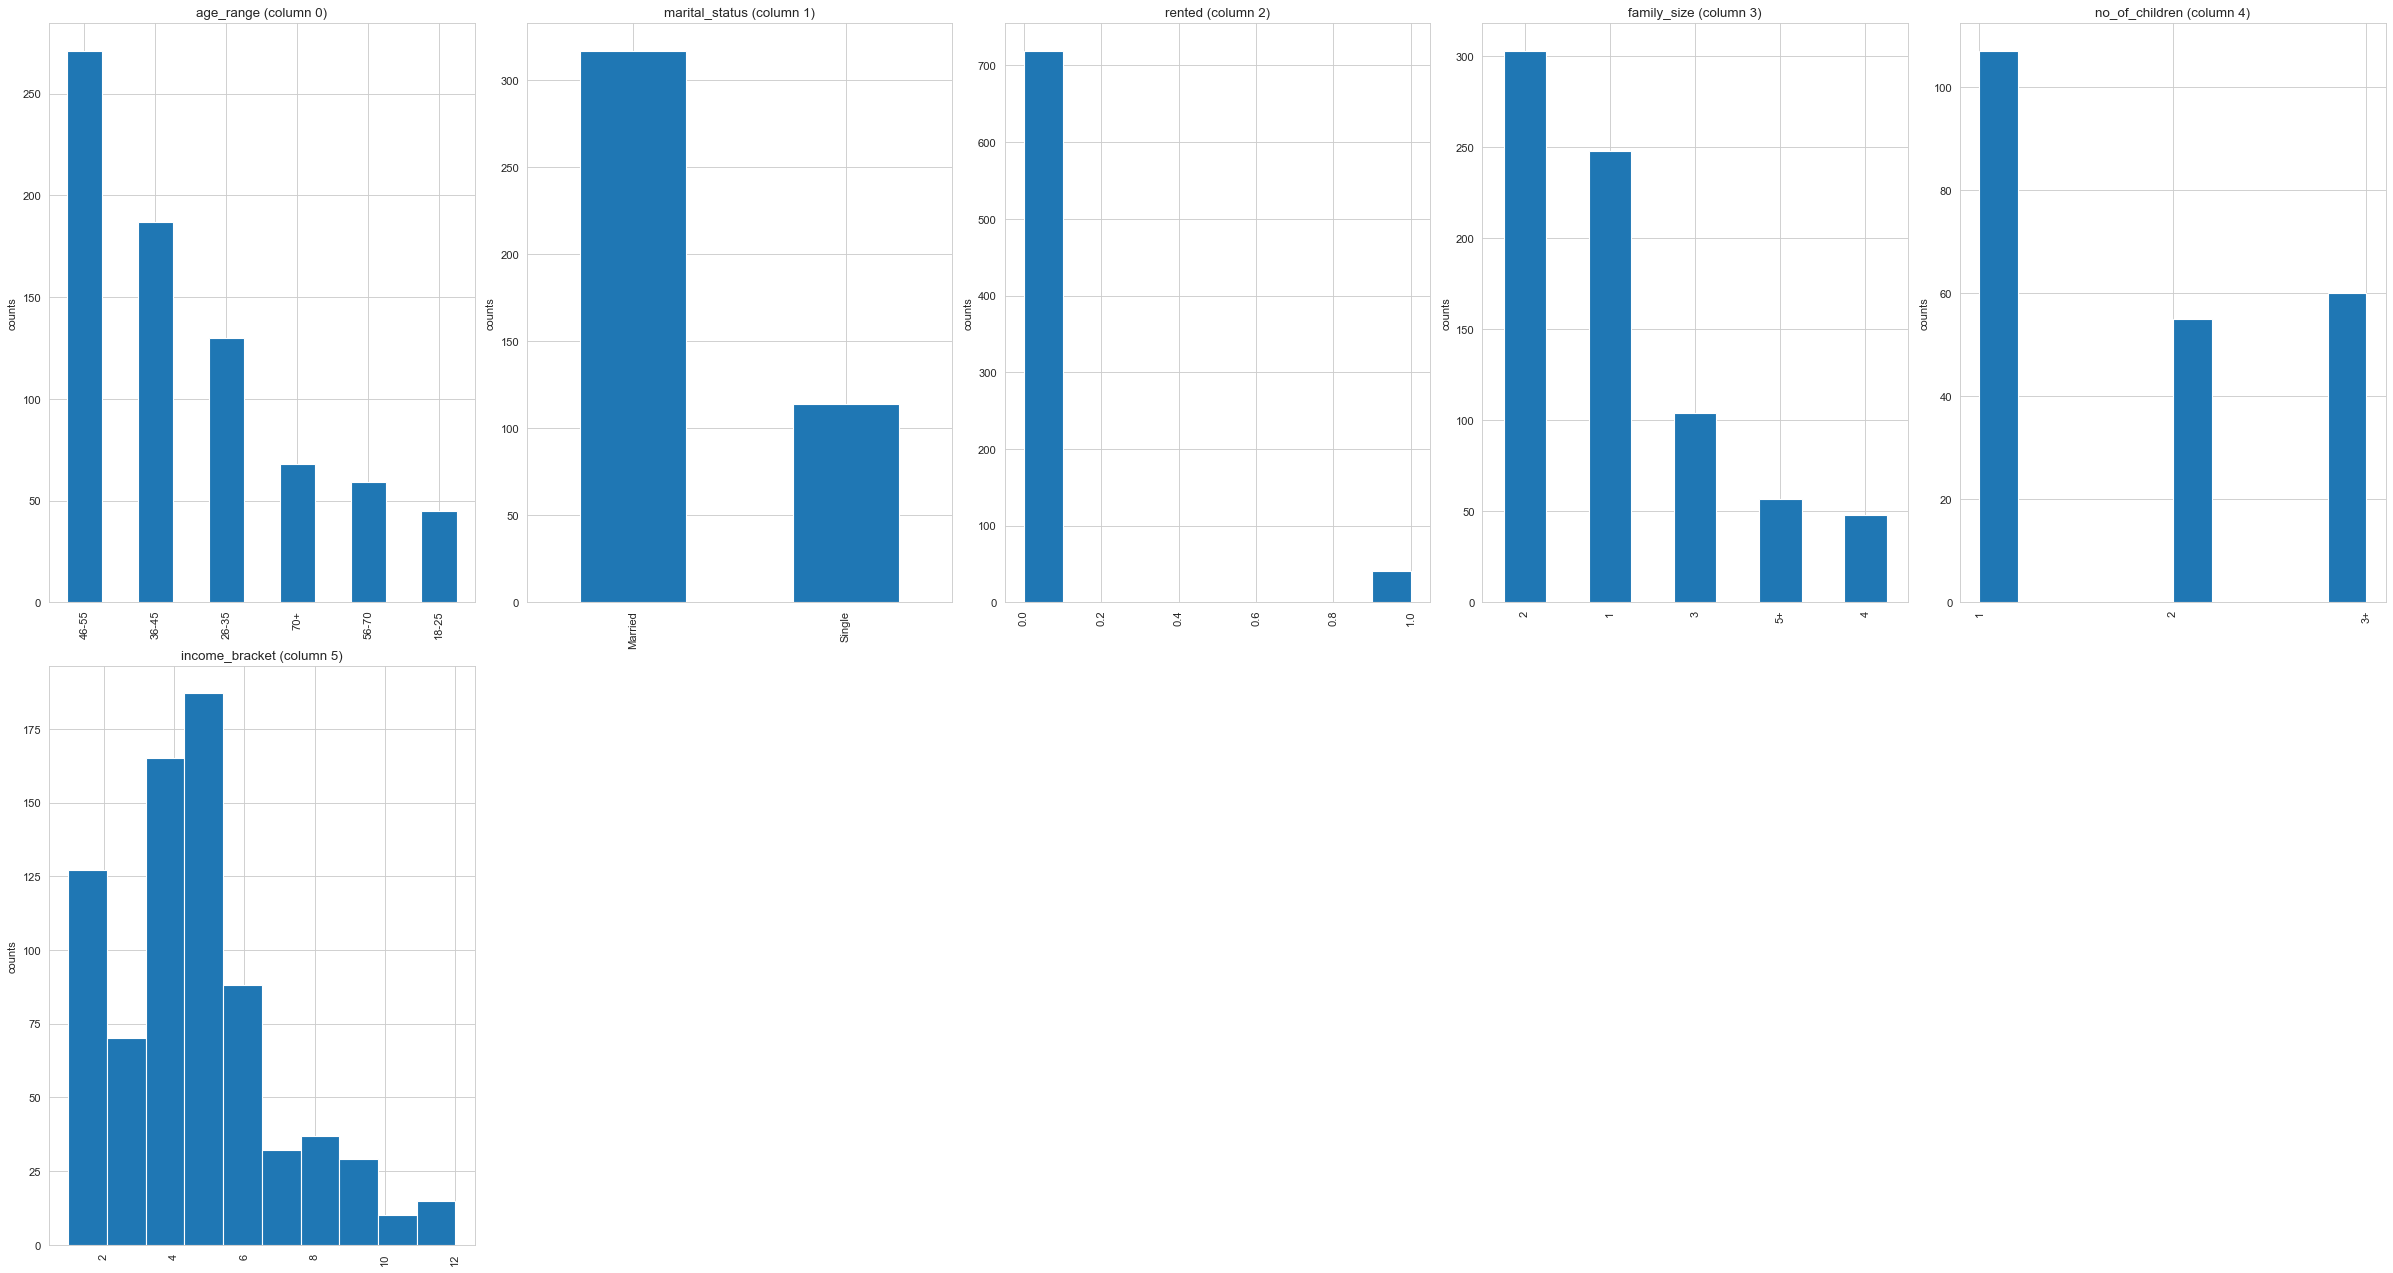

In [1553]:
plotPerColumnDistribution(df3, 10, 5)

Correlation matrix:

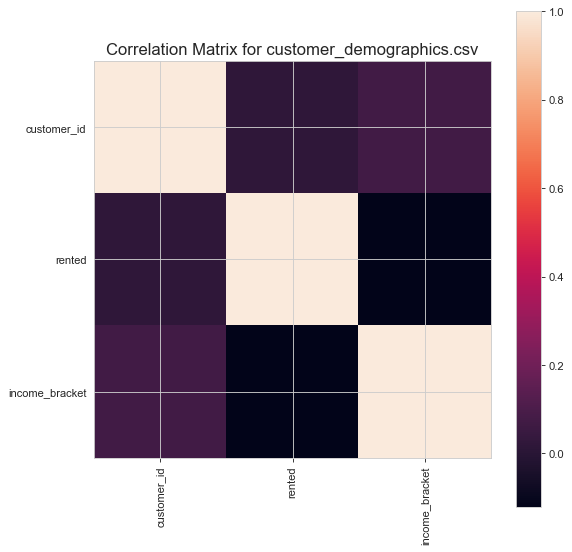

In [1554]:
plotCorrelationMatrix(df3, 8)

Scatter and density plots:

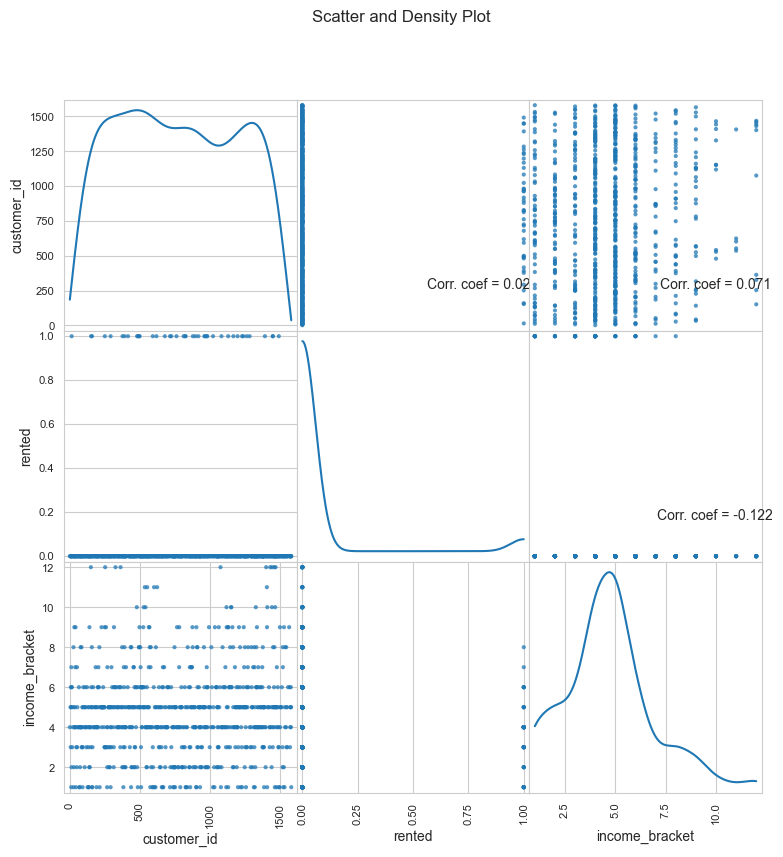

In [1555]:
plotScatterMatrix(df3, 9, 10)

# No Feature Selection

## Logistic Regression

In [1556]:
X = df.drop(['redemption_status'], axis = 1)
y = df['redemption_status']

In [1557]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42, shuffle=True)

In [1558]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
y_pred_LR = LR.predict(x_test)
print(classification_report(y_test,y_pred_LR))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     23315
           1       0.02      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       0.51      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1559]:
print(roc_auc_score(y_test,y_pred_LR))
Model = ['Logistic Regression']
ROC_AUC_Accuracy = [roc_auc_score(y_test,y_pred_LR)]

0.5015430856022444


In [1560]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_LR ):
    cm = metrics.confusion_matrix( y_test,y_pred_LR )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1561]:

#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_LR )

print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23268    47]
 [  195     1]]


In [1562]:
def create_conf_mat(y_test,y_pred_LR):
    if (len(y_test.shape) != len(y_pred_LR.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_LR.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_LR)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

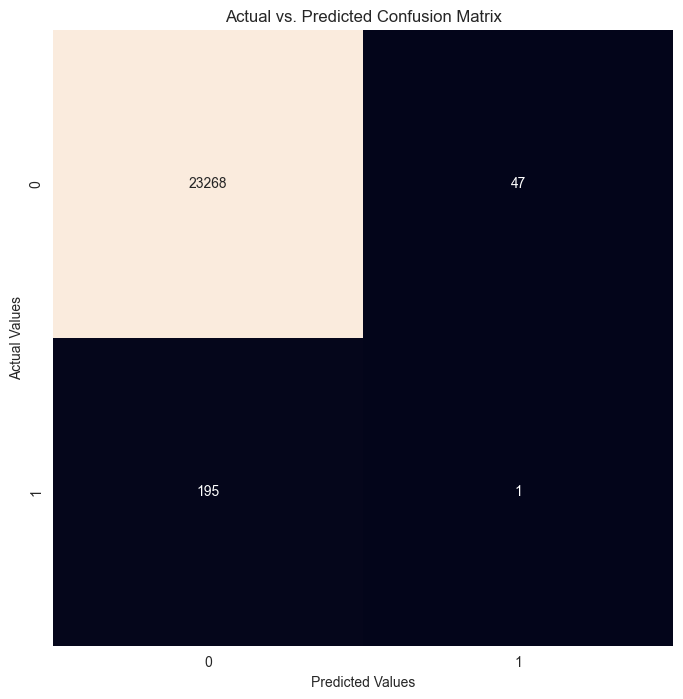

In [1563]:
conf_mat = create_conf_mat(y_test,y_pred_LR)
plt.figure(figsize=(8,8))
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1564]:
#Get predicted probabilites
target_probailities_log = LR.predict_proba(x_test)[:,1]

In [1565]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)


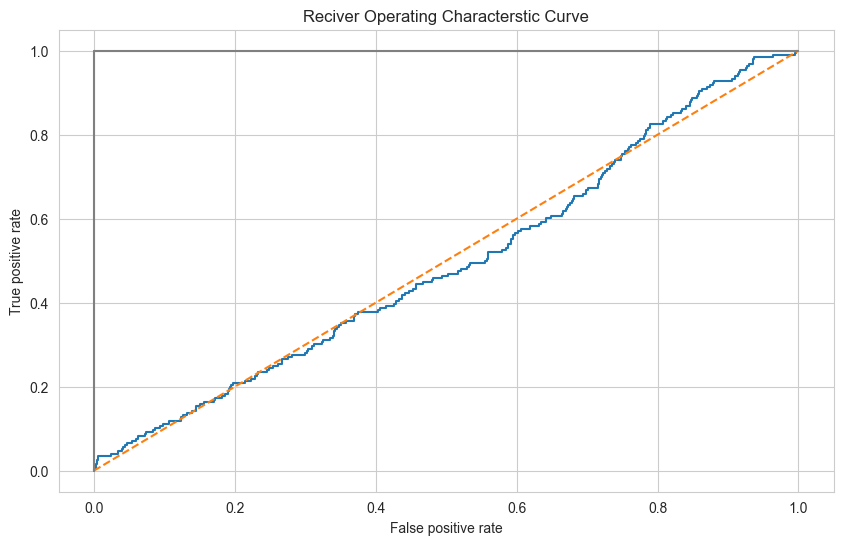

In [1566]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

## Naive Bayes

In [1567]:
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
print(roc_auc_score(y_test,y_pred_nb))
Model.append('Naive Bayes')
ROC_AUC_Accuracy.append(roc_auc_score(y_test,y_pred_nb))

0.5854430448997099


In [1568]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.06      0.20      0.09       196

    accuracy                           0.97     23511
   macro avg       0.52      0.59      0.54     23511
weighted avg       0.99      0.97      0.97     23511



In [1569]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
results=confusion_matrix(y_test,y_pred_LR)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_LR) )
print ('Report : ')
print (classification_report(y_test,y_pred_LR) )

Confusion Matrix :
[[23268    47]
 [  195     1]]
Accuracy Score : 0.9897069456849985
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     23315
           1       0.02      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       0.51      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1570]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_nb ):
    cm = metrics.confusion_matrix( y_test,y_pred_nb )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1571]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_nb )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[22660   655]
 [  157    39]]


In [1572]:
def create_conf_mat(y_test,y_pred_nb):
    if (len(y_test.shape) != len(y_pred_nb.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_nb.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_nb)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

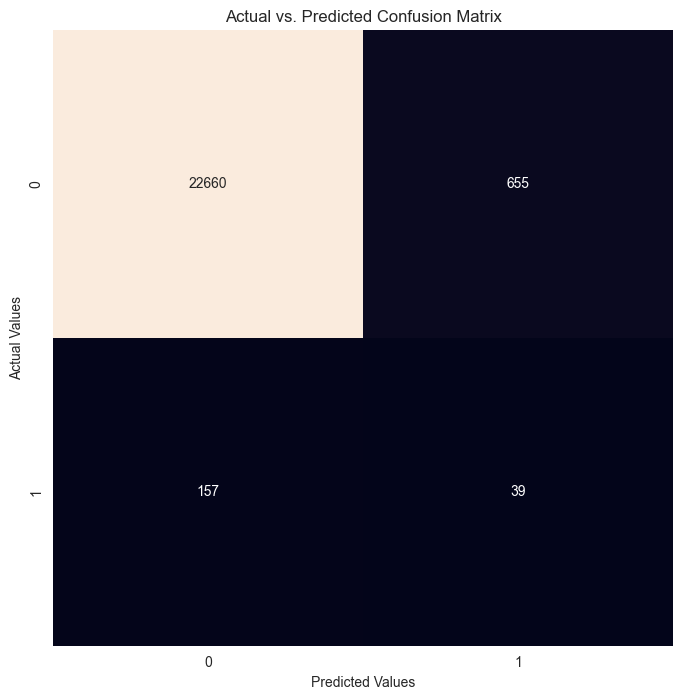

In [1573]:
conf_mat = create_conf_mat(y_test,y_pred_nb)
plt.figure(figsize=(8,8))
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1574]:
#Get predicted probabilites
target_probailities_log = nb.predict_proba(x_test)[:,1]

In [1575]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

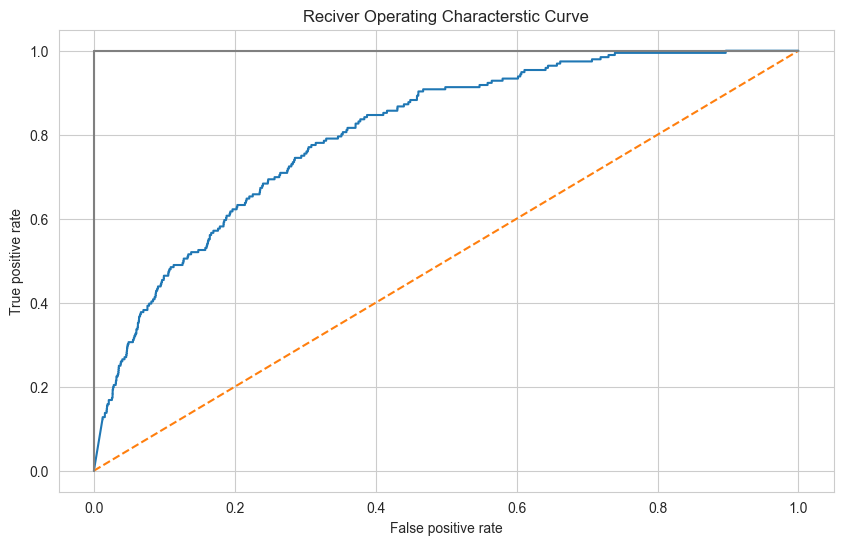

In [1576]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

## Decision Tree

In [1577]:
params = {
    
    'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':range(1,10),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

dt = DecisionTreeClassifier()

rs = RandomizedSearchCV(estimator=dt,n_jobs=-1,cv=3,param_distributions=params,scoring='recall')
rs.fit(X,y)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'splitter': ['best', 'random']},
                   scoring='recall')

In [1578]:
dt = DecisionTreeClassifier(**rs.best_params_)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(roc_auc_score(y_test,y_pred_dt))
Model.append('Decision Tree')
ROC_AUC_Accuracy.append(roc_auc_score(y_test,y_pred_dt))

0.5050162591307163


In [1579]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.33      0.01      0.02       196

    accuracy                           0.99     23511
   macro avg       0.66      0.51      0.51     23511
weighted avg       0.99      0.99      0.99     23511



In [1580]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_dt):
    cm = metrics.confusion_matrix( y_test,y_pred_dt )
    plt.figure(figsize=(8,8))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1581]:
results=confusion_matrix(y_test,y_pred_dt)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_dt) )
print ('Report : ')
print (classification_report(y_test,y_pred_dt))

Confusion Matrix :
[[23311     4]
 [  194     2]]
Accuracy Score : 0.9915784101059079
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.33      0.01      0.02       196

    accuracy                           0.99     23511
   macro avg       0.66      0.51      0.51     23511
weighted avg       0.99      0.99      0.99     23511



In [1582]:
def create_conf_mat(y_test,y_pred_dt):
    if (len(y_test.shape) != len(y_pred_dt.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_dt.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_dt)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

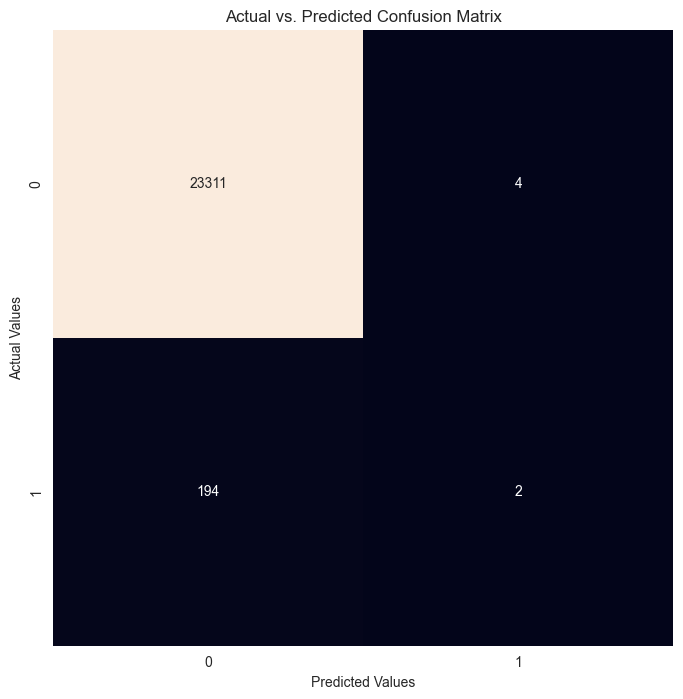

In [1583]:
conf_mat = create_conf_mat(y_test,y_pred_dt)
plt.figure(figsize=(8,8))
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1584]:
#Get predicted probabilites
target_probailities_log = dt.predict_proba(x_test)[:,1]

In [1585]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

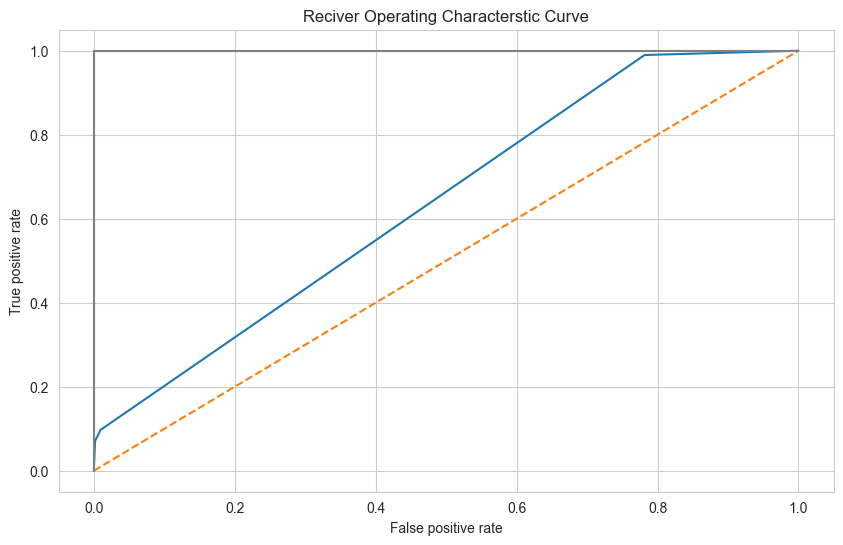

In [1586]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()


## Random Forest

In [1587]:
params = {
    
    'n_estimators':range(10,100,10),
    'criterion':['gini','entropy'],
    'max_depth':range(2,10,1),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

rf = RandomForestClassifier()

rs = RandomizedSearchCV(estimator=rf,param_distributions=params,cv=3,scoring='recall',n_jobs=-1)
rs.fit(X,y)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(2, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'n_estimators': range(10, 100, 10)},
                   scoring='recall')

In [1588]:
rf = RandomForestClassifier(**rs.best_params_)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(roc_auc_score(y_test,y_pred_rf))
Model.append('Random Forest')
ROC_AUC_Accuracy.append(roc_auc_score(y_test,y_pred_rf))

0.5025510204081632


In [1589]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       1.00      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       1.00      0.50      0.50     23511
weighted avg       0.99      0.99      0.99     23511



In [1590]:
results=confusion_matrix(y_test,y_pred_rf)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_rf) )
print ('Report : ')
print (classification_report(y_test,y_pred_rf) )


Confusion Matrix :
[[23315     0]
 [  195     1]]
Accuracy Score : 0.991706009952788
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       1.00      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       1.00      0.50      0.50     23511
weighted avg       0.99      0.99      0.99     23511



In [1591]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_rf ):
    cm = metrics.confusion_matrix( y_test,y_pred_rf )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1592]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_rf )
print("confusion matrix = \n",mat_pruned)


confusion matrix = 
 [[23315     0]
 [  195     1]]


In [1593]:
def create_conf_mat(y_test,y_pred_rf):
    if (len(y_test.shape) != len(y_pred_rf.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_rf.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_rf)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

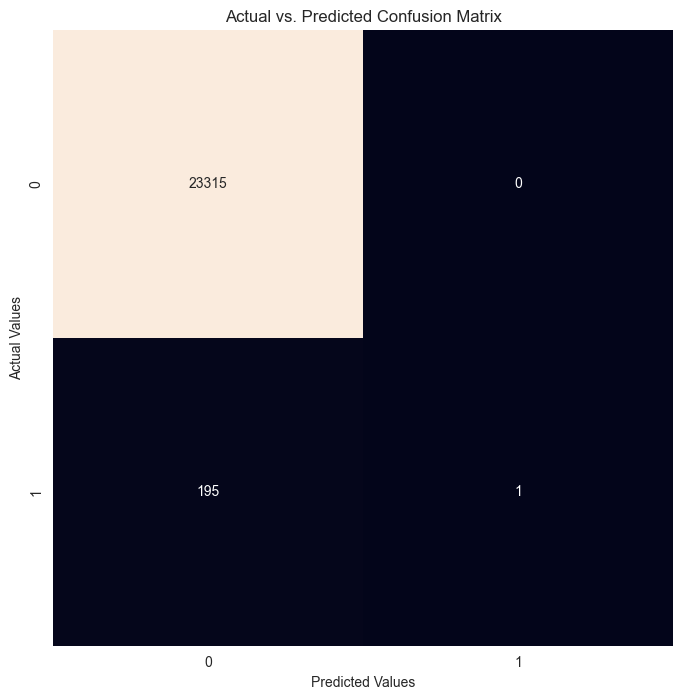

In [1594]:
conf_mat = create_conf_mat(y_test,y_pred_rf)
plt.figure(figsize=(8,8))
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1595]:
#Get predicted probabilites
target_probailities_log = rf.predict_proba(x_test)[:,1]

In [1596]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)


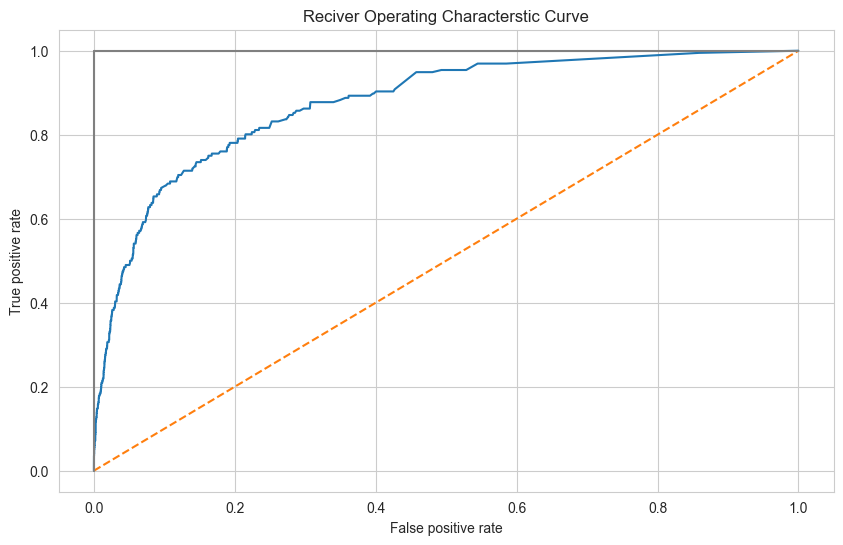

In [1597]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1598]:
final_result = pd.DataFrame({'Model':Model,'Accuracy':ROC_AUC_Accuracy})
final_result

,Model,Accuracy
0,Logistic Regression,0.501543
1,Naive Bayes,0.585443
2,Decision Tree,0.505016
3,Random Forest,0.502551


# Feature Selection

## Recursive Feature Elimination

In [1599]:
from sklearn.feature_selection import RFE
X = df.drop(['redemption_status'], axis = 1)
y = df['redemption_status']

In [1600]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
rfe = RFE(model, n_features_to_select = 41)
X_rfe = rfe.fit_transform(X,y)
model.fit(X_rfe,y)
print(rfe.support_)
print(rfe.ranking_)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [1601]:
from sklearn.metrics import roc_auc_score

In [1602]:
# no of features
nof_list = np.arange(1,42)
high_score = 0
#Variable to store the optimum feature
nof = 0
score_list=[]
for n in range(len(nof_list)):
    X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.3,random_state=0)
    model = LinearRegression()
    rfe = RFE(model,n_features_to_select=nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train,Y_train)
    X_test_rfe = rfe.transform(X_test)
    model.fit(X_train_rfe,Y_train)
    Y_pred = model.predict(X_test_rfe)
    score = roc_auc_score(Y_test,Y_pred)
    score_list.append(score)
    if(score>high_score):
        high_score=score
        nof = nof_list[n]
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" %(nof, high_score))

Optimum number of features: 32
Score with 32 features: 0.892358


In [1603]:
cols = list(X.columns)
model=LinearRegression()
#Initializing RFE Model
rfe = RFE(model,n_features_to_select = 32)
#Transforming data using RFE
X_rfe = rfe.fit_transform(X,y)
#Fitting data to model
model.fit(X_rfe,y)
temp = pd.Series(rfe.support_,index = cols)
selected_features_rfe = temp[temp==True].index
print(selected_features_rfe)
len(selected_features_rfe)

Index(['coupon_id', 'brand_type', 'category', 'cd_sum', 'coupon_discount_x',
       'coupon_used_x', 'item_counts', 'no_of_customers', 'od_sum',
       'other_discount_x', 'quantity_x', 'selling_price_x', 't_counts',
       'total_discount_mean', 'total_discount_sum', 'campaign_type',
       'campaign_duration', 'age_range', 'marital_status', 'rented',
       'family_size', 'no_of_children', 'income_bracket', 'coupon_discount_y',
       'coupon_used_y', 'day', 'dow', 'month', 'other_discount_y',
       'quantity_y', 'selling_price_y', 'cdd_sum'],
      dtype='object')


32

In [1604]:
col_names=selected_features_rfe
x=df[col_names]

In [1605]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42, shuffle=True)

# Logistic Regression

In [1606]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
y_pred_LR = LR.predict(x_test)
print(classification_report(y_test,y_pred_LR))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.14      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       0.57      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1607]:
print(roc_auc_score(y_test,y_pred_LR))
Model = ['Logistic Regression']
ROC_AUC_Accuracy_RFE = [roc_auc_score(y_test,y_pred_LR)]

0.502422347879748


In [1608]:
#Function to visulise confusion matrix

def draw_cm( y_test,y_pred_LR ):
    cm = metrics.confusion_matrix( y_test,y_pred_LR )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1609]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_LR )

print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23309     6]
 [  195     1]]


In [1610]:
def create_conf_mat(y_test,y_pred_LR):
    if (len(y_test.shape) != len(y_pred_LR.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_LR.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_LR)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

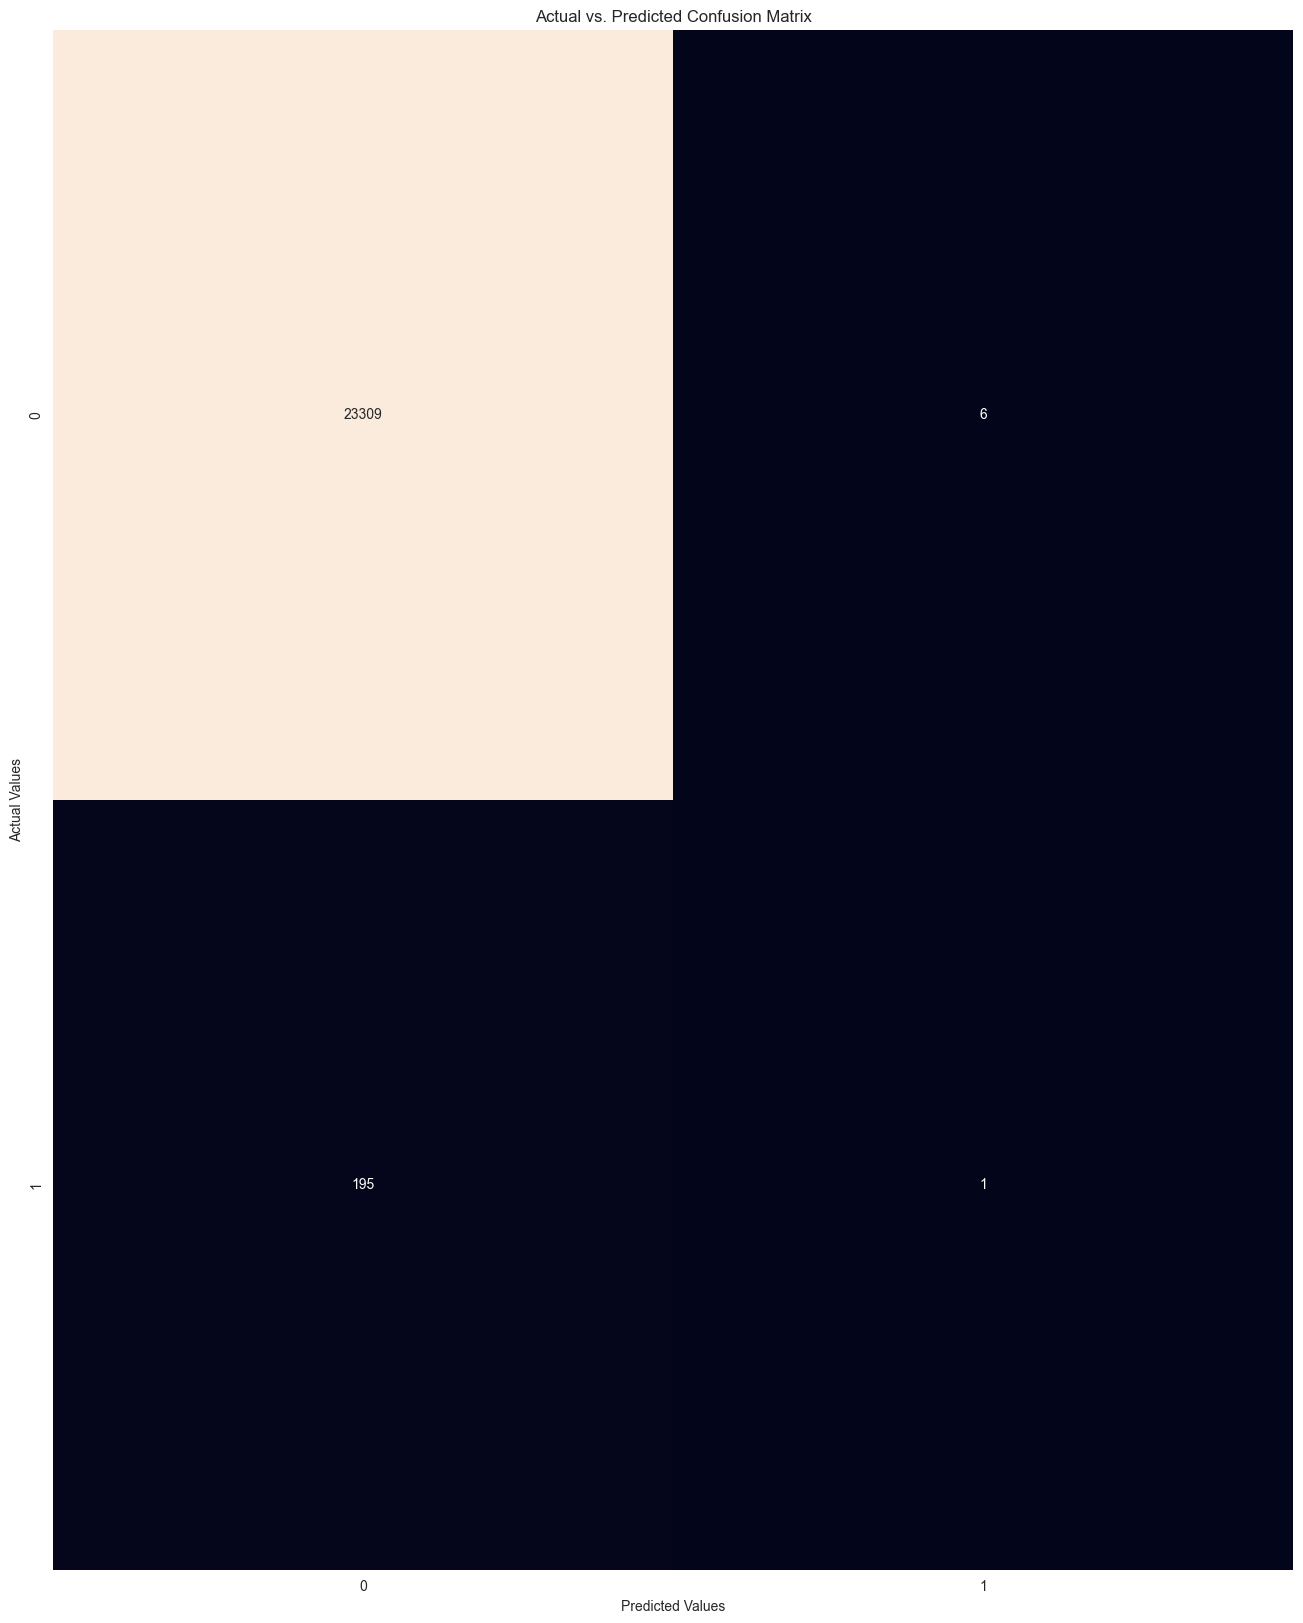

In [1611]:
    conf_mat = create_conf_mat(y_test,y_pred_LR)
    sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Actual vs. Predicted Confusion Matrix')
    plt.show()

In [1612]:
#Get predicted probabilites
target_probailities_log = LR.predict_proba(x_test)[:,1]

In [1613]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)


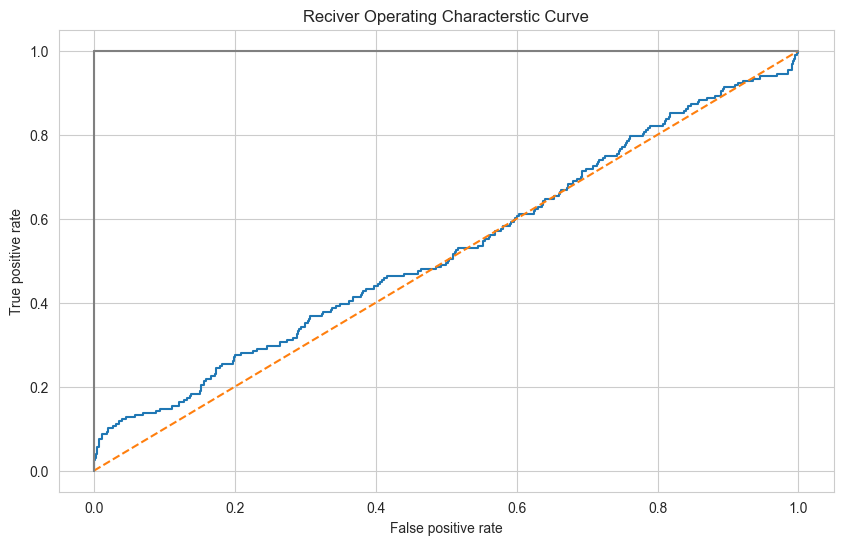

In [1614]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

# Naive Bayes

In [1615]:
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
print(roc_auc_score(y_test,y_pred_nb))
Model.append('Naive Bayes')
ROC_AUC_Accuracy_RFE.append(roc_auc_score(y_test,y_pred_nb))

0.5868145671307339


In [1616]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.05      0.20      0.08       196

    accuracy                           0.96     23511
   macro avg       0.52      0.59      0.53     23511
weighted avg       0.99      0.96      0.97     23511



In [1617]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
results=confusion_matrix(y_test,y_pred_LR)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_LR) )
print ('Report : ')
print (classification_report(y_test,y_pred_LR) )

Confusion Matrix :
[[23309     6]
 [  195     1]]
Accuracy Score : 0.9914508102590277
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.14      0.01      0.01       196

    accuracy                           0.99     23511
   macro avg       0.57      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1618]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_nb ):
    cm = metrics.confusion_matrix( y_test,y_pred_nb )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1619]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_nb )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[22605   710]
 [  156    40]]


In [1620]:
def create_conf_mat(y_test,y_pred_nb):
    if (len(y_test.shape) != len(y_pred_nb.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_nb.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_nb)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

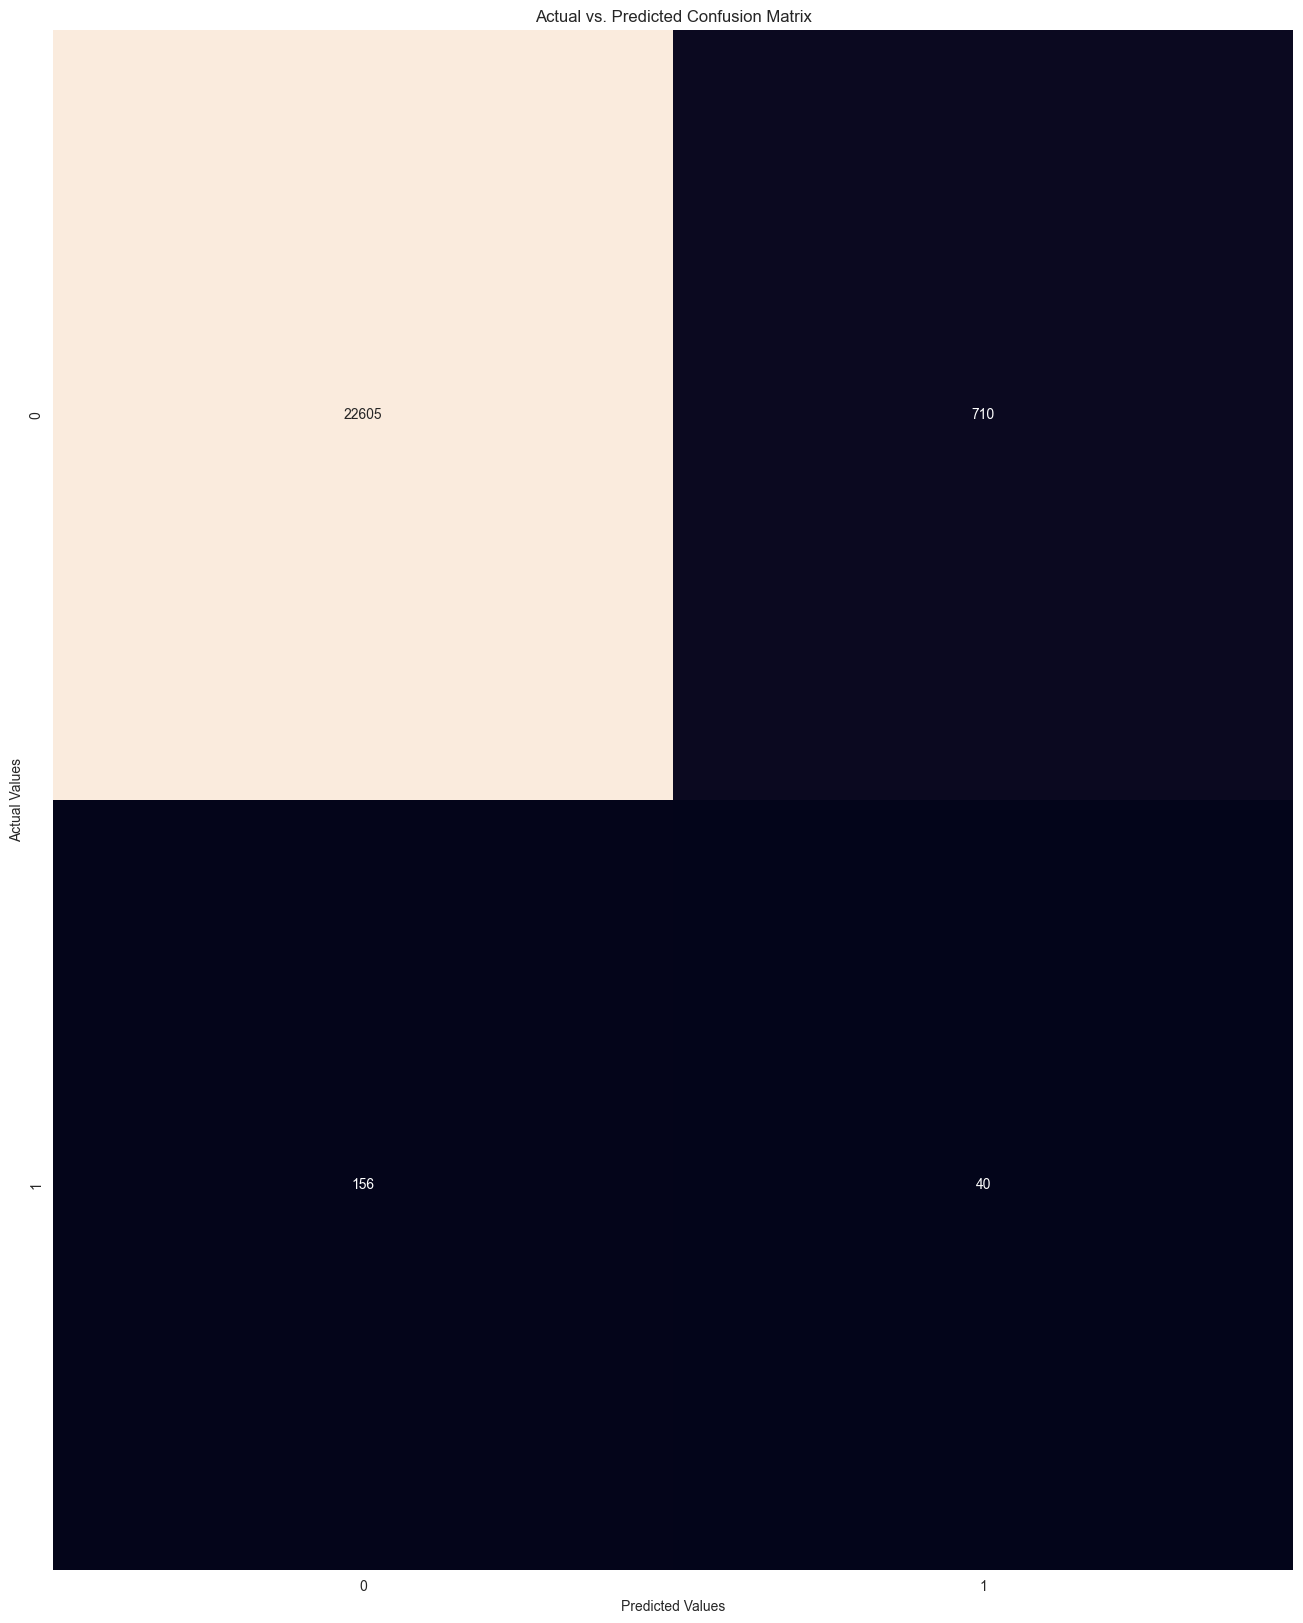

In [1621]:
conf_mat = create_conf_mat(y_test,y_pred_nb)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1622]:
#Get predicted probabilites
target_probailities_log = nb.predict_proba(x_test)[:,1]

In [1623]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

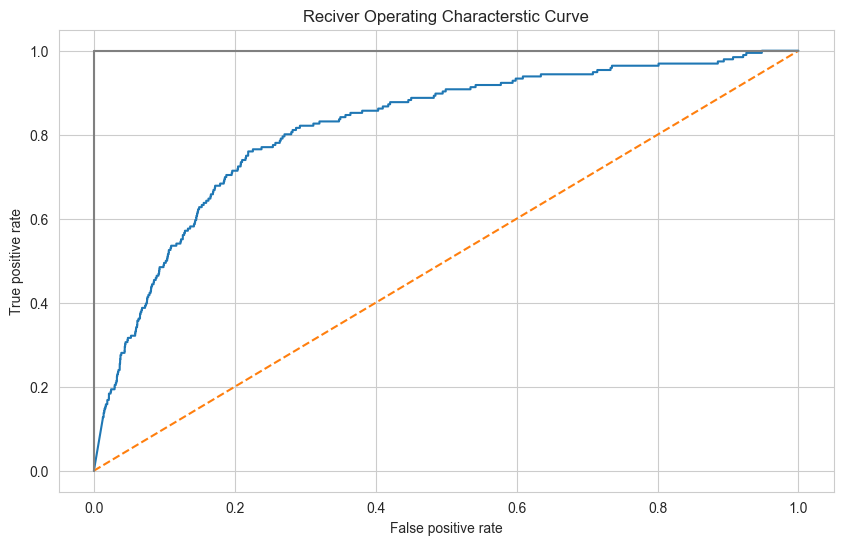

In [1624]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()


In [1625]:
Model,ROC_AUC_Accuracy_RFE

(['Logistic Regression', 'Naive Bayes'],
 [0.502422347879748, 0.5868145671307339])

# Decision Tree

In [1626]:
params = {
    
    'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':range(1,10),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

dt = DecisionTreeClassifier()

rs = RandomizedSearchCV(estimator=dt,n_jobs=-1,cv=3,param_distributions=params,scoring='recall')
rs.fit(x,y)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'splitter': ['best', 'random']},
                   scoring='recall')

In [1627]:
dt = DecisionTreeClassifier(**rs.best_params_)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(roc_auc_score(y_test,y_pred_dt))
Model.append('Decision Tree')
ROC_AUC_Accuracy_RFE.append(roc_auc_score(y_test,y_pred_dt))

0.5125620932481935


In [1628]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.36      0.03      0.05       196

    accuracy                           0.99     23511
   macro avg       0.67      0.51      0.52     23511
weighted avg       0.99      0.99      0.99     23511



In [1629]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_dt):
    cm = metrics.confusion_matrix( y_test,y_pred_dt )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1630]:
results=confusion_matrix(y_test,y_pred_dt)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_dt) )
print ('Report : ')
print (classification_report(y_test,y_pred_dt) )

Confusion Matrix :
[[23306     9]
 [  191     5]]
Accuracy Score : 0.9914933435413211
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.36      0.03      0.05       196

    accuracy                           0.99     23511
   macro avg       0.67      0.51      0.52     23511
weighted avg       0.99      0.99      0.99     23511



In [1631]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_dt )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23306     9]
 [  191     5]]


In [1632]:
def create_conf_mat(y_test,y_pred_dt):
    if (len(y_test.shape) != len(y_pred_dt.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_dt.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_dt)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

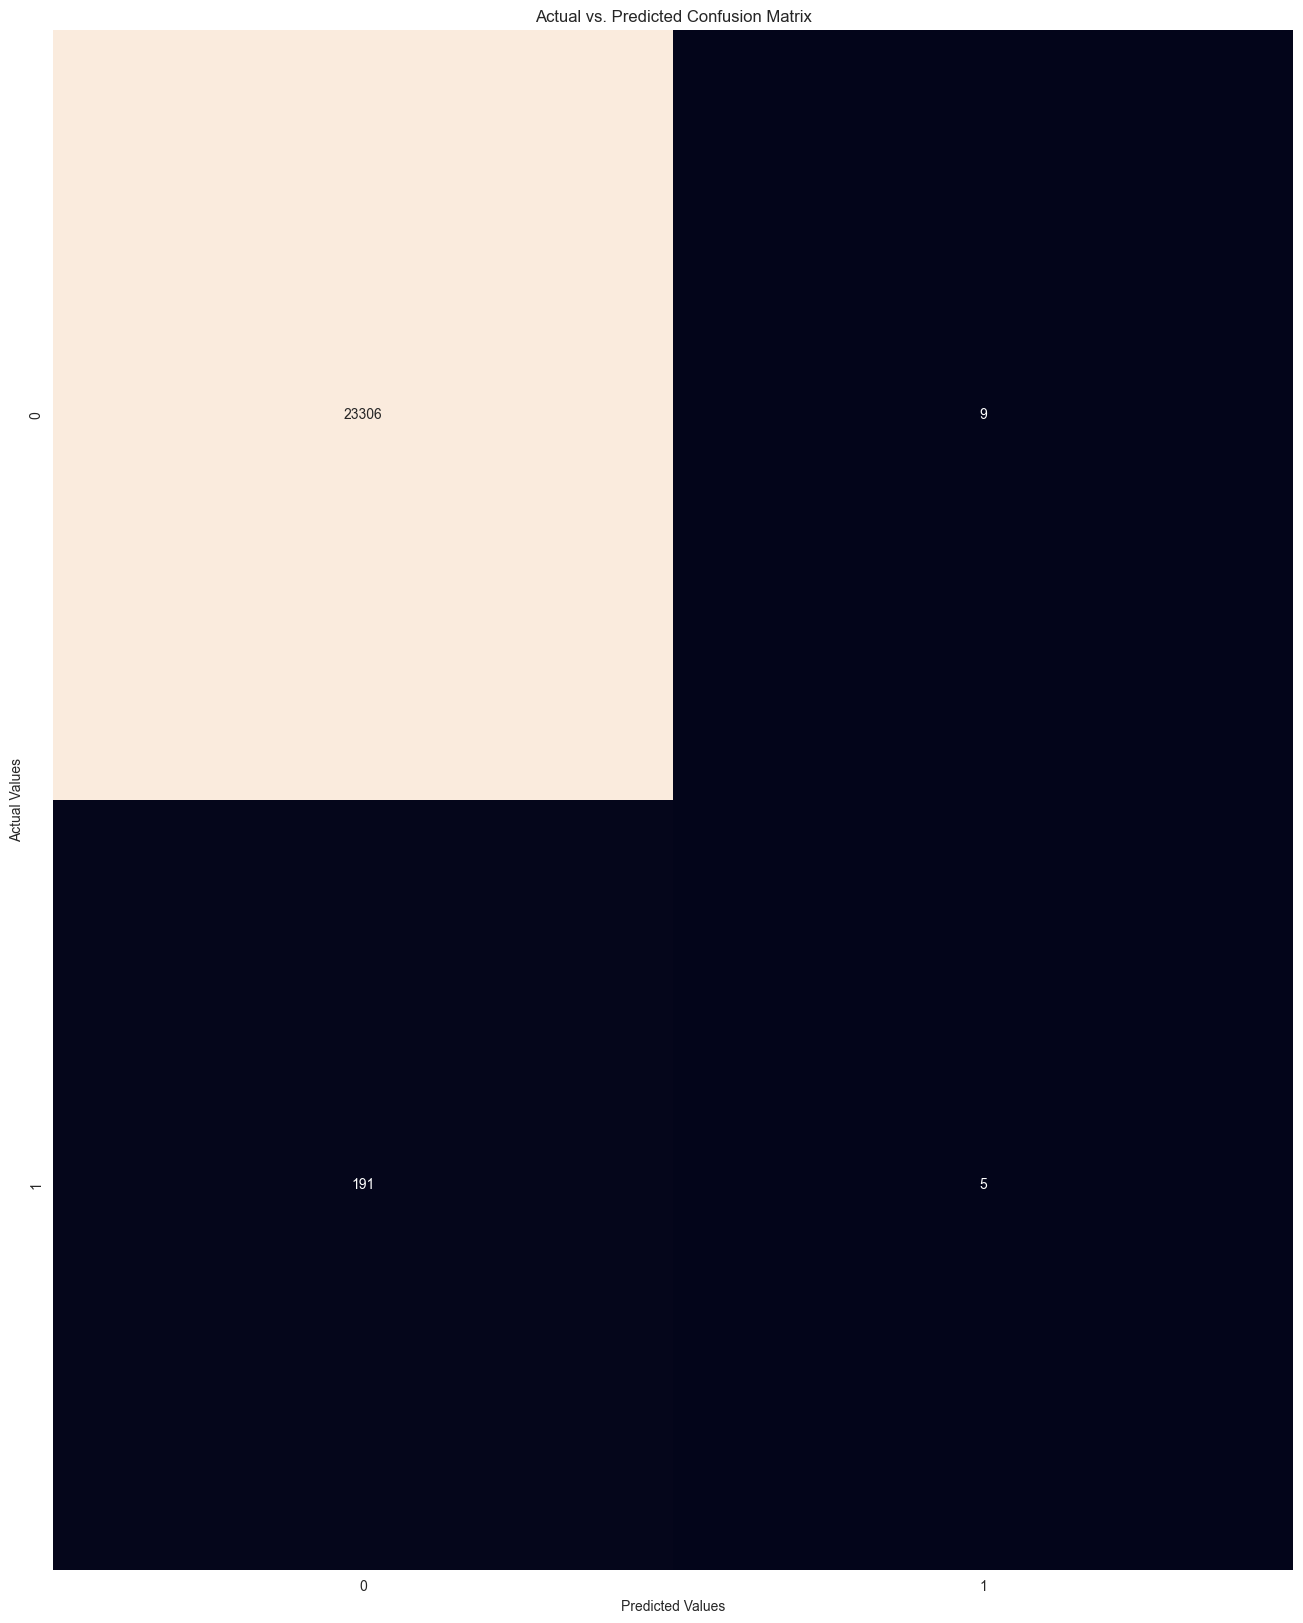

In [1633]:
conf_mat = create_conf_mat(y_test,y_pred_dt)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1634]:
#Get predicted probabilites
target_probailities_log = dt.predict_proba(x_test)[:,1]

In [1635]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

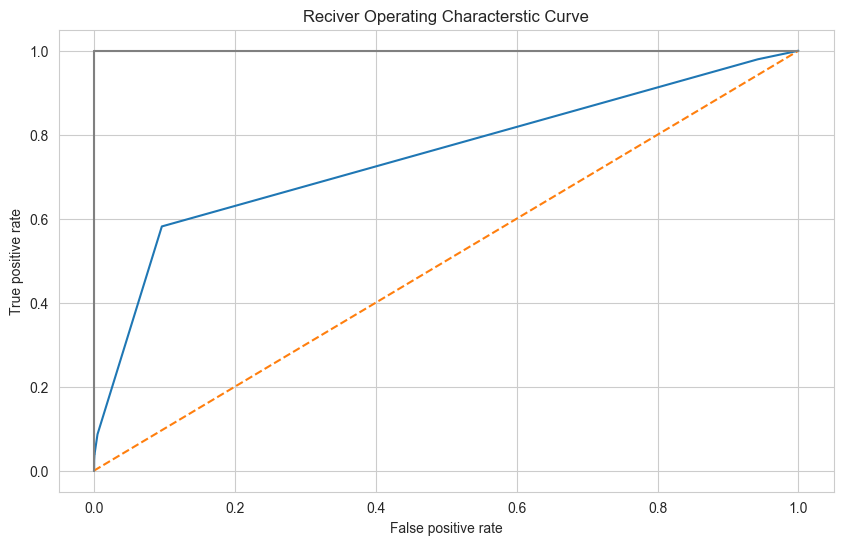

In [1636]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()


In [1637]:
Model,ROC_AUC_Accuracy_RFE

(['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
 [0.502422347879748, 0.5868145671307339, 0.5125620932481935])

# Random Forest

In [1638]:
params = {
    
    'n_estimators':range(10,100,10),
    'criterion':['gini','entropy'],
    'max_depth':range(2,10,1),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

rf = RandomForestClassifier()

rs = RandomizedSearchCV(estimator=rf,param_distributions=params,cv=3,scoring='recall',n_jobs=-1)
rs.fit(x,y)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(2, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'n_estimators': range(10, 100, 10)},
                   scoring='recall')

In [1639]:
rf = RandomForestClassifier(**rs.best_params_)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(roc_auc_score(y_test,y_pred_rf))
Model.append('Random Forest')
ROC_AUC_Accuracy_RFE.append(roc_auc_score(y_test,y_pred_rf))

0.5


In [1640]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1641]:
results=confusion_matrix(y_test,y_pred_rf)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_rf) )
print ('Report : ')
print (classification_report(y_test,y_pred_rf) )


Confusion Matrix :
[[23315     0]
 [  196     0]]
Accuracy Score : 0.9916634766704947
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1642]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_rf ):
    cm = metrics.confusion_matrix( y_test,y_pred_rf )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1643]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_rf )
print("confusion matrix = \n",mat_pruned)


confusion matrix = 
 [[23315     0]
 [  196     0]]


In [1644]:
def create_conf_mat(y_test,y_pred_rf):
    if (len(y_test.shape) != len(y_pred_rf.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_rf.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_rf)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

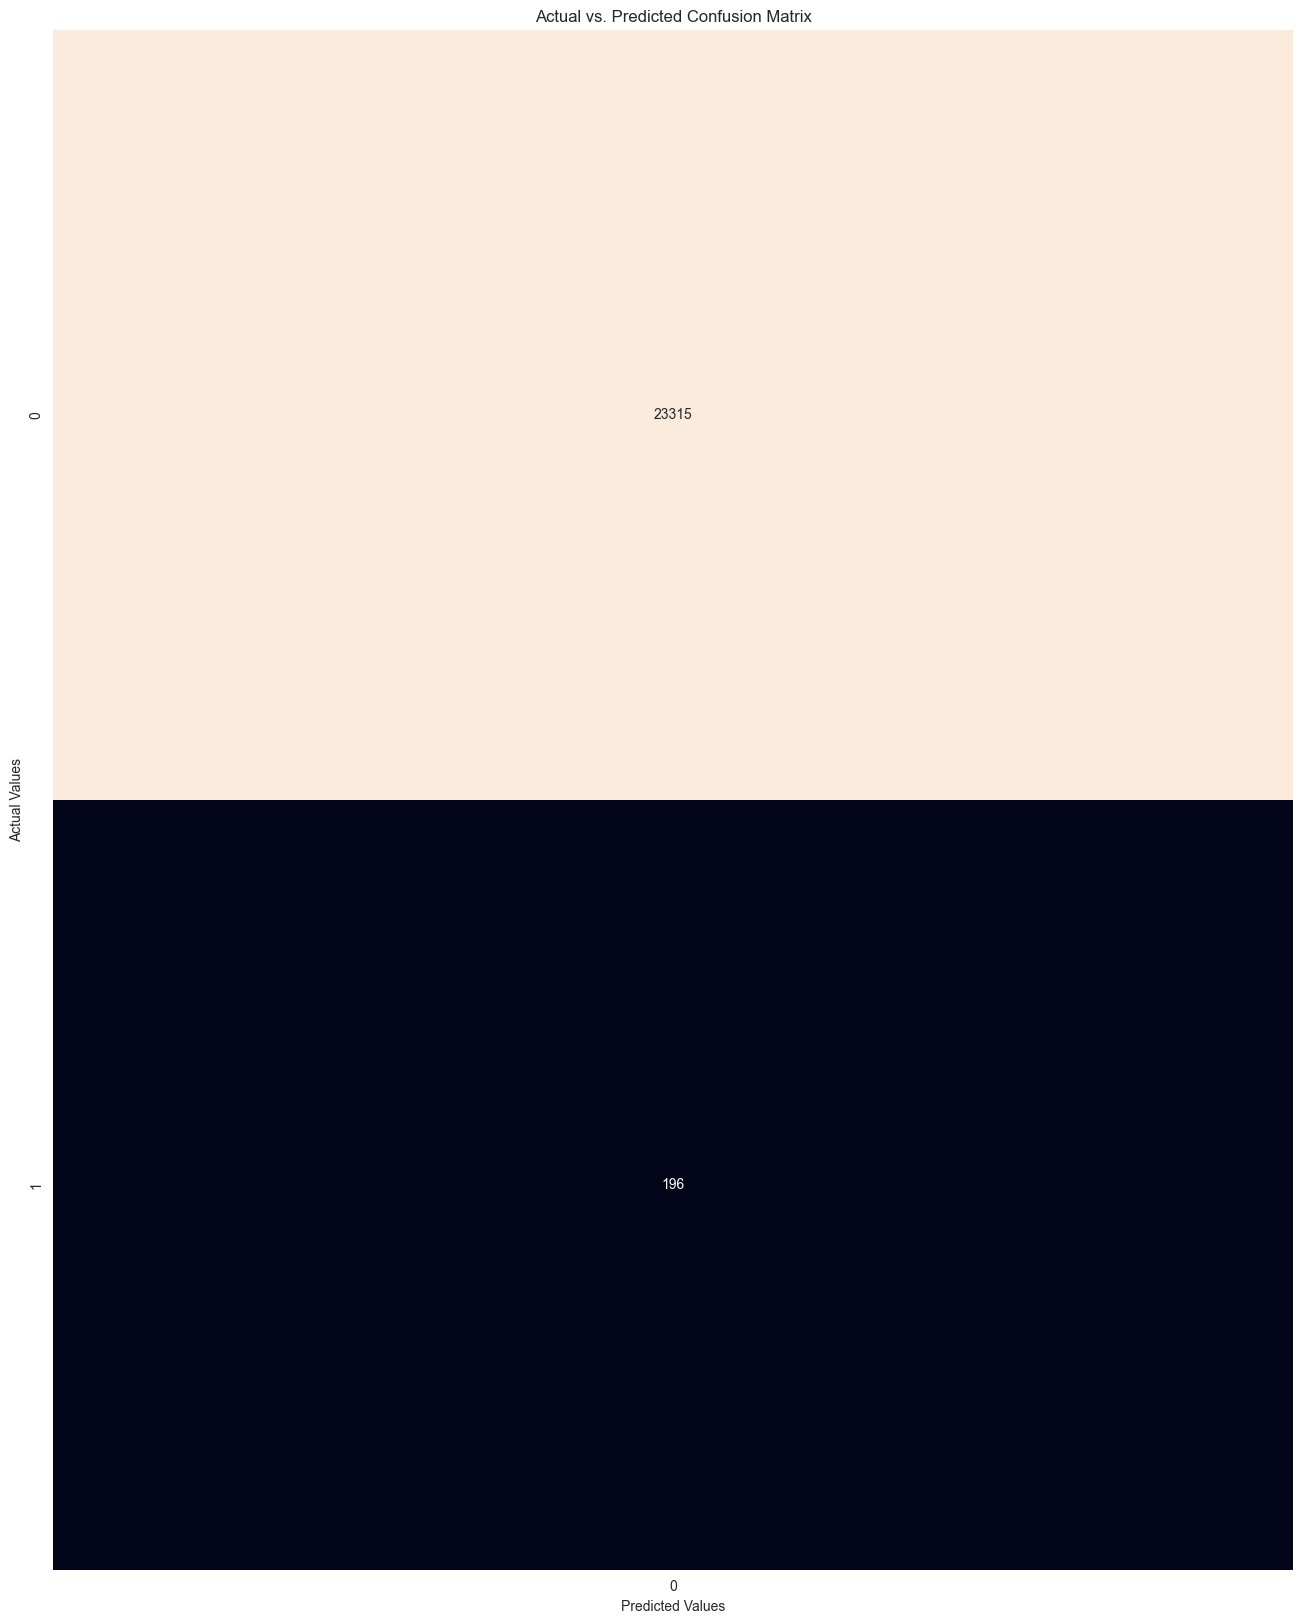

In [1645]:
conf_mat = create_conf_mat(y_test,y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1646]:
#Get predicted probabilites
target_probailities_log = rf.predict_proba(x_test)[:,1]

In [1647]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)


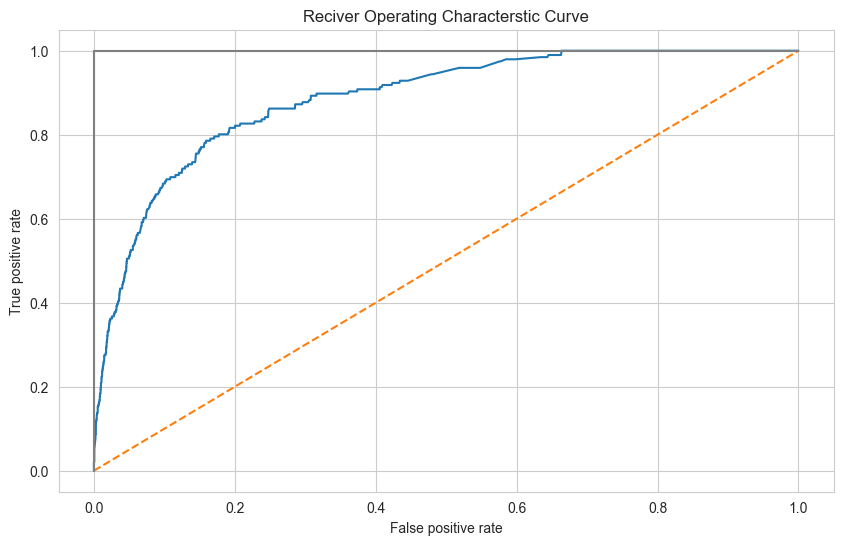

In [1648]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1649]:
Model,ROC_AUC_Accuracy_RFE

(['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
 [0.502422347879748, 0.5868145671307339, 0.5125620932481935, 0.5])

In [1650]:
final_result = pd.DataFrame({'Model':Model,'Accuracy':ROC_AUC_Accuracy_RFE})
final_result

,Model,Accuracy
0,Logistic Regression,0.502422
1,Naive Bayes,0.586815
2,Decision Tree,0.512562
3,Random Forest,0.500000


In [1651]:
len(ROC_AUC_Accuracy_RFE)

4

In [1652]:
final_result = pd.DataFrame({'Model - RFE Data':Model,'Accuracy':ROC_AUC_Accuracy_RFE})
final_result

,Model - RFE Data,Accuracy
0,Logistic Regression,0.502422
1,Naive Bayes,0.586815
2,Decision Tree,0.512562
3,Random Forest,0.500000


# VIF

In [1653]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
[variance_inflation_factor(X.values, j) for j in range(1, X.shape[1])]

[4.072977408416887,
 2.2777592986055546,
 3.0664861809437918,
 12.12848795713522,
 inf,
 inf,
 101.97063421325727,
 62.897562223825275,
 3.7575280024713886,
 inf,
 inf,
 466.82044567716554,
 1238.6720445201036,
 23.815352752283374,
 4.292680088944404,
 1393.139228059251,
 inf,
 inf,
 1.8912317556176852,
 65.46441411162117,
 10.086637991085297,
 11.850552406874884,
 1.1376591756517582,
 284.2514270663596,
 42.161491655480575,
 10.582370849152763,
 5.360967584334791,
 13.292161586450598,
 4.335086482365523,
 4.579390826507437,
 35.97953937197585,
 5.623737495934658,
 48.312038191987746,
 5.5327421198474465,
 97.3843288704673,
 21.52865218187338,
 170.60109413414344,
 61.965828788047546,
 6.667942624334332,
 130.233797304354]

In [1654]:
# function definition

def calculate_vif(X):
    thresh = 5.0
    output = pd.DataFrame()
    k = X.shape[1]
    vif = [variance_inflation_factor(X.values, j) for j in range(X.shape[1])]
    for i in range(1,k):
        print("Iteration no.",i)
        print(vif)
        a = np.argmax(vif)
        print("Max VIF is for variable no.:",a)
        if vif[a] <= thresh :
            break
        if i == 1 :          
            output = X.drop(X.columns[a], axis = 1)
            vif = [variance_inflation_factor(output.values, j) for j in range(output.shape[1])]
        elif i > 1 :
            output = output.drop(output.columns[a],axis = 1)
            vif = [variance_inflation_factor(output.values, j) for j in range(output.shape[1])]
    return(output)

In [1655]:
train_out = calculate_vif(X)

Iteration no. 1
[7.821118355371877, 4.072977408416887, 2.2777592986055546, 3.0664861809437918, 12.12848795713522, inf, inf, 101.97063421325727, 62.897562223825275, 3.7575280024713886, inf, inf, 466.82044567716554, 1238.6720445201036, 23.815352752283374, 4.292680088944404, 1393.139228059251, inf, inf, 1.8912317556176852, 65.46441411162117, 10.086637991085297, 11.850552406874884, 1.1376591756517582, 284.2514270663596, 42.161491655480575, 10.582370849152763, 5.360967584334791, 13.292161586450598, 4.335086482365523, 4.579390826507437, 35.97953937197585, 5.623737495934658, 48.312038191987746, 5.5327421198474465, 97.3843288704673, 21.52865218187338, 170.60109413414344, 61.965828788047546, 6.667942624334332, 130.233797304354]
Max VIF is for variable no.: 5
Iteration no. 2
[7.821118355371877, 4.072977408416887, 2.2777592986055533, 3.0664861809437918, 12.12848795713522, inf, 101.97063421325842, 62.89756222382352, 3.7575280024713855, 96291.53611089542, inf, 466.82044567716554, 1238.6720445201036

In [1656]:
## includes only the relevant features.
train_out.head()

,customer_id,brand,brand_type,item_counts,no_of_customers,od_sum,other_discount_x,selling_price_x,campaign_type,marital_status,rented,no_of_children,coupon_discount_y,coupon_used_y,day,dow,month,quantity_y,pprice_sum
0,1053,1105,0,125,19.224000,-177447.090167,-44.367382,117.276864,0,1.0,0.0,0.0,-0.287258,1,11,2,5,340.487097,50829.715972
1,48,56,1,3,20.333333,-586.140000,-10.207037,70.885046,0,0.0,0.0,0.0,-3.215039,12,4,5,6,31.540260,72625.812434
2,205,560,0,67,1.761194,-12475.083333,-76.767366,342.826195,1,0.0,0.0,0.0,-2.212082,85,27,2,3,1.392784,108705.636349
3,1050,611,0,4,3.500000,-260.750000,-4.451964,88.694903,0,0.0,0.0,0.0,-0.751477,2,9,4,8,1.291139,23912.588333
4,1489,1558,0,32,27.312500,-46796.046667,-30.665116,200.991719,0,0.0,0.0,0.0,-0.471548,10,2,4,5,247.443060,47779.189609


In [1657]:
train_out.columns

Index(['customer_id', 'brand', 'brand_type', 'item_counts', 'no_of_customers',
       'od_sum', 'other_discount_x', 'selling_price_x', 'campaign_type',
       'marital_status', 'rented', 'no_of_children', 'coupon_discount_y',
       'coupon_used_y', 'day', 'dow', 'month', 'quantity_y', 'pprice_sum'],
      dtype='object')

In [1658]:
train_out.shape

(78369, 19)

In [1659]:
x_train,x_test,y_train,y_test = train_test_split(train_out,y,test_size=0.3,random_state=42, shuffle=True)

In [1660]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((54858, 19), (54858,), (23511, 19), (23511,))

In [1661]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
y_pred_LR = LR.predict(x_test)
print(classification_report(y_test,y_pred_LR))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1662]:
roc_auc_score(y_test,y_pred_LR)
Model = ['Logistic Regression']
ROC_AUC_Accuracy_VIF= [roc_auc_score(y_test,y_pred_LR)]

In [1663]:
results=confusion_matrix(y_test,y_pred_LR)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_LR) )
print ('Report : ')
print (classification_report(y_test,y_pred_LR) )

Confusion Matrix :
[[23315     0]
 [  196     0]]
Accuracy Score : 0.9916634766704947
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1664]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_LR ):
    cm = metrics.confusion_matrix( y_test,y_pred_LR )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1665]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_LR )

print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23315     0]
 [  196     0]]


In [1666]:
def create_conf_mat(y_test,y_pred_LR):
    if (len(y_test.shape) != len(y_pred_LR.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_LR.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_LR)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

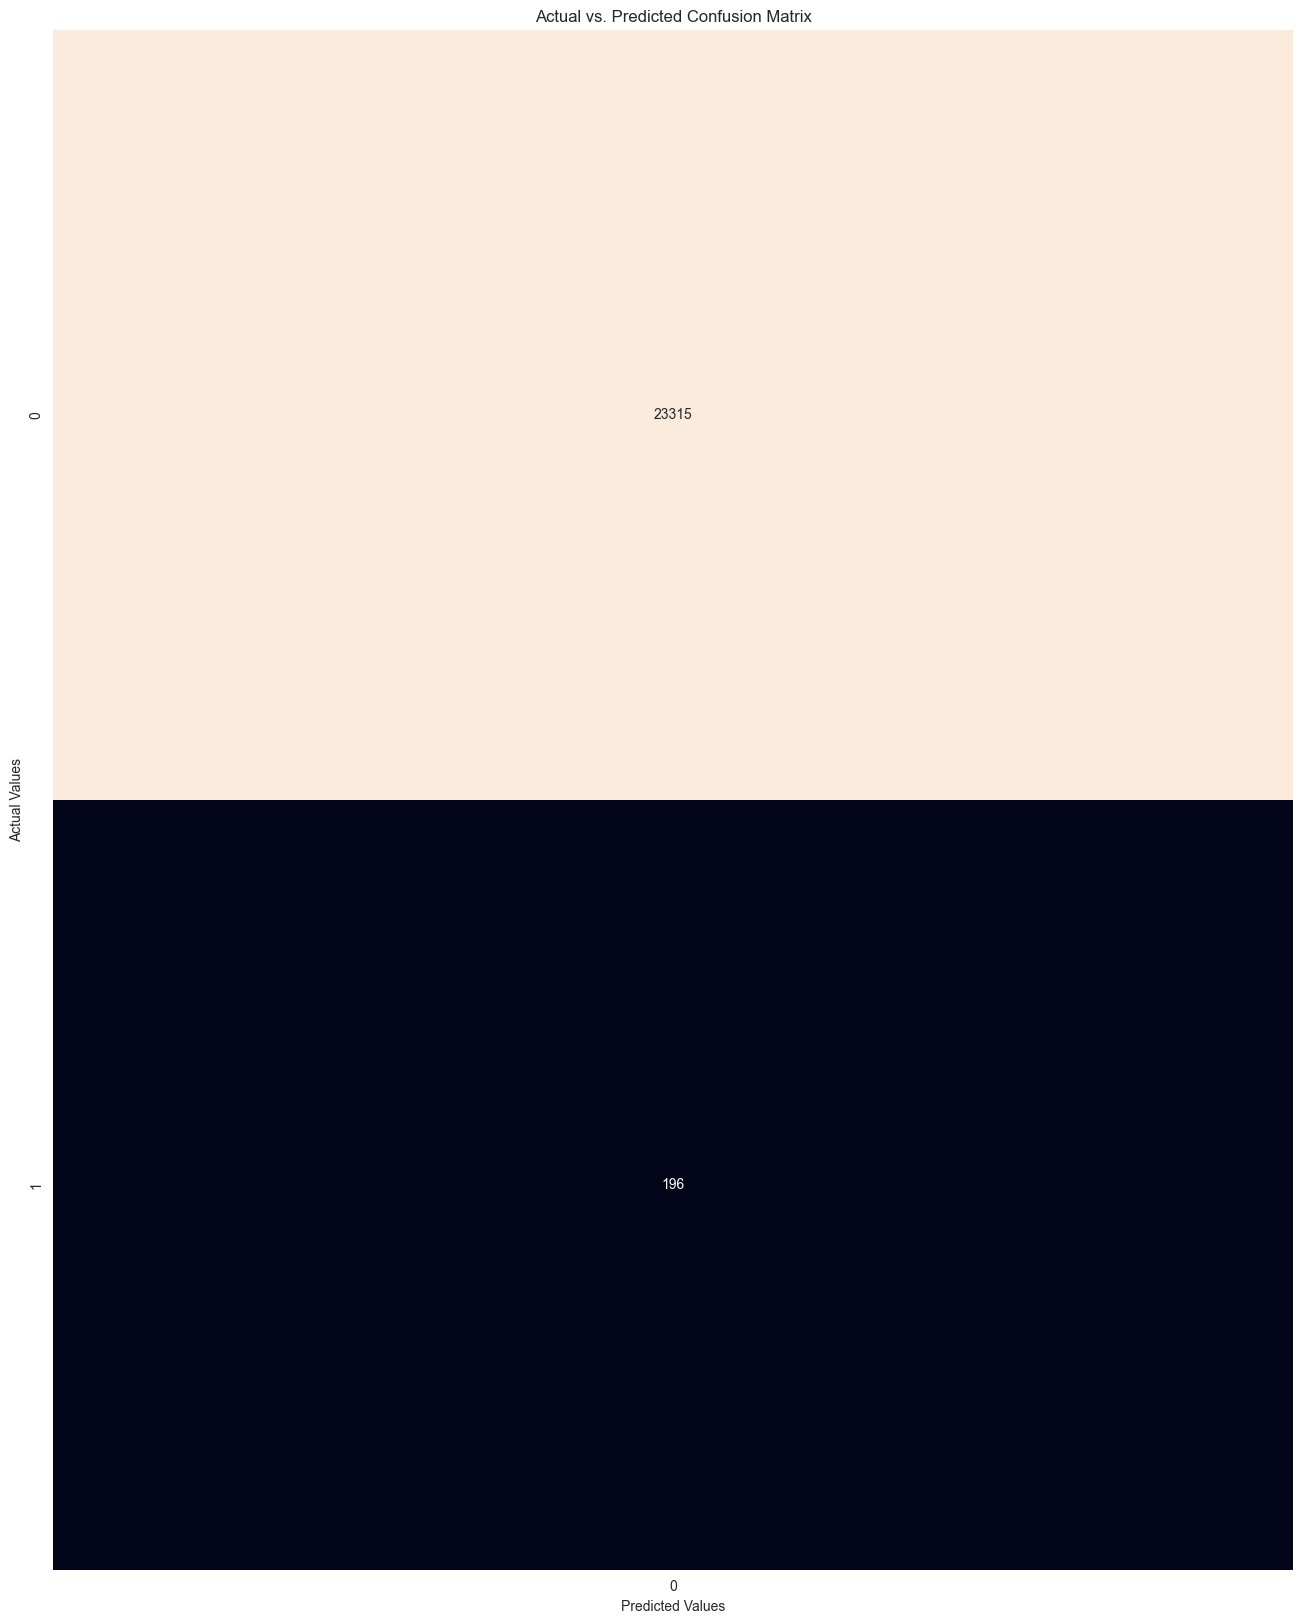

In [1667]:
    conf_mat = create_conf_mat(y_test,y_pred_LR)
    sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Actual vs. Predicted Confusion Matrix')
    plt.show()

In [1668]:
#Get predicted probabilites
target_probailities_log = LR.predict_proba(x_test)[:,1]

In [1669]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

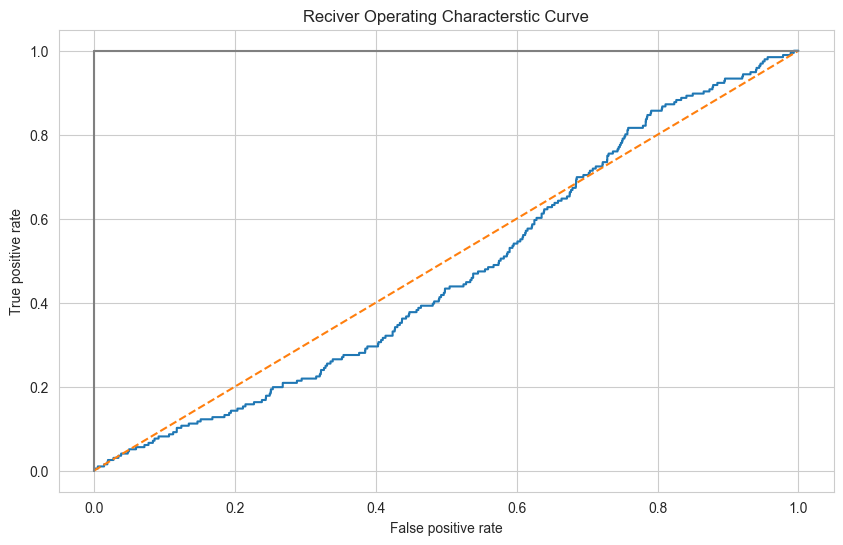

In [1670]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

# Naive Bayes

In [1671]:
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
print(roc_auc_score(y_test,y_pred_nb))
Model.append('Naive Bayes')
ROC_AUC_Accuracy_VIF.append(roc_auc_score(y_test,y_pred_nb))

0.5881441832576908


In [1672]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.06      0.20      0.09       196

    accuracy                           0.97     23511
   macro avg       0.53      0.59      0.54     23511
weighted avg       0.99      0.97      0.98     23511



In [1673]:
results=confusion_matrix(y_test,y_pred_nb)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_nb) )
print ('Report : ')
print (classification_report(y_test,y_pred_nb) )

Confusion Matrix :
[[22667   648]
 [  156    40]]
Accuracy Score : 0.9658032410361107
Report : 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.06      0.20      0.09       196

    accuracy                           0.97     23511
   macro avg       0.53      0.59      0.54     23511
weighted avg       0.99      0.97      0.98     23511



In [1674]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_nb ):
    cm = metrics.confusion_matrix( y_test,y_pred_nb )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1675]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_nb )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[22667   648]
 [  156    40]]


In [1676]:
def create_conf_mat(y_test,y_pred_nb):
    if (len(y_test.shape) != len(y_pred_nb.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_nb.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_nb)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

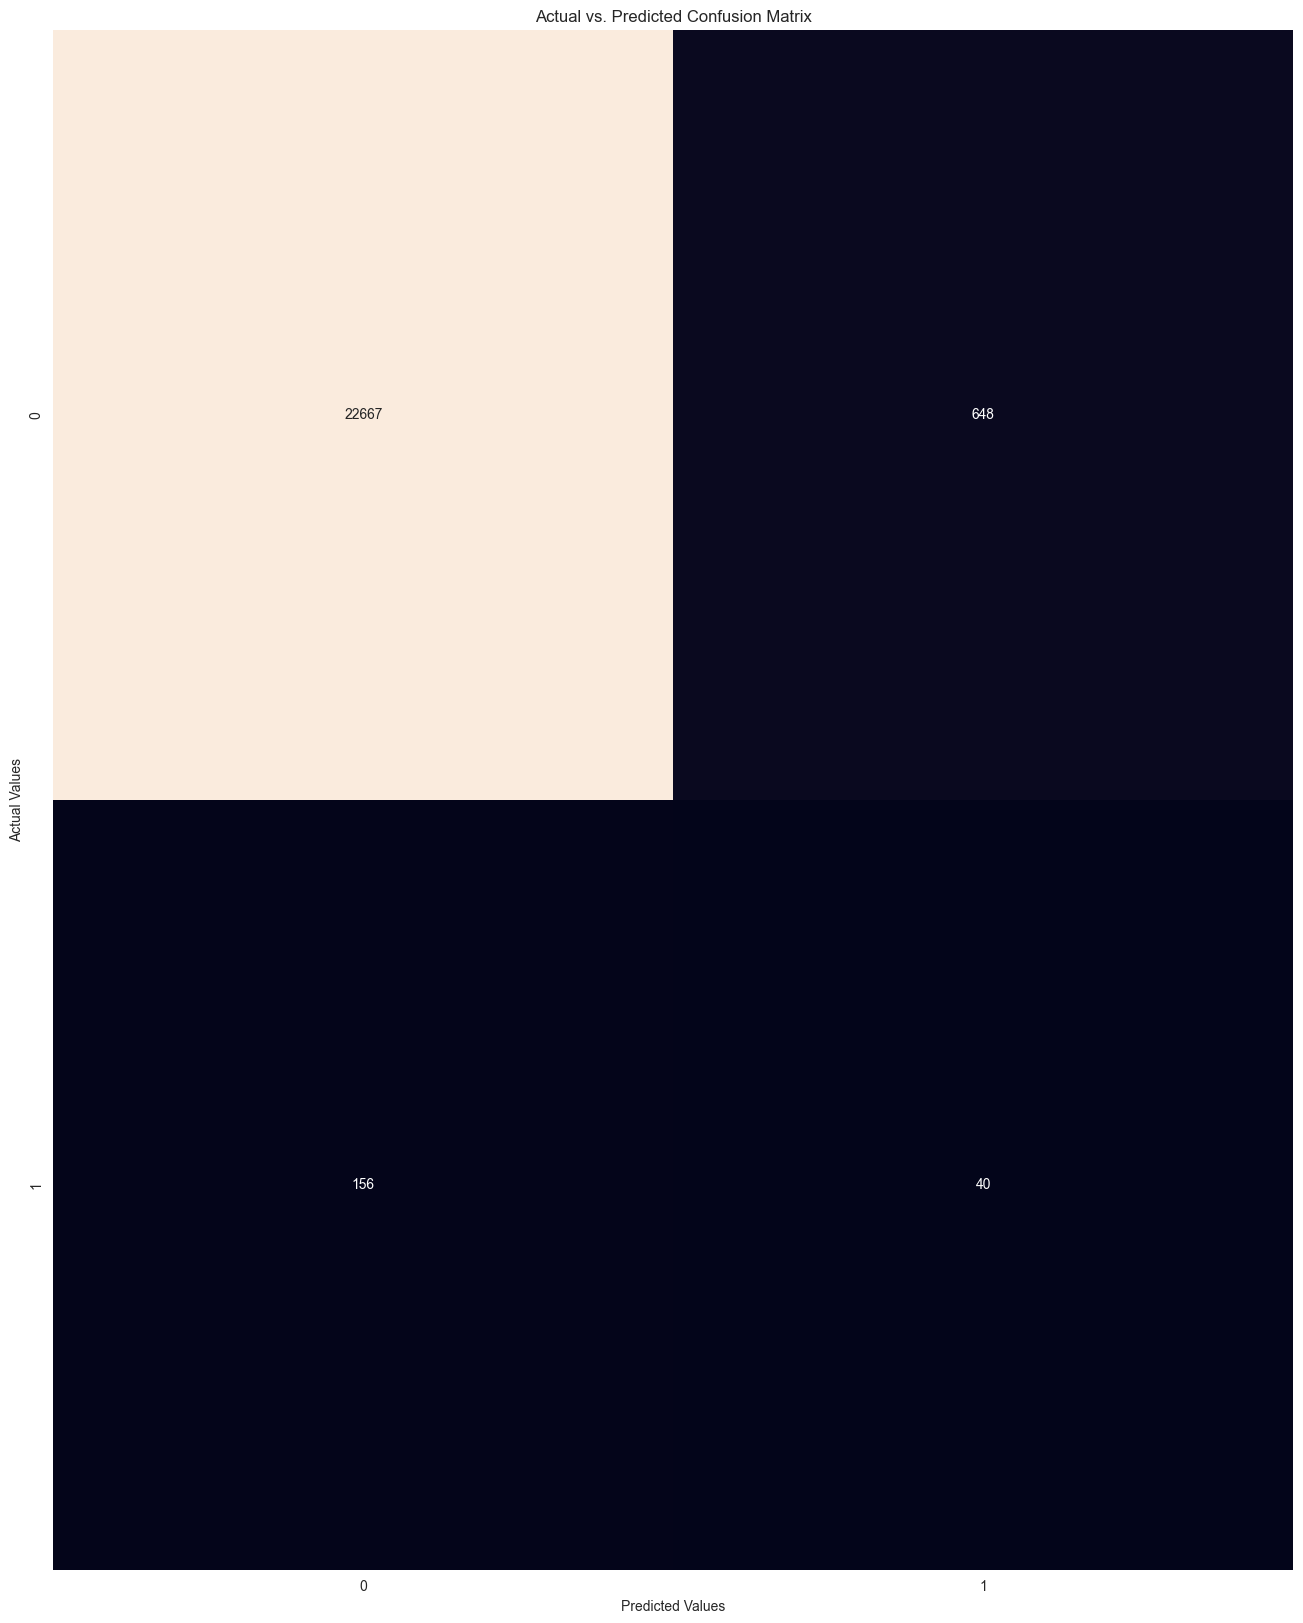

In [1677]:
conf_mat = create_conf_mat(y_test,y_pred_nb)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1678]:
#Get predicted probabilites
target_probailities_log = nb.predict_proba(x_test)[:,1]

In [1679]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

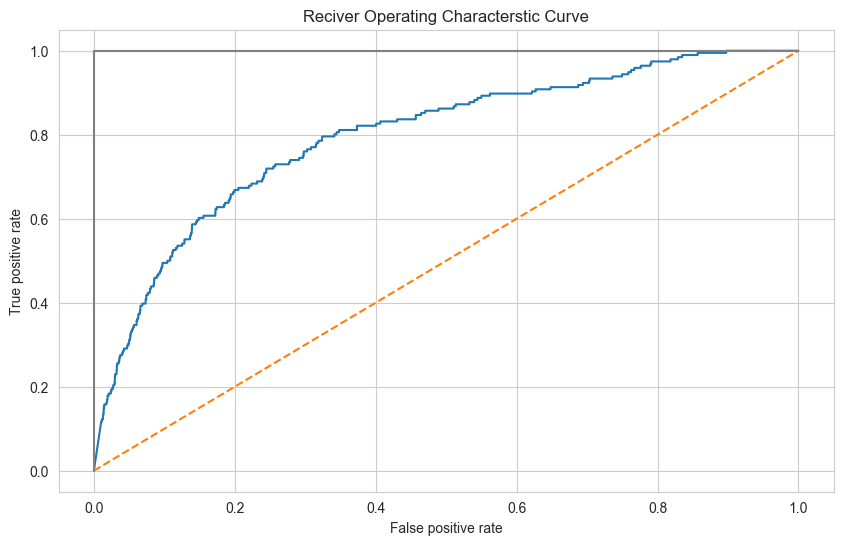

In [1680]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()


In [1681]:
Model,ROC_AUC_Accuracy_VIF

(['Logistic Regression', 'Naive Bayes'], [0.5, 0.5881441832576908])

# Decision Tree

In [1682]:
params = {
    
    'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':range(1,10),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

dt = DecisionTreeClassifier()

gs = GridSearchCV(estimator=dt,n_jobs=-1,cv=3,param_grid=params,scoring='recall')
gs.fit(train_out,y)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 10),
                         'max_features': ['auto', 'log2'],
                         'max_leaf_nodes': range(2, 10),
                         'splitter': ['best', 'random']},
             scoring='recall')

In [1683]:
dt = DecisionTreeClassifier(**gs.best_params_)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(roc_auc_score(y_test,y_pred_dt))
Model.append('Decision Tree')
ROC_AUC_Accuracy_VIF.append(roc_auc_score(y_test,y_pred_dt))

0.4998713274715848


In [1684]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1685]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_dt):
    cm = metrics.confusion_matrix( y_test,y_pred_dt )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1686]:
results=confusion_matrix(y_test,y_pred_dt)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_dt) )
print ('Report : ')
print (classification_report(y_test,y_pred_dt) )

Confusion Matrix :
[[23309     6]
 [  196     0]]
Accuracy Score : 0.9914082769767343
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1687]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_dt )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23309     6]
 [  196     0]]


In [1688]:
def create_conf_mat(y_test,y_pred_dt):
    if (len(y_test.shape) != len(y_pred_dt.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_dt.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_dt)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

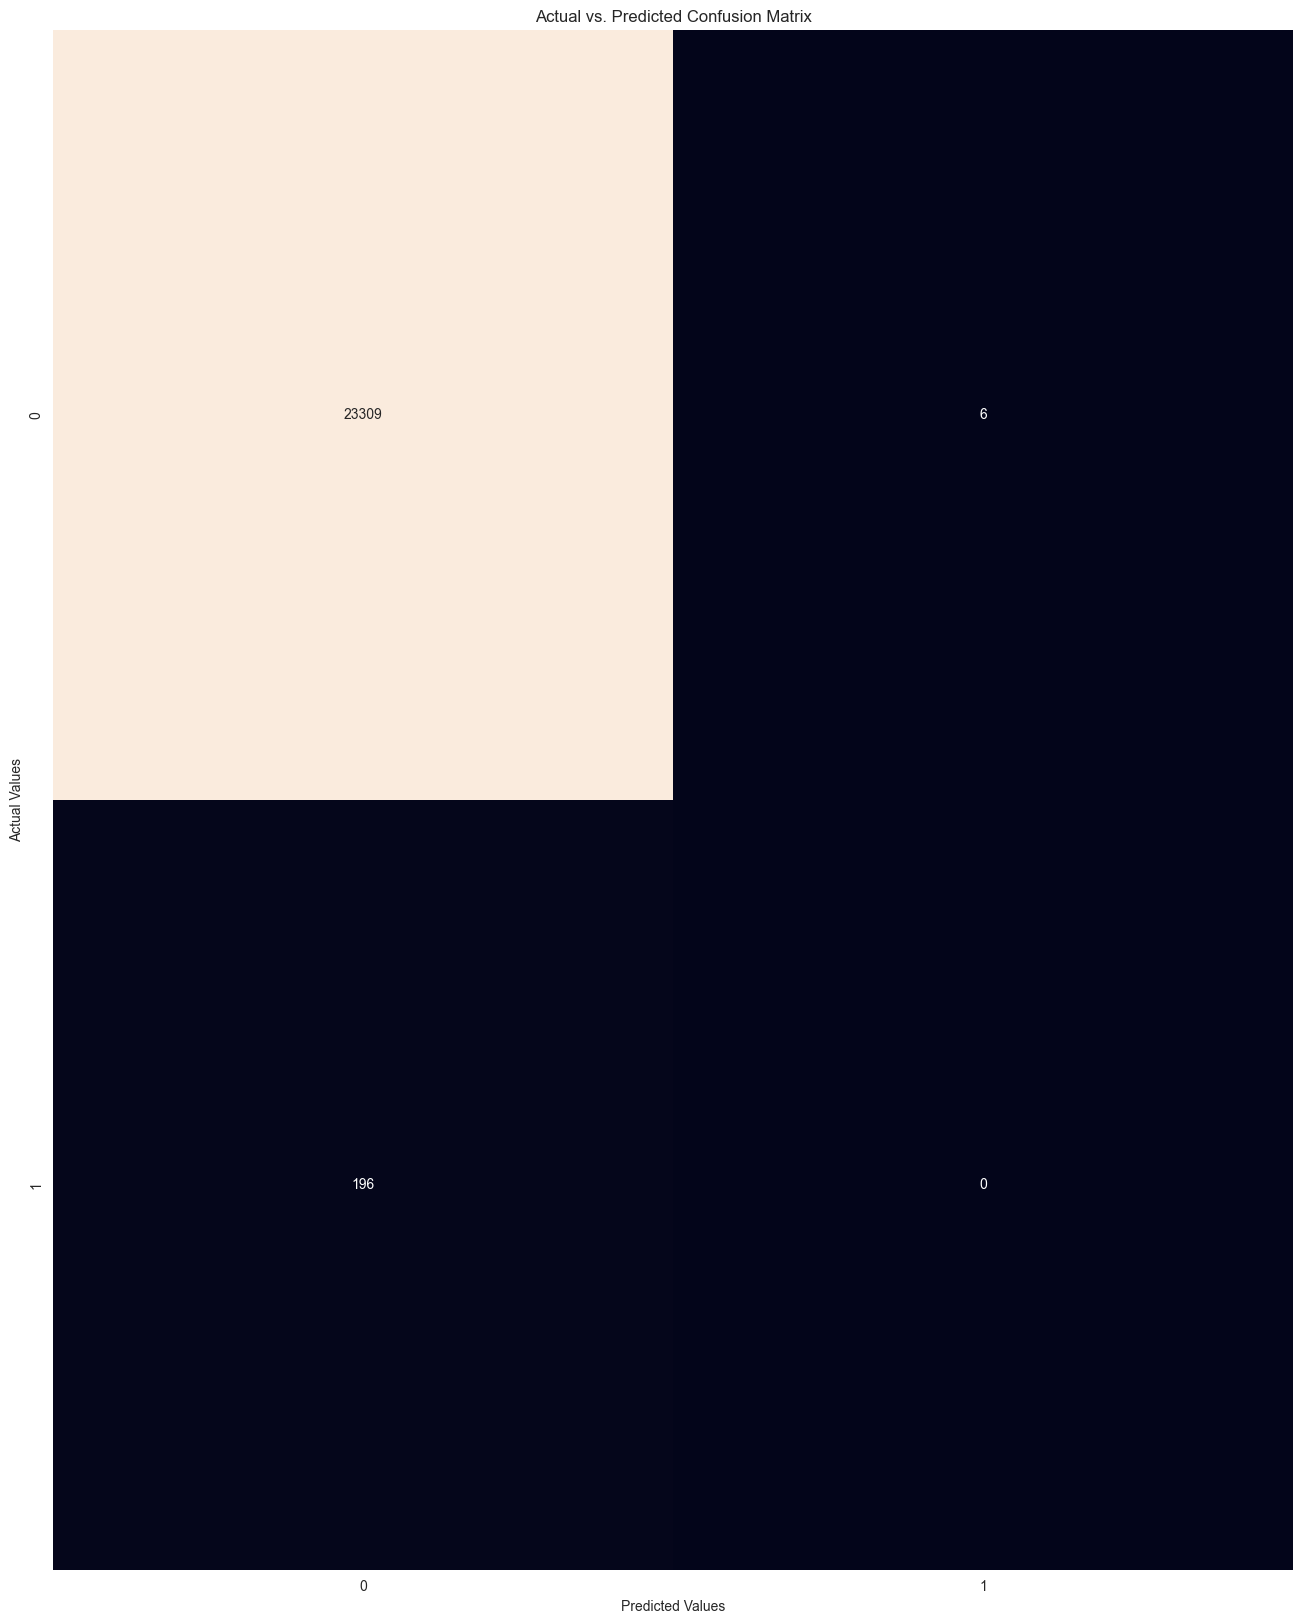

In [1689]:
conf_mat = create_conf_mat(y_test,y_pred_dt)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1690]:
#Get predicted probabilites
target_probailities_log = dt.predict_proba(x_test)[:,1]

In [1691]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

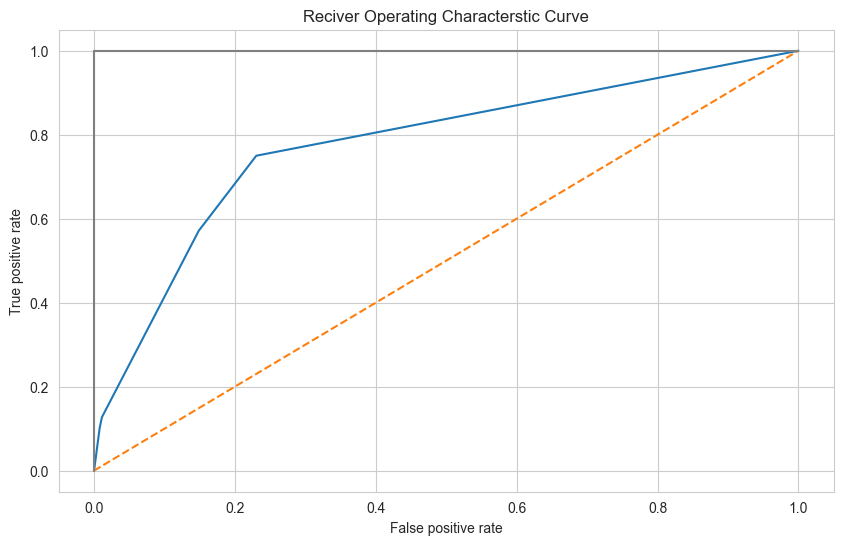

In [1692]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()


In [1693]:
Model,ROC_AUC_Accuracy_VIF

(['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
 [0.5, 0.5881441832576908, 0.4998713274715848])

# Random Forest

In [1694]:
params = {
    
    'n_estimators':range(10,100,10),
    'criterion':['gini','entropy'],
    'max_depth':range(2,10,1),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

rf = RandomForestClassifier()

rs = RandomizedSearchCV(estimator=rf,param_distributions=params,cv=3,scoring='recall',n_jobs=-1)
rs.fit(train_out,y)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(2, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'n_estimators': range(10, 100, 10)},
                   scoring='recall')

In [1695]:
rf = RandomForestClassifier(**rs.best_params_)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(roc_auc_score(y_test,y_pred_rf))
Model.append('Random Forest')
ROC_AUC_Accuracy_VIF.append(roc_auc_score(y_test,y_pred_rf))

0.5


In [1696]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1697]:
results=confusion_matrix(y_test,y_pred_rf)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_rf) )
print ('Report : ')
print (classification_report(y_test,y_pred_rf) )


Confusion Matrix :
[[23315     0]
 [  196     0]]
Accuracy Score : 0.9916634766704947
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1698]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_rf ):
    cm = metrics.confusion_matrix( y_test,y_pred_rf )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1699]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_rf )
print("confusion matrix = \n",mat_pruned)


confusion matrix = 
 [[23315     0]
 [  196     0]]


In [1700]:
def create_conf_mat(y_test,y_pred_rf):
    if (len(y_test.shape) != len(y_pred_rf.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_rf.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_rf)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

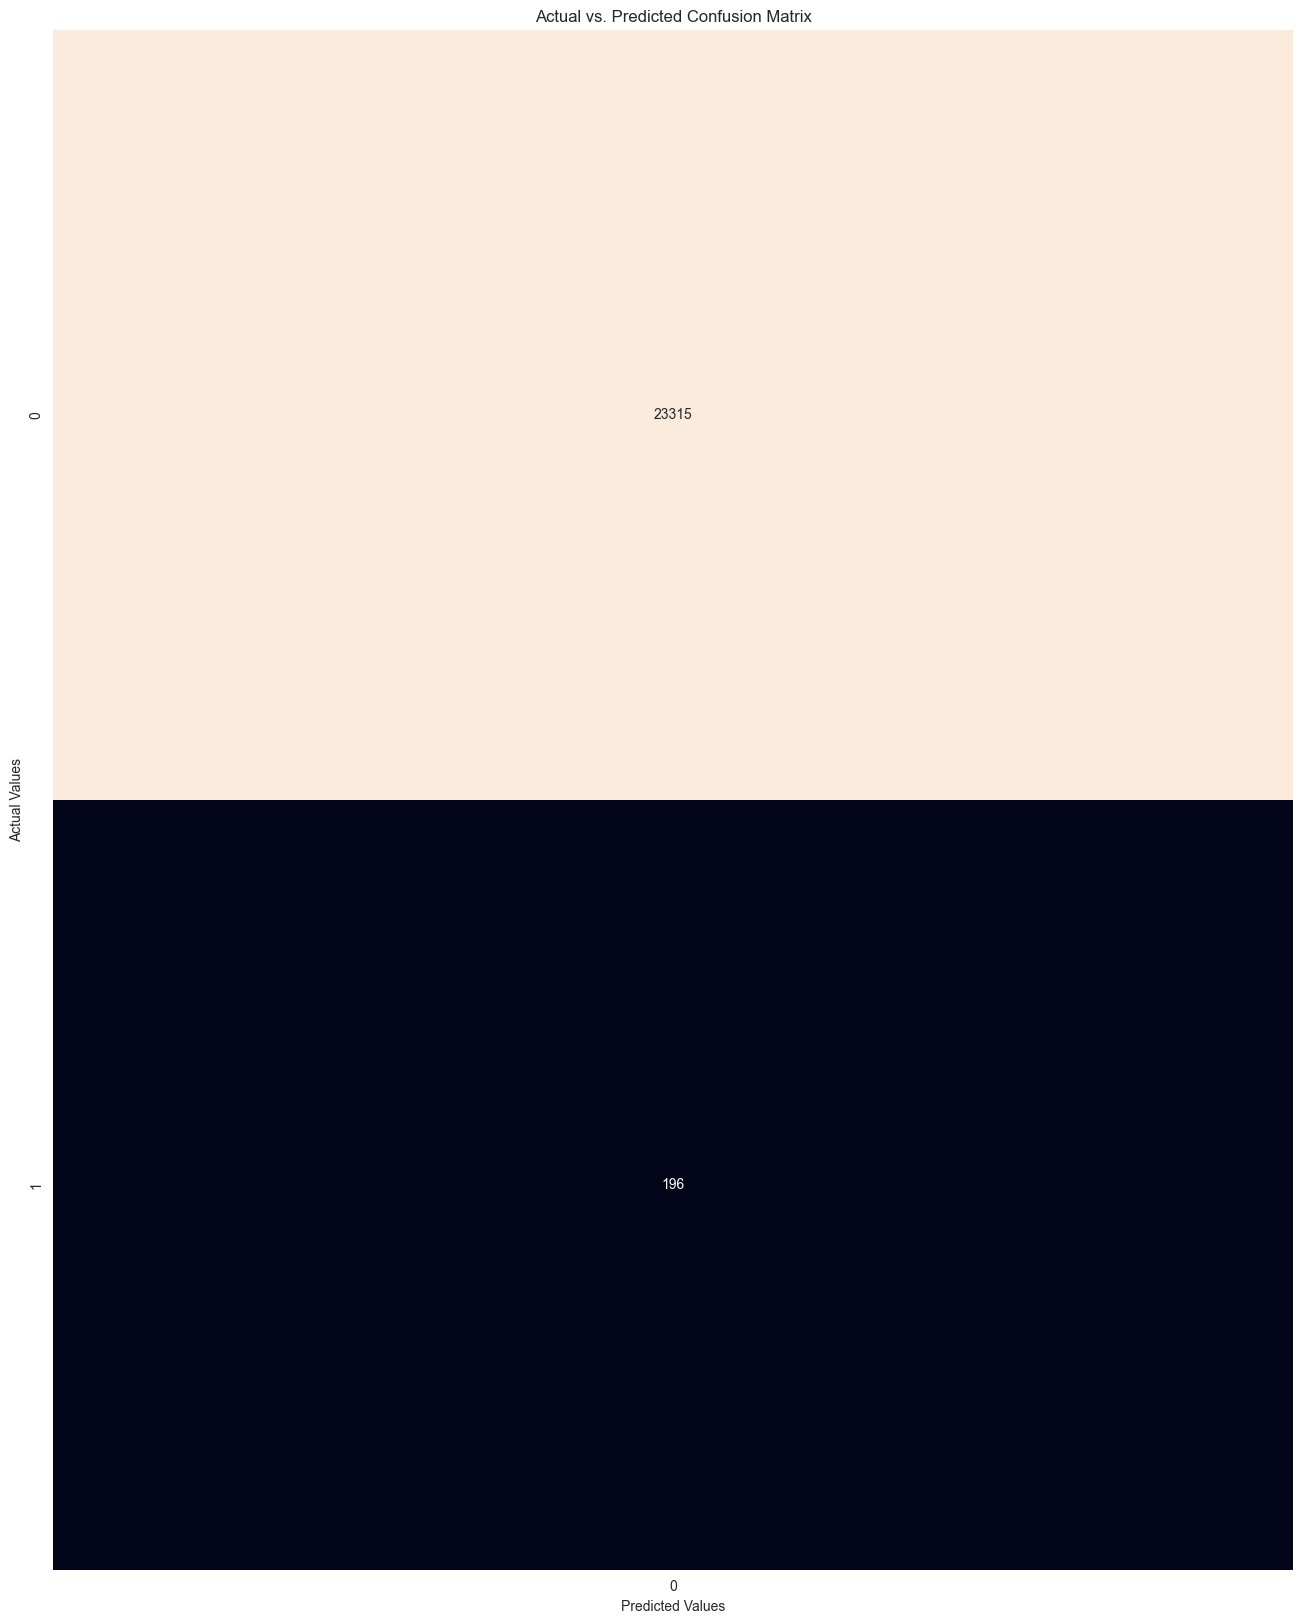

In [1701]:
conf_mat = create_conf_mat(y_test,y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1702]:
#Get predicted probabilites
target_probailities_log = rf.predict_proba(x_test)[:,1]

In [1703]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

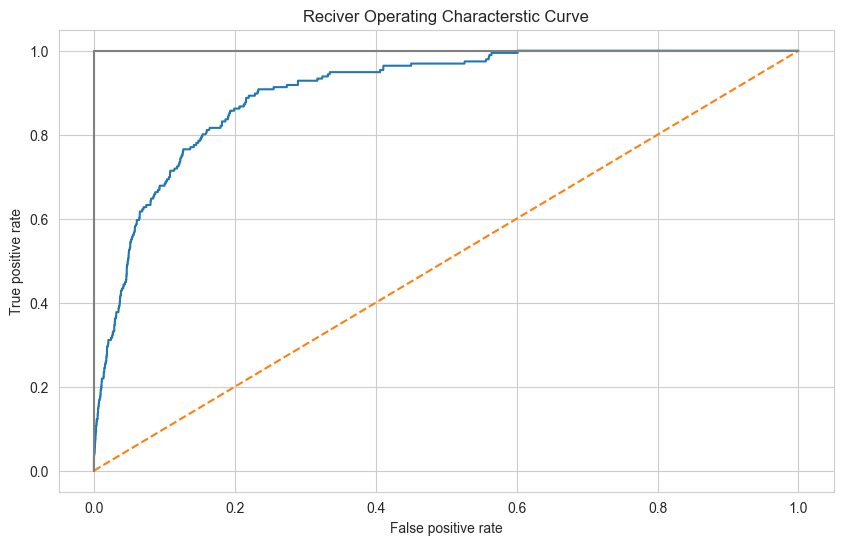

In [1704]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1705]:
Model,ROC_AUC_Accuracy_VIF

(['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
 [0.5, 0.5881441832576908, 0.4998713274715848, 0.5])

In [1706]:
final_result = pd.DataFrame({'Model - VIF Data':Model,'Accuracy':ROC_AUC_Accuracy_VIF})
final_result

,Model - VIF Data,Accuracy
0,Logistic Regression,0.500000
1,Naive Bayes,0.588144
2,Decision Tree,0.499871
3,Random Forest,0.500000


In [1707]:
final_result = pd.DataFrame({'Model - RFE Data':Model,'Accuracy':ROC_AUC_Accuracy_VIF})
final_result

,Model - RFE Data,Accuracy
0,Logistic Regression,0.500000
1,Naive Bayes,0.588144
2,Decision Tree,0.499871
3,Random Forest,0.500000


# Lasso

In [1708]:
from sklearn.linear_model import LassoCV, Lasso
reg = LassoCV()
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 9.676753
Best score using built-in LassoCV: 0.017309


In [1709]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  
      str(sum(coef == 0)) + " variables")

Lasso picked 8 variables and eliminated the other 33 variables


Text(0.5, 1.0, 'Feature importance using Lasso Model')

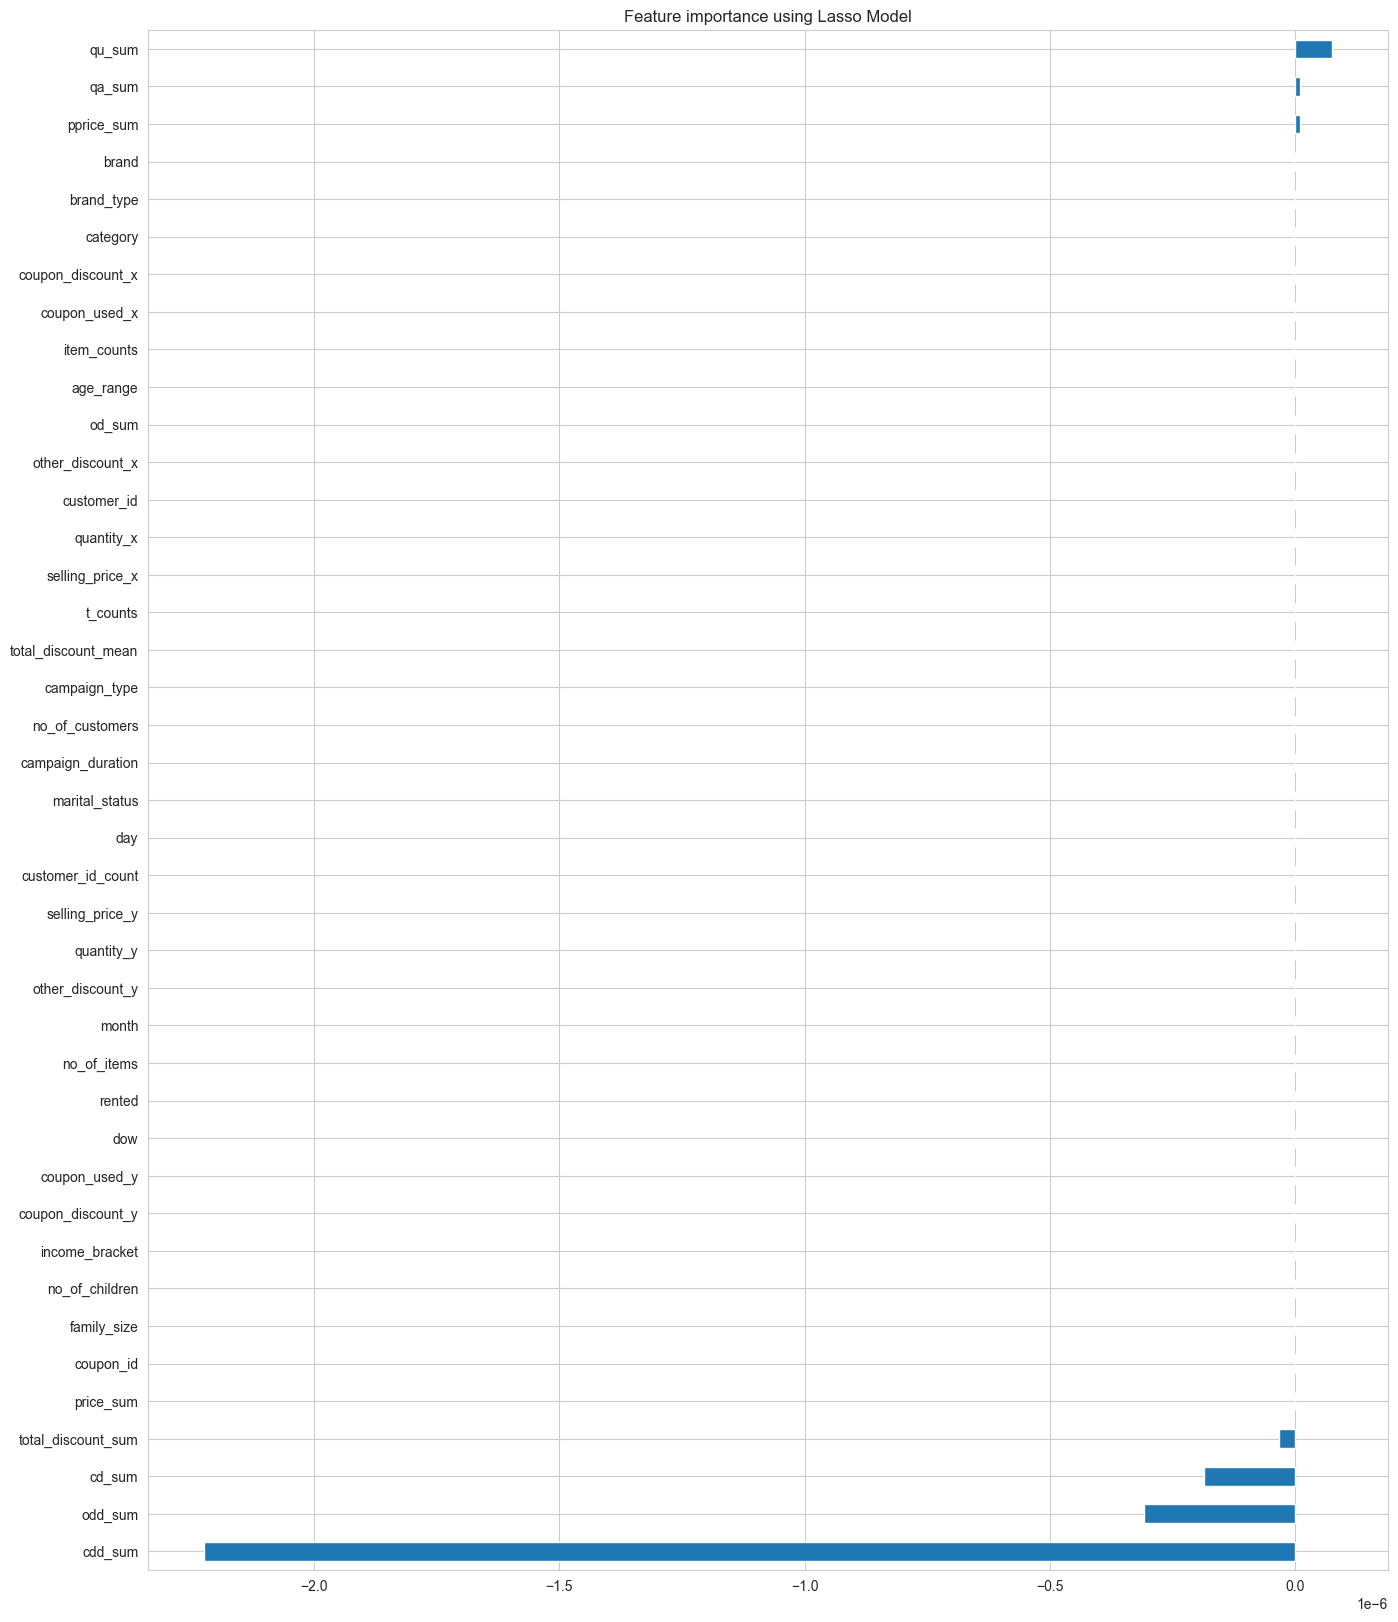

In [1710]:
imp_coef = coef.sort_values()
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16.0, 20.0)
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

We got 8 columns by performing the Lasso they are:

 [qu_sum, qa_sum, pprice_sum, price_sum, total_discount_sum, cd_sum, odd_sum, cdd_sum]

In [1711]:
col_names=['qu_sum', 'qa_sum', 'pprice_sum', 'price_sum', 'total_discount_sum', 'cd_sum', 'odd_sum', 'cdd_sum']

In [1712]:
x=df[col_names]

In [1713]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42, shuffle=True)

In [1714]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((54858, 8), (54858,), (23511, 8), (23511,))

# Logistic Regression

In [1715]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
y_pred_LR = LR.predict(x_test)
print(classification_report(y_test,y_pred_LR))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1716]:
roc_auc_score(y_test,y_pred_LR)
Model = ['Logistic Regression']
ROC_AUC_Accuracy_LASSO = [roc_auc_score(y_test,y_pred_LR)]

In [1717]:
results=confusion_matrix(y_test,y_pred_LR)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_LR) )
print ('Report : ')
print (classification_report(y_test,y_pred_LR) )

Confusion Matrix :
[[23291    24]
 [  196     0]]
Accuracy Score : 0.9906426778954532
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.00      0.00      0.00       196

    accuracy                           0.99     23511
   macro avg       0.50      0.50      0.50     23511
weighted avg       0.98      0.99      0.99     23511



In [1718]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_LR ):
    cm = metrics.confusion_matrix( y_test,y_pred_LR )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1719]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_LR )

print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23291    24]
 [  196     0]]


In [1720]:
def create_conf_mat(y_test,y_pred_LR):
    if (len(y_test.shape) != len(y_pred_LR.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_LR.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_LR)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

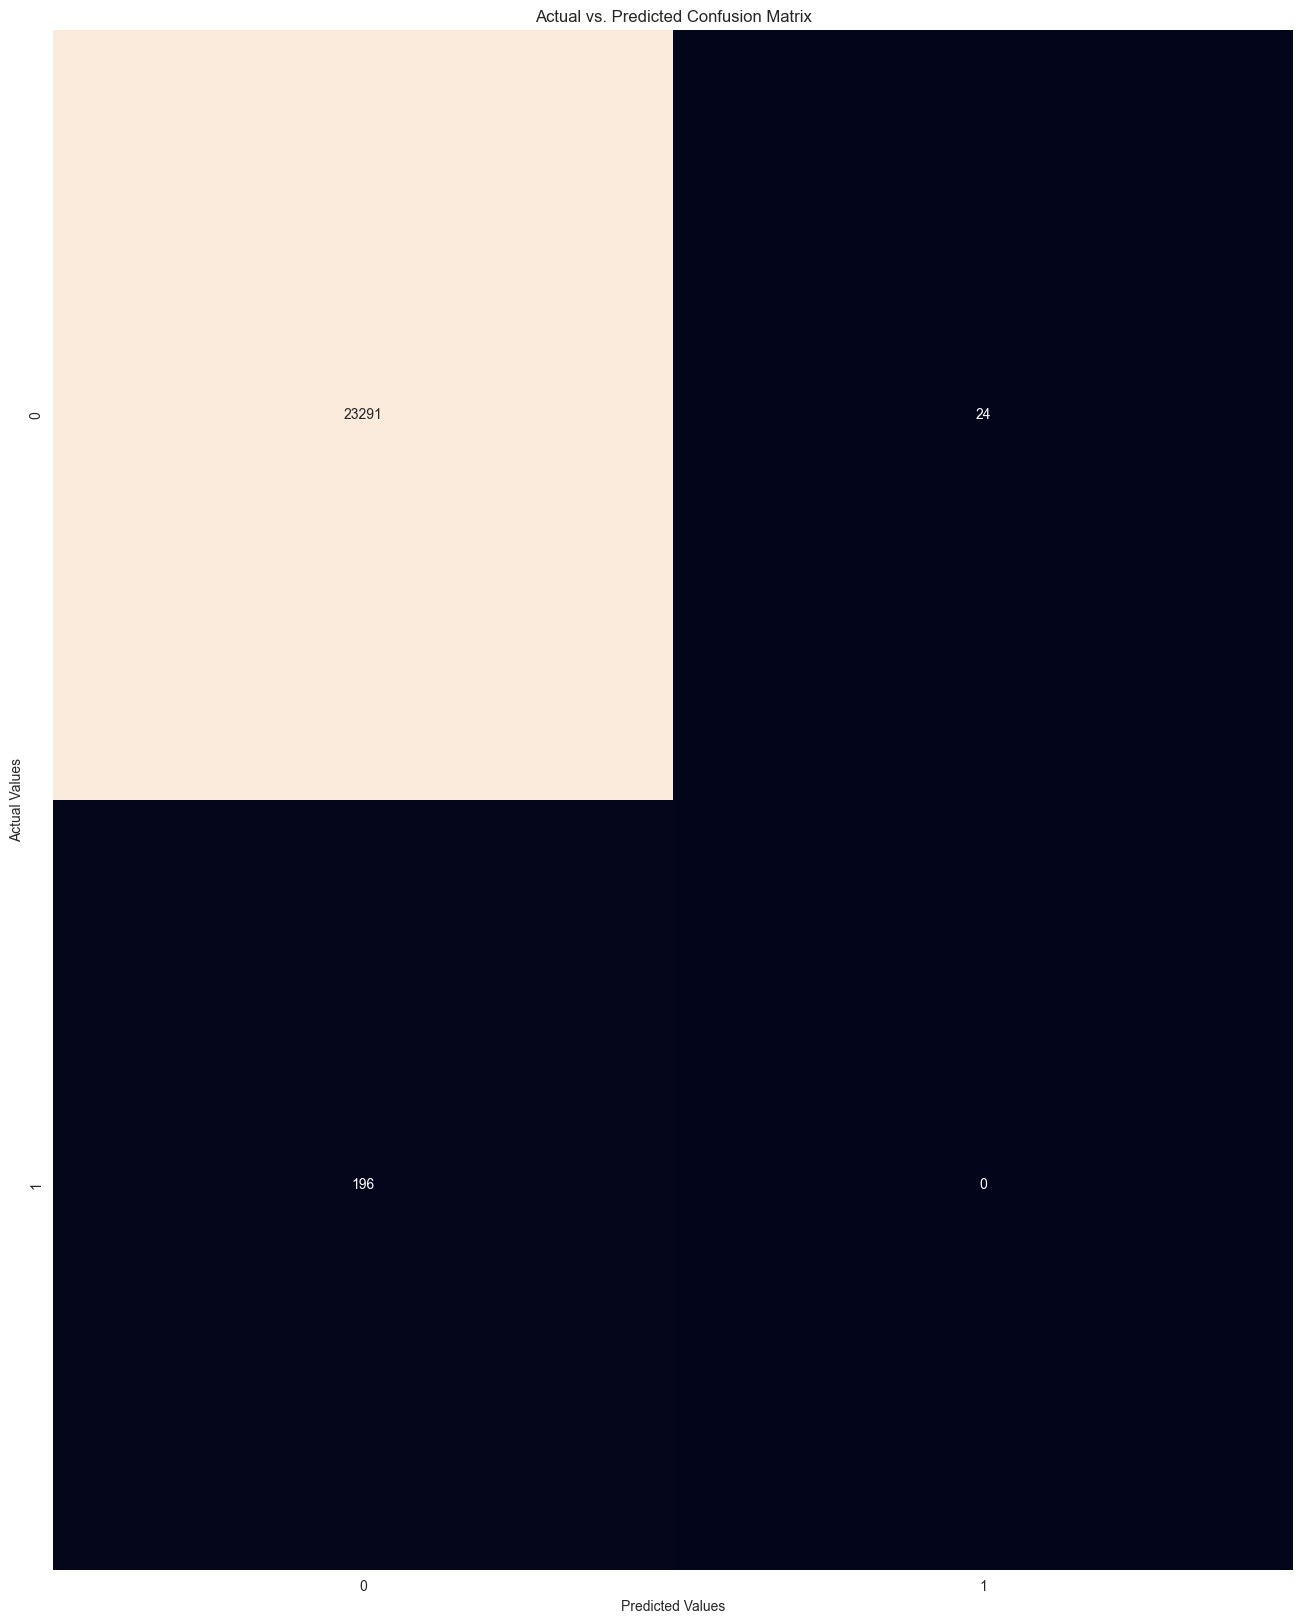

In [1721]:
    conf_mat = create_conf_mat(y_test,y_pred_LR)
    sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Actual vs. Predicted Confusion Matrix')
    plt.show()

In [1722]:
#Get predicted probabilites
target_probailities_log = LR.predict_proba(x_test)[:,1]

In [1723]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

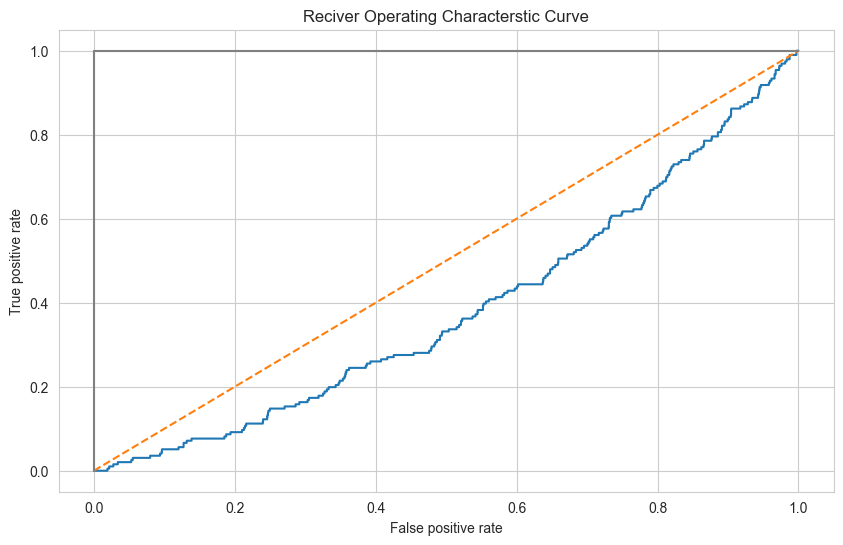

In [1724]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

# Naive Bayes

In [1725]:
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
print(roc_auc_score(y_test,y_pred_nb))
Model.append('Naive Bayes')
ROC_AUC_Accuracy_LASSO.append(roc_auc_score(y_test,y_pred_nb))

0.5774468569327795


In [1726]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.05      0.18      0.08       196

    accuracy                           0.96     23511
   macro avg       0.52      0.58      0.53     23511
weighted avg       0.99      0.96      0.97     23511



In [1727]:
results=confusion_matrix(y_test,y_pred_nb)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_nb) )
print ('Report : ')
print (classification_report(y_test,y_pred_nb) )

Confusion Matrix :
[[22644   671]
 [  160    36]]
Accuracy Score : 0.9646548424141891
Report : 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     23315
           1       0.05      0.18      0.08       196

    accuracy                           0.96     23511
   macro avg       0.52      0.58      0.53     23511
weighted avg       0.99      0.96      0.97     23511



In [1728]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_nb ):
    cm = metrics.confusion_matrix( y_test,y_pred_nb )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1729]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_nb )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[22644   671]
 [  160    36]]


In [1730]:
def create_conf_mat(y_test,y_pred_nb):
    if (len(y_test.shape) != len(y_pred_nb.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_nb.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_nb)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

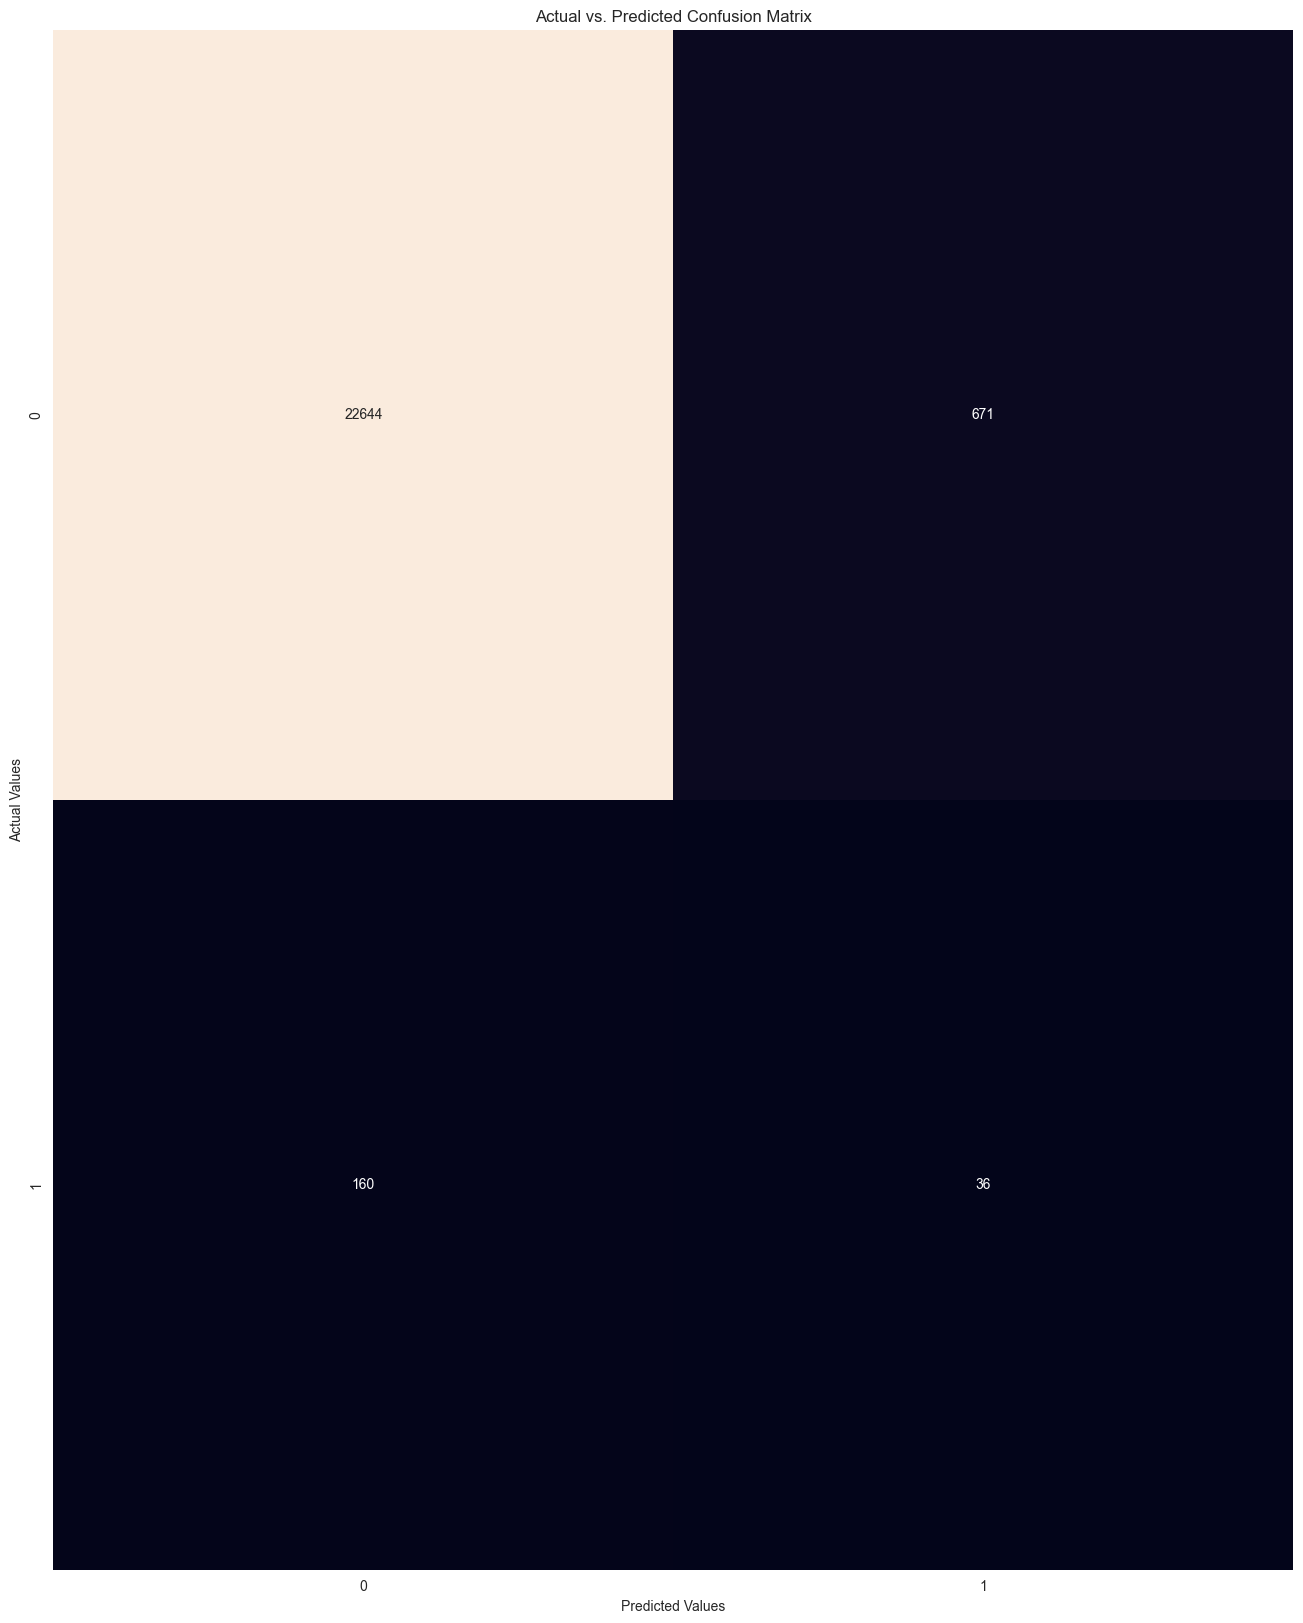

In [1731]:
conf_mat = create_conf_mat(y_test,y_pred_nb)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1732]:
#Get predicted probabilites
target_probailities_log = nb.predict_proba(x_test)[:,1]

In [1733]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

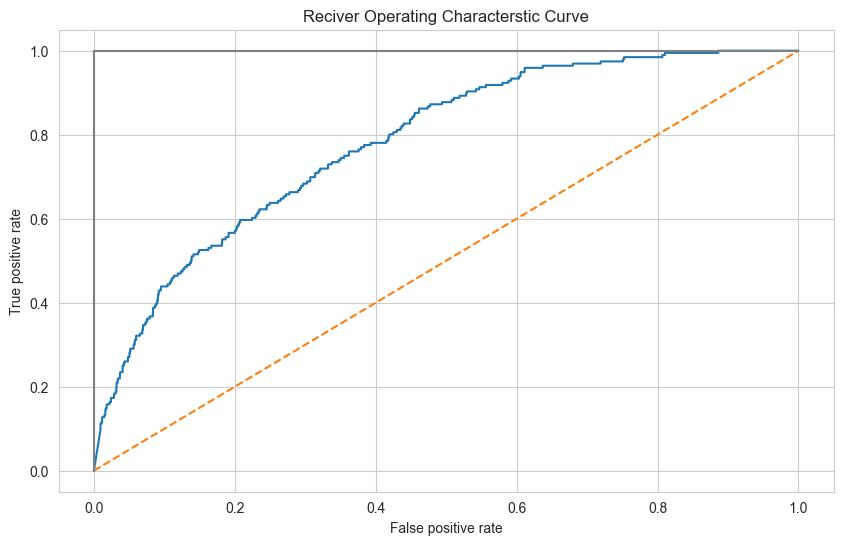

In [1734]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1735]:
Model,ROC_AUC_Accuracy_LASSO

(['Logistic Regression', 'Naive Bayes'],
 [0.49948530988633927, 0.5774468569327795])

# Decision Tree

In [1736]:
params = {
    
    'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':range(1,10),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

dt = DecisionTreeClassifier()

rs = RandomizedSearchCV(estimator=dt,n_jobs=-1,cv=3,param_distributions=params,scoring='recall')
rs.fit(x,y)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'splitter': ['best', 'random']},
                   scoring='recall')

In [1737]:
dt = DecisionTreeClassifier(**rs.best_params_)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(roc_auc_score(y_test,y_pred_dt))
Model.append('Decision Tree')
ROC_AUC_Accuracy_LASSO.append(roc_auc_score(y_test,y_pred_dt))

0.5126693203552062


In [1738]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.56      0.03      0.05       196

    accuracy                           0.99     23511
   macro avg       0.77      0.51      0.52     23511
weighted avg       0.99      0.99      0.99     23511



In [1739]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_dt):
    cm = metrics.confusion_matrix( y_test,y_pred_dt )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1740]:
results=confusion_matrix(y_test,y_pred_dt)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_dt) )
print ('Report : ')
print (classification_report(y_test,y_pred_dt) )

Confusion Matrix :
[[23311     4]
 [  191     5]]
Accuracy Score : 0.991706009952788
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       0.56      0.03      0.05       196

    accuracy                           0.99     23511
   macro avg       0.77      0.51      0.52     23511
weighted avg       0.99      0.99      0.99     23511



In [1741]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_dt )
print("confusion matrix = \n",mat_pruned)

confusion matrix = 
 [[23311     4]
 [  191     5]]


In [1742]:
def create_conf_mat(y_test,y_pred_dt):
    if (len(y_test.shape) != len(y_pred_dt.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_dt.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_dt)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

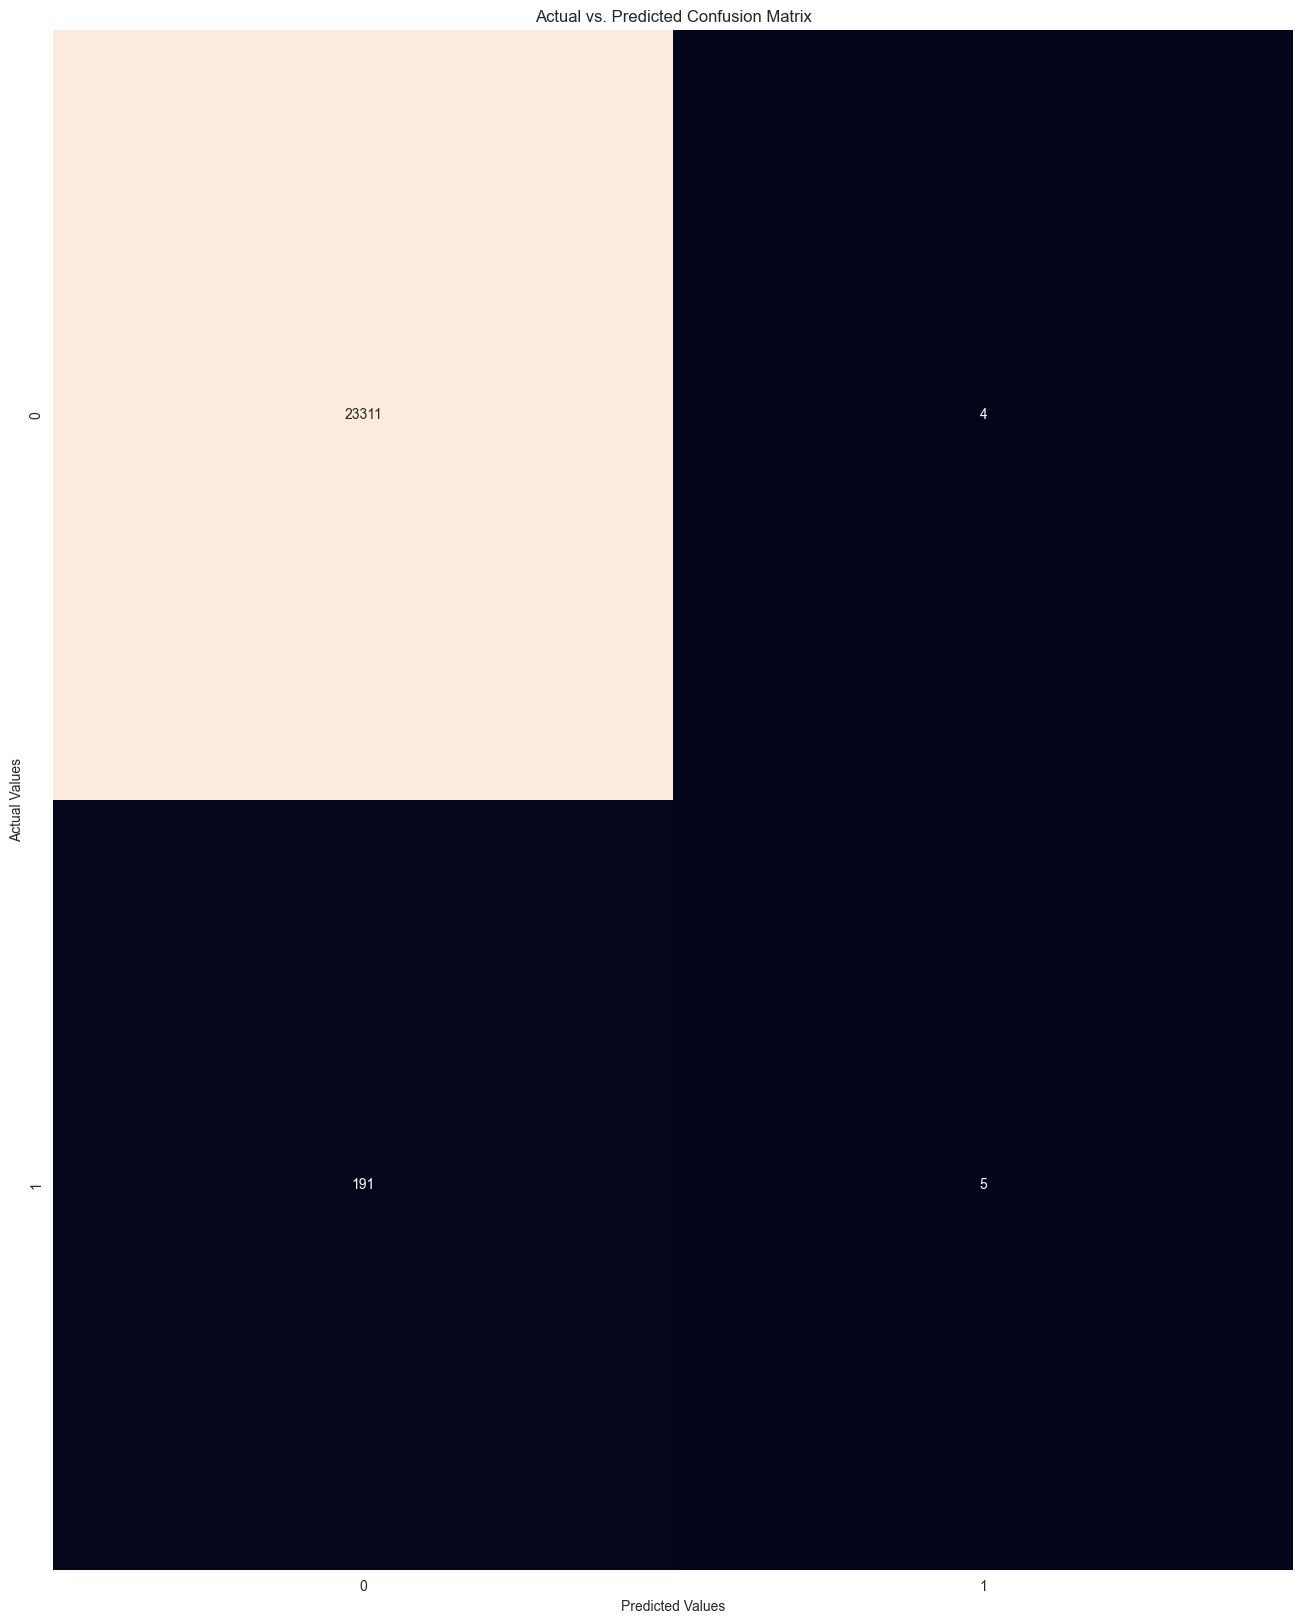

In [1743]:
conf_mat = create_conf_mat(y_test,y_pred_dt)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1744]:
#Get predicted probabilites
target_probailities_log = dt.predict_proba(x_test)[:,1]

In [1745]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)

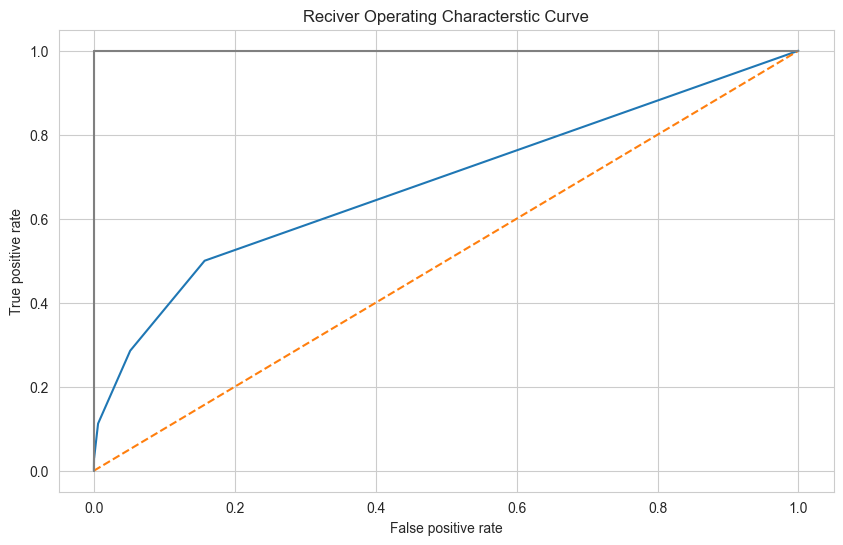

In [1746]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1747]:
Model,ROC_AUC_Accuracy_LASSO

(['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
 [0.49948530988633927, 0.5774468569327795, 0.5126693203552062])

# Random Forest

In [1748]:
params = {
    
    'n_estimators':range(10,100,10),
    'criterion':['gini','entropy'],
    'max_depth':range(2,10,1),
    'max_leaf_nodes':range(2,10,1),
    'max_features':['auto','log2']
    
}

rf = RandomForestClassifier()

rs = RandomizedSearchCV(estimator=rf,param_distributions=params,cv=5,scoring='recall',n_jobs=-1)
rs.fit(x,y)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(2, 10),
                                        'max_features': ['auto', 'log2'],
                                        'max_leaf_nodes': range(2, 10),
                                        'n_estimators': range(10, 100, 10)},
                   scoring='recall')

In [1749]:
rf = RandomForestClassifier(**rs.best_params_)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(roc_auc_score(y_test,y_pred_rf))
Model.append('Random Forest')
ROC_AUC_Accuracy_LASSO.append(roc_auc_score(y_test,y_pred_rf))

0.5051020408163265


In [1750]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       1.00      0.01      0.02       196

    accuracy                           0.99     23511
   macro avg       1.00      0.51      0.51     23511
weighted avg       0.99      0.99      0.99     23511



In [1751]:
results=confusion_matrix(y_test,y_pred_rf)
print ('Confusion Matrix :')
print(results) 
print ('Accuracy Score :',accuracy_score(y_test,y_pred_rf) )
print ('Report : ')
print (classification_report(y_test,y_pred_rf) )


Confusion Matrix :
[[23315     0]
 [  194     2]]
Accuracy Score : 0.9917485432350814
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23315
           1       1.00      0.01      0.02       196

    accuracy                           0.99     23511
   macro avg       1.00      0.51      0.51     23511
weighted avg       0.99      0.99      0.99     23511



In [1752]:
#Function to visulise confusion matrix
def draw_cm( y_test,y_pred_rf ):
    cm = metrics.confusion_matrix( y_test,y_pred_rf )
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = ["0", "1"] , yticklabels = ["0", "1"] , cmap="Greens")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [1753]:
#Confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
mat_pruned = confusion_matrix(y_test,y_pred_rf )
print("confusion matrix = \n",mat_pruned)


confusion matrix = 
 [[23315     0]
 [  194     2]]


In [1754]:
def create_conf_mat(y_test,y_pred_rf):
    if (len(y_test.shape) != len(y_pred_rf.shape) == 1):
        return print('Arrays entered are not 1-D.\nPlease enter the correctly sized sets.')
    elif (y_test.shape != y_pred_rf.shape):
        return print('Number of values inside the Arrays are not equal to each other.\nPlease make sure the array has the same number of instances.')
    else:
        # Set Metrics
        test_crosstb_comp = pd.crosstab(index = y_test,
                                       columns = y_pred_rf)
        # Changed for Future deprecation of as_matrix
        test_crosstb = test_crosstb_comp.values
        return test_crosstb

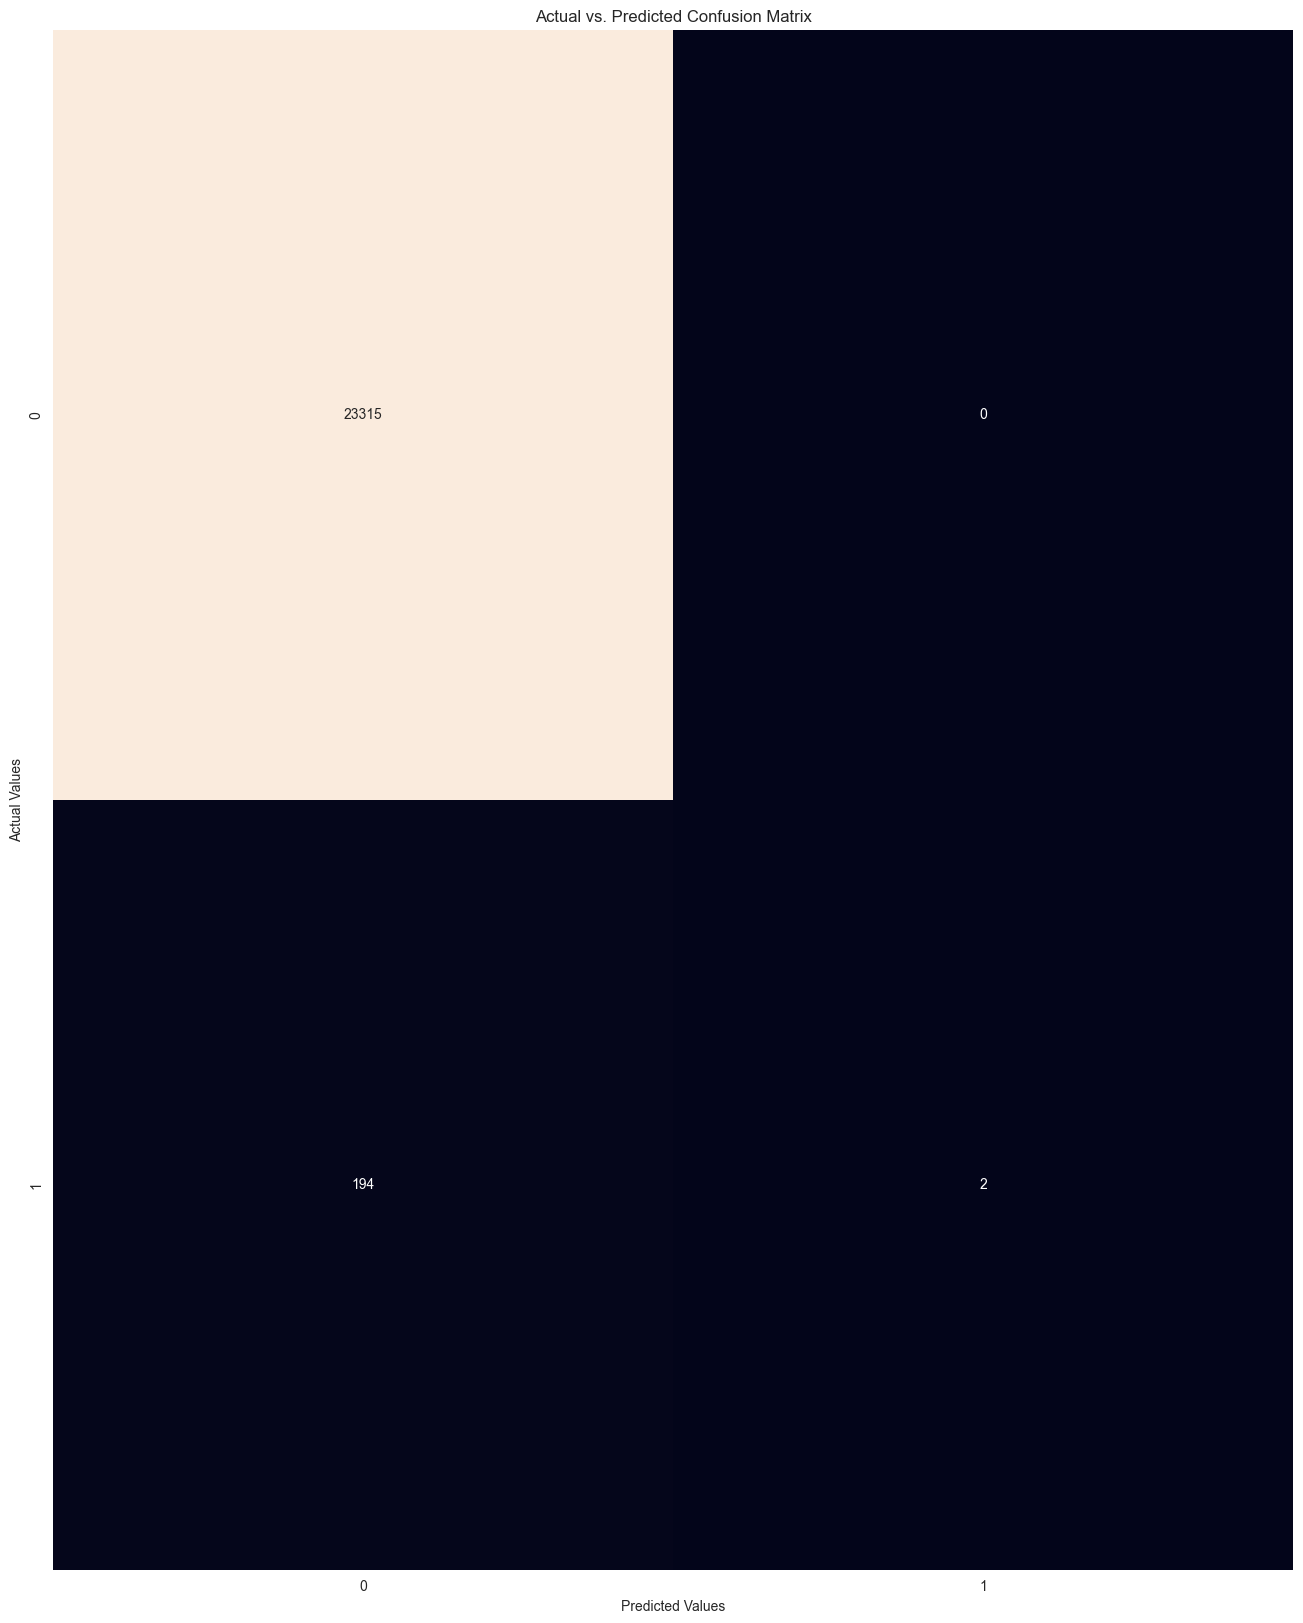

In [1755]:
conf_mat = create_conf_mat(y_test,y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Confusion Matrix')
plt.show()

In [1756]:
#Get predicted probabilites
target_probailities_log = rf.predict_proba(x_test)[:,1]

In [1757]:
#Create true and false positive rates
log_false_positive_rate,log_true_positive_rate,log_threshold = roc_curve(y_test,target_probailities_log)


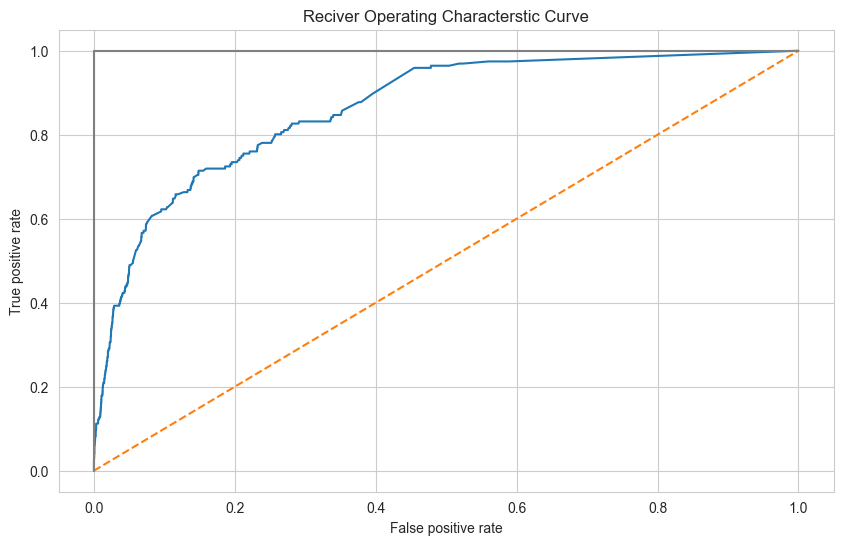

In [1758]:
#Plot ROC Curve
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.title('Reciver Operating Characterstic Curve')
plt.plot(log_false_positive_rate,log_true_positive_rate)
plt.plot([0,1],ls='--')
plt.plot([0,0],[1,0],c='.5')
plt.plot([1,1],c='.5')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

In [1759]:
Model,ROC_AUC_Accuracy_LASSO

(['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
 [0.49948530988633927,
  0.5774468569327795,
  0.5126693203552062,
  0.5051020408163265])

In [1760]:
final_result = pd.DataFrame({'Model':Model,'Accuracy':ROC_AUC_Accuracy_LASSO})
final_result

,Model,Accuracy
0,Logistic Regression,0.499485
1,Naive Bayes,0.577447
2,Decision Tree,0.512669
3,Random Forest,0.505102


In [1761]:
final_result = pd.DataFrame({'Model - RFE Data':Model,'Accuracy':ROC_AUC_Accuracy_LASSO})
final_result

,Model - RFE Data,Accuracy
0,Logistic Regression,0.499485
1,Naive Bayes,0.577447
2,Decision Tree,0.512669
3,Random Forest,0.505102


In [1762]:
final_result = pd.DataFrame({'Model - Data':Model, 'Accuracy no feature selection:': ROC_AUC_Accuracy,'Accuracy RFE':ROC_AUC_Accuracy_RFE, 'Accuracy VIF':ROC_AUC_Accuracy_VIF, 'Accuracy LASSO':ROC_AUC_Accuracy_LASSO })
final_result

,Model - Data,Accuracy no feature selection:,Accuracy RFE,Accuracy VIF,Accuracy LASSO
0,Logistic Regression,0.501543,0.502422,0.500000,0.499485
1,Naive Bayes,0.585443,0.586815,0.588144,0.577447
2,Decision Tree,0.505016,0.512562,0.499871,0.512669
3,Random Forest,0.502551,0.500000,0.500000,0.505102
